# Forecasting Retail Consumer Purchase Trends in Kenya Using Machine Learning Algorithms

## Table of Contents
1. Data Overview:
    * Load the dataset.
    * Explore the structure, types, and summary statistics.

2. Feature Engineering:
    * Handle missing values.
    * Encode categorical variables.
    * Normalize/scale numerical variables.
    * Exploratory Data Analysis (EDA):
    * Visualize relationships between variables.
    * Analyze distributions and correlations.

3. Statistical Analysis:
    * Perform hypothesis testing and statistical significance checks.
    * Investigate variable relationships.

4. Feature Importance:
    * Use techniques like correlation analysis, mutual information, or tree-based models to rank feature importance.
5. Model Development:
    * Split data into training and testing sets.
    * Train and evaluate models (e.g., linear regression, random forest).

6. Model Interpretation:
    * Explain the contributions of each independent variable.


## Getting Started

# Business Understanding

- Kenya's retail sector is booming and vital to the economy, with many in the informal sector. This study forecasts the factors that influence consumer buying trends using Kasi Insight data from April 2020 to March 2024, analyzing demographic factors such as 'Location', 'Gender', 'Age-group'and 'Income-Level' and purchasing patterns. Employing RF, XGB and KNN.
- The dataset includes detailed information on consumer demographics and purchasing behavior across various locations in Kenya.Each consumer was asked to rate their purchasing behavior compared to the previous month across these categories, using the options "More," "Same," "Less," or "Don't Know or Don't Buy." The variables collected are categorized into demographic information and purchasing categories.

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Load Data
[https://raw.githubusercontent.com/NcikoLinda/data/refs/heads/main/Final_data.csv](https://raw.githubusercontent.com/NcikoLinda/data/refs/heads/main/Final_data.csv)

In [ ]:
# URL of the raw CSV file
url = "https://raw.githubusercontent.com/LindaNciko/Dataset/main/Retail%20in%20Kenya%20-%20Consumer%20Purchase%20Trends.csv"

# Read the CSV file into the DataFrame data
data = pd.read_csv(url)

# Display the first few rows to understand the structure of the data
data.head()


,Period,Location,Gender,Age-group,Occupation,Income Level,"Personal Hygiene (eg Soap, toothpaste)",Cleaning products,Long lasting (dry) groceries,"Fresh groceries (Fruits, vegetables)",Medicines/Natural remedies,Alcohol beverages,Skin care (eg. Body lotion),Hair care (eg. Shampoo),"Entertainment (eg. Restaurants, movies)","Electronics (eg Phone, Computers)","Beauty (eg Makeup, cosmetics, haircuts)",Clothing,Airtime/Data bundles
0,2024-12-20,MS1,Male,Gen Z,Salaried employee,High Income,Less,Same,More,Don't know/Don't buy,Same,Same,More,More,More,Same,Same,Same,Don't know/Don't buy
1,2024-12-20,MS1,Female,Gen X,Salaried employee,Middle Income,Less,Same,More,Don't know/Don't buy,Same,Same,More,Don't know/Don't buy,More,Same,Less,Same,More
2,2024-12-20,MS1,Male,Millennials,Salaried employee,Middle Income,Less,Same,More,Don't know/Don't buy,Same,Same,More,More,More,Same,More,Same,More
3,2024-12-20,MS1,Female,Gen Z,Salaried employee,Middle Income,Less,Same,More,More,Don't know/Don't buy,Don't know/Don't buy,More,Don't know/Don't buy,Don't know/Don't buy,More,Don't know/Don't buy,More,More
4,2024-12-20,MS1,Female,Millennials,Salaried employee,Middle Income,Less,Same,More,Don't know/Don't buy,Same,Same,More,Don't know/Don't buy,More,Same,Less,Same,More


# Data Preprocessing

In [ ]:
# Get size of dataset
data.shape

(10530, 19)

In [ ]:
# Basic info about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10530 entries, 0 to 10529
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Period                                   10530 non-null  object
 1   Location                                 10530 non-null  object
 2   Gender                                   10530 non-null  object
 3   Age-group                                10530 non-null  object
 4   Occupation                               10530 non-null  object
 5   Income Level                             8135 non-null   object
 6   Personal Hygiene (eg Soap, toothpaste)   10530 non-null  object
 7   Cleaning products                        10530 non-null  object
 8   Long lasting (dry) groceries             10530 non-null  object
 9   Fresh groceries (Fruits, vegetables)     10530 non-null  object
 10  Medicines/Natural remedies               10530 non-null  o

In [ ]:
# Summary statistics
data.describe(include='all')

,Period,Location,Gender,Age-group,Occupation,Income Level,"Personal Hygiene (eg Soap, toothpaste)",Cleaning products,Long lasting (dry) groceries,"Fresh groceries (Fruits, vegetables)",Medicines/Natural remedies,Alcohol beverages,Skin care (eg. Body lotion),Hair care (eg. Shampoo),"Entertainment (eg. Restaurants, movies)","Electronics (eg Phone, Computers)","Beauty (eg Makeup, cosmetics, haircuts)",Clothing,Airtime/Data bundles
count,10530,10530,10530,10530,10530,8135,10530,10530,10530,10530,10530,10530,10530,10530,10530,10530,10530,10530,10530
unique,21,76,2,4,10,3,4,4,4,4,4,4,4,4,4,4,4,4,4
top,2020-09-20,N1,Male,Millennials,Salaried employee,Middle Income,Same,Same,Same,Same,Same,Same,Same,Same,Same,Same,Same,Same,Same
freq,552,348,5468,6040,5286,4210,6035,5806,5393,5810,4547,3356,5584,4756,3872,3913,4709,4939,5413


### Handling missing value

In [ ]:
# Checking for missing values
missing_values = data.isnull().sum()

# Display missing values
missing_values

,0
Period,0
Location,0
Gender,0
Age-group,0
Occupation,0
Income Level,2395
"Personal Hygiene (eg Soap, toothpaste)",0
Cleaning products,0
Long lasting (dry) groceries,0
"Fresh groceries (Fruits, vegetables)",0


Significant missing data is present in the "Income-Level" column (around 25%). They are  replaced by the mode.

In [ ]:
# Replace missing values with the mode for each column
data = data.apply(lambda x: x.fillna(x.mode()[0]) if x.isnull().any() else x)

# Check for missing values again to confirm replacement
missing_values_after = data.isnull().sum()

print("\nMissing values after replacement:")
print(missing_values_after)



Missing values after replacement:
Period                                     0
Location                                   0
Gender                                     0
Age-group                                  0
Occupation                                 0
Income Level                               0
Personal Hygiene (eg Soap, toothpaste)     0
Cleaning products                          0
Long lasting (dry) groceries               0
Fresh groceries (Fruits, vegetables)       0
Medicines/Natural remedies                 0
Alcohol beverages                          0
Skin care (eg. Body lotion)                0
Hair care (eg. Shampoo)                    0
Entertainment (eg. Restaurants, movies)    0
Electronics (eg Phone, Computers)          0
Beauty (eg Makeup, cosmetics, haircuts)    0
Clothing                                   0
Airtime/Data bundles                       0
dtype: int64


## Remove Duplicates

In [ ]:
# Check for duplicate values
data.duplicated().sum()

np.int64(346)

In [ ]:
#remove duplicate
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(10184, 19)

## Standardizing Categorical Responses

Replace "Don't Know or Don't Buy" with "Not sure"

In [ ]:
# Print the column names
data.columns

Index(['Period', 'Location', 'Gender', 'Age-group', 'Occupation',
       'Income Level', 'Personal Hygiene (eg Soap, toothpaste)',
       'Cleaning products', 'Long lasting (dry) groceries',
       'Fresh groceries (Fruits, vegetables)', 'Medicines/Natural remedies',
       'Alcohol beverages', 'Skin care (eg. Body lotion)',
       'Hair care (eg. Shampoo)', 'Entertainment (eg. Restaurants, movies)',
       'Electronics (eg Phone, Computers)',
       'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
       'Airtime/Data bundles'],
      dtype='object')

In [ ]:
# Replace "Don't know/Don't buy" with "Not sure"
columns_to_replace = ['Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
                      'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
                      'Medicines/Natural remedies', 'Alcohol beverages',
                      'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
                      'Entertainment (eg. Restaurants, movies)',
                      'Electronics (eg Phone, Computers)',
                      'Beauty (eg Makeup, cosmetics, haircuts)',
                      'Clothing', 'Airtime/Data bundles']

data[columns_to_replace] = data[columns_to_replace].replace("Don't know/Don't buy", "Not sure")

# Verifying the change
for col in columns_to_replace:
    print(f"Unique values in column '{col}':")
    print(data[col].unique())
    print("\n")


Unique values in column 'Personal Hygiene (eg Soap, toothpaste)':
['Less' 'Not sure' 'More' 'Same']


Unique values in column 'Cleaning products':
['Same' 'More' 'Less' 'Not sure']


Unique values in column 'Long lasting (dry) groceries':
['More' 'Same' 'Not sure' 'Less']


Unique values in column 'Fresh groceries (Fruits, vegetables)':
['Not sure' 'More' 'Less' 'Same']


Unique values in column 'Medicines/Natural remedies':
['Same' 'Not sure' 'More' 'Less']


Unique values in column 'Alcohol beverages':
['Same' 'Not sure' 'More' 'Less']


Unique values in column 'Skin care (eg. Body lotion)':
['More' 'Same' 'Not sure' 'Less']


Unique values in column 'Hair care (eg. Shampoo)':
['More' 'Not sure' 'Same' 'Less']


Unique values in column 'Entertainment (eg. Restaurants, movies)':
['More' 'Not sure' 'Less' 'Same']


Unique values in column 'Electronics (eg Phone, Computers)':
['Same' 'More' 'Not sure' 'Less']


Unique values in column 'Beauty (eg Makeup, cosmetics, haircuts)':
['Same' '

## Outlier Detection and Treatment

In [ ]:
# Get the unique values and value counts for each column
pd.set_option('display.max_rows', None)
for column in data.columns:
    print(f"Unique values in column '{column}':")
    print(data[column].unique())
    print()

    print(f"Distribution of values in column '{column}':")
    print(data[column].value_counts())
    print('-' * 50)  # Separator line for clarity


Unique values in column 'Period':
['2024-12-20' '2024-07-20' '2024-03-20' '2023-11-20' '2023-07-20'
 '2023-03-20' '2022-11-20' '2022-06-20' '2022-02-20' '2021-10-20'
 '2021-07-20' '2021-04-20' '2020-12-20' '2020-11-20' '2020-10-20'
 '2020-09-20' '2020-08-20' '2020-07-20' '2020-06-20' '2020-05-20'
 '2020-04-20']

Distribution of values in column 'Period':
Period
2020-09-20    531
2021-07-20    529
2021-10-20    507
2020-12-20    503
2023-07-20    500
2020-10-20    496
2023-11-20    494
2020-05-20    493
2022-02-20    488
2021-04-20    488
2022-11-20    488
2020-08-20    483
2023-03-20    483
2020-11-20    482
2024-07-20    476
2024-12-20    474
2020-07-20    472
2022-06-20    468
2024-03-20    462
2020-06-20    440
2020-04-20    427
Name: count, dtype: int64
--------------------------------------------------
Unique values in column 'Location':
['MS1' 'N1' 'N10' 'N11' 'N12' 'N13' 'N14' 'N16' 'N18' 'N2' 'N20' 'N21'
 'N22' 'N25' 'N27' 'N28' 'N30' 'N31' 'N34' 'N35' 'N36' 'N4' 'N41' 'N42'
 '

Due to its high cardinality and the presence of many infrequent values, the 'Location' column was identified as a key variable for outlier treatment by grouping rare categories into 'Other'

In [ ]:
# Removing leading and trailing spaces from column names and values
data.columns = data.columns.str.strip()
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.strip()


In [ ]:
# Frequency threshold
threshold = 20

# Identifying rare categories across all columns
rare_categories = {}

for col in data.select_dtypes(include='object').columns:
    value_counts = data[col].value_counts()
    rare_values = value_counts[value_counts < threshold].index.tolist()
    if rare_values:
        rare_categories[col] = rare_values

print("Rare categories identified:")
print(rare_categories)


Rare categories identified:
{'Location': ['N39', 'D42', 'D44', 'D15', 'D43', 'L32', 'D40', 'T11', 'D41', 'AB7', 'AC30', 'D7', 'D39', 'Z9', 'AC28', 'L47', 'D3', 'D21', 'AB5', 'D23', 'D22', 'T23', 'S78', 'N 20', 'AC20']}


In [ ]:
# Grouping rare locations into "Other"
data['Location'] = data['Location'].replace(rare_categories['Location'], 'Other')

print("Rare locations have been grouped as 'Other'")


Rare locations have been grouped as 'Other'


In [ ]:
# Check the distribution of locations after grouping
print(data['Location'].value_counts())


Location
N48      323
N41      322
N2       315
N25      309
N21      305
N14      301
N50      285
N6       281
N9       280
N17      279
N11      273
N1       273
N8       270
N20      261
N43      256
N27      255
N12      253
N16      253
N13      248
N47      242
N28      241
N5       241
N30      234
N4       230
NK1      229
N36      228
N10      214
N35      211
N22      208
N42      198
N34      178
N31      176
N18      173
MS1      158
N24      145
N37      134
N45      129
N46      127
N38      115
N40      115
N26      112
N7       100
N23       99
Other     95
N33       81
N19       81
N15       81
N3        81
N29       78
M1        47
D16       32
T18       29
Name: count, dtype: int64


## Feature Engineering: Extracting Temporal Information

In [ ]:
# Extract Year and Month from Period
data['Year'] = pd.to_datetime(data['Period']).dt.year
data['Month'] = pd.to_datetime(data['Period']).dt.month

# Reorganize columns to place 'Year' and 'Month' immediately after 'Period'
columns_order = ['Period', 'Year', 'Month'] + [col for col in data.columns if col not in ['Period', 'Year', 'Month']]
data = data[columns_order]
data.head(5)

,Period,Year,Month,Location,Gender,Age-group,Occupation,Income Level,"Personal Hygiene (eg Soap, toothpaste)",Cleaning products,...,"Fresh groceries (Fruits, vegetables)",Medicines/Natural remedies,Alcohol beverages,Skin care (eg. Body lotion),Hair care (eg. Shampoo),"Entertainment (eg. Restaurants, movies)","Electronics (eg Phone, Computers)","Beauty (eg Makeup, cosmetics, haircuts)",Clothing,Airtime/Data bundles
0,2024-12-20,2024,12,MS1,Male,Gen Z,Salaried employee,High Income,Less,Same,...,Not sure,Same,Same,More,More,More,Same,Same,Same,Not sure
1,2024-12-20,2024,12,MS1,Female,Gen X,Salaried employee,Middle Income,Less,Same,...,Not sure,Same,Same,More,Not sure,More,Same,Less,Same,More
2,2024-12-20,2024,12,MS1,Male,Millennials,Salaried employee,Middle Income,Less,Same,...,Not sure,Same,Same,More,More,More,Same,More,Same,More
3,2024-12-20,2024,12,MS1,Female,Gen Z,Salaried employee,Middle Income,Less,Same,...,More,Not sure,Not sure,More,Not sure,Not sure,More,Not sure,More,More
4,2024-12-20,2024,12,MS1,Female,Millennials,Salaried employee,Middle Income,Less,Same,...,Not sure,Same,Same,More,Not sure,More,Same,Less,Same,More


# Exploratory Data Analysis (EDA)

Yearly Distribution for Each Product Category

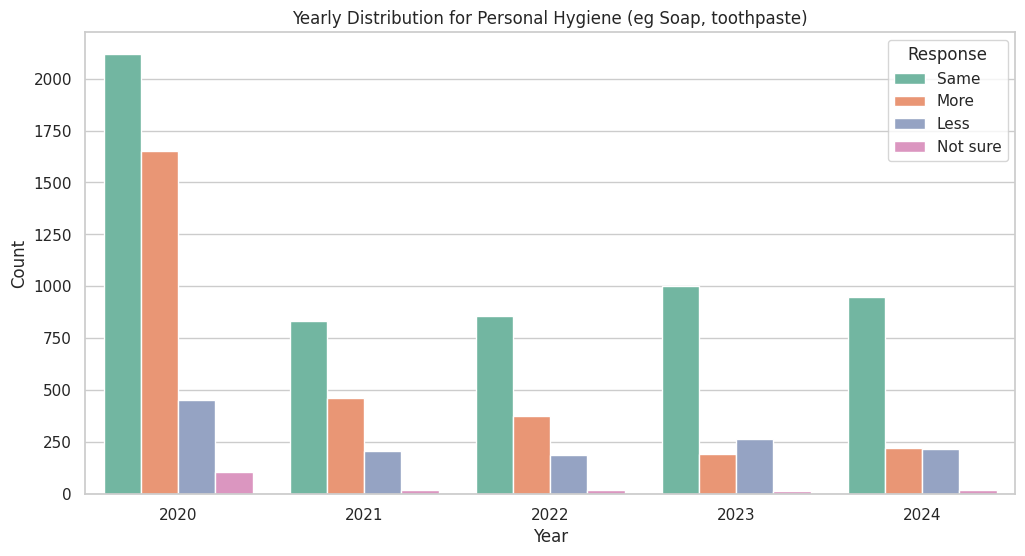

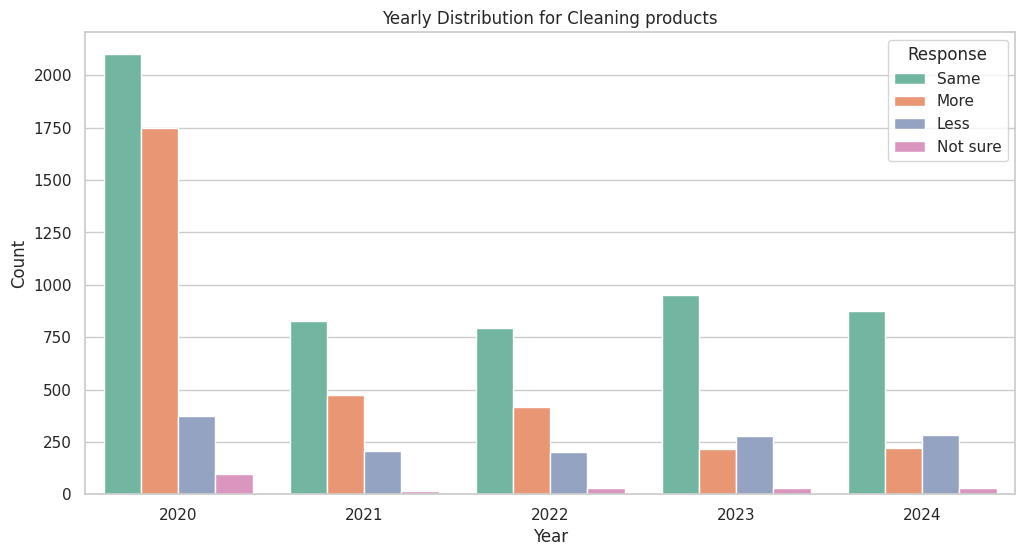

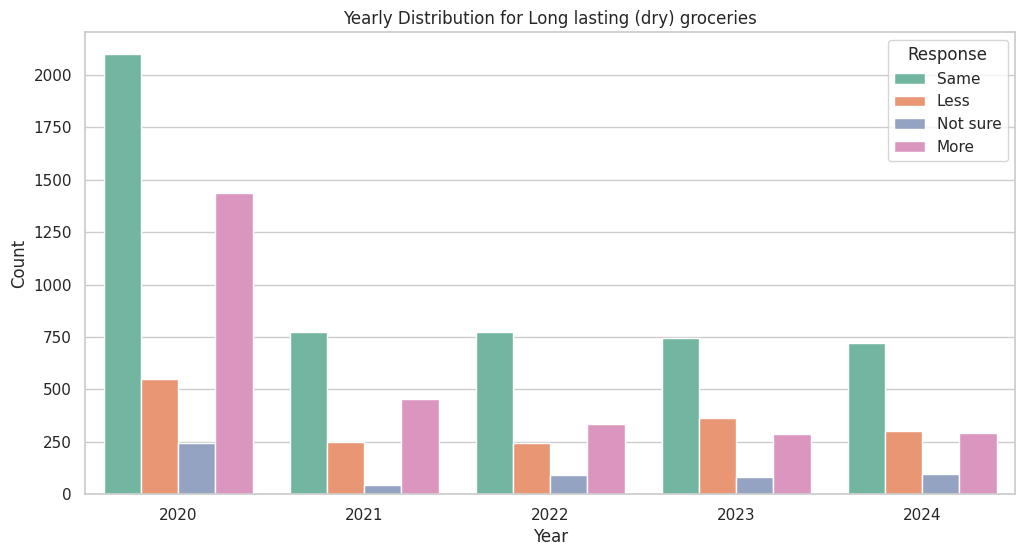

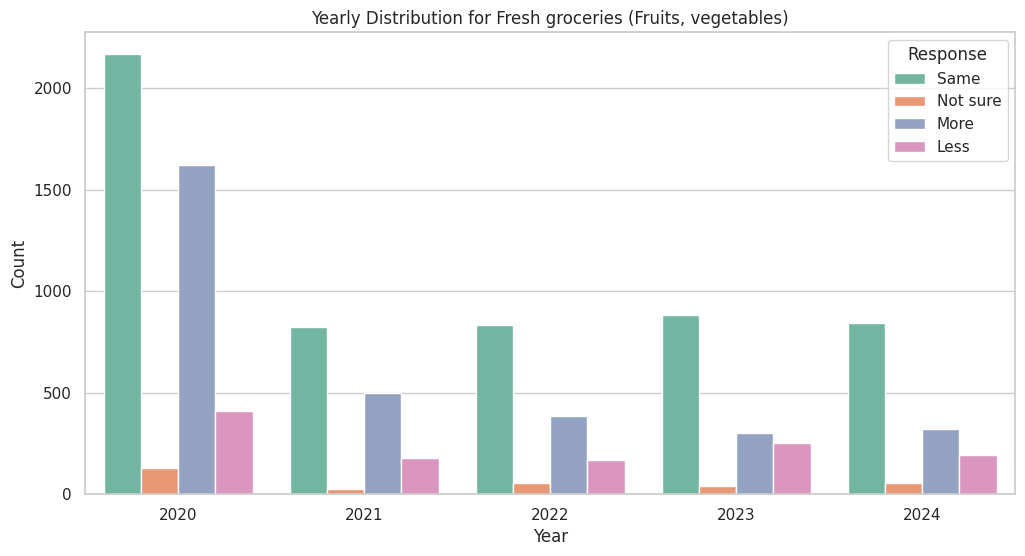

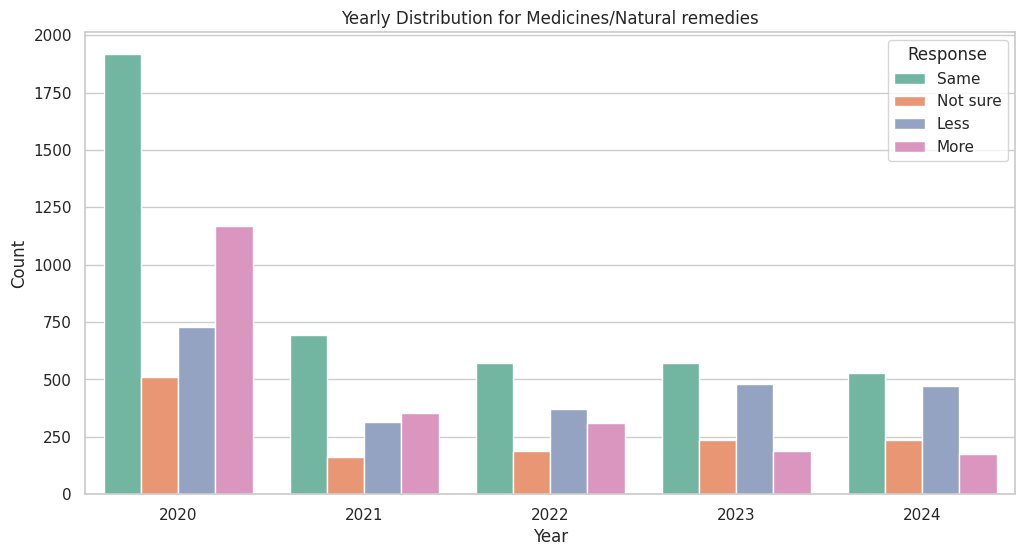

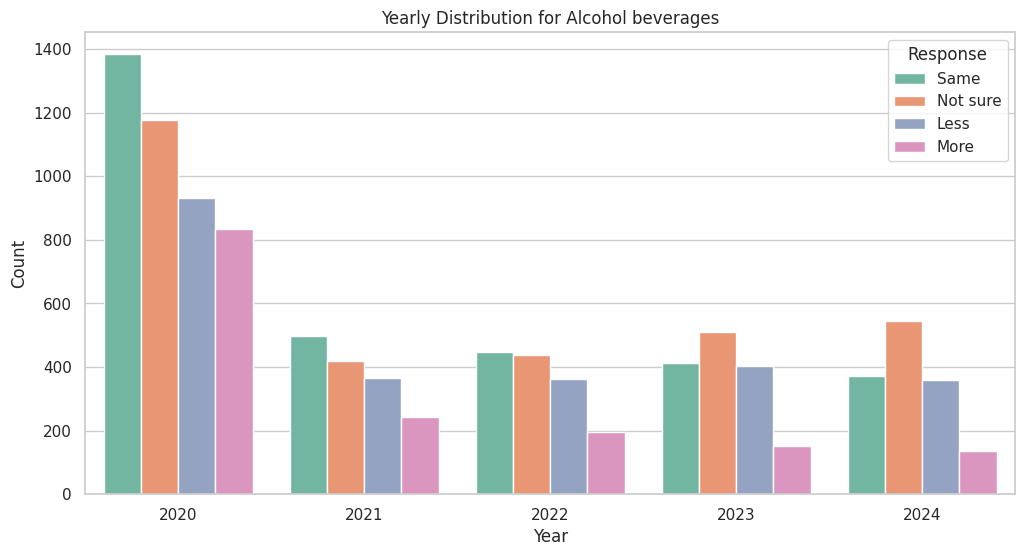

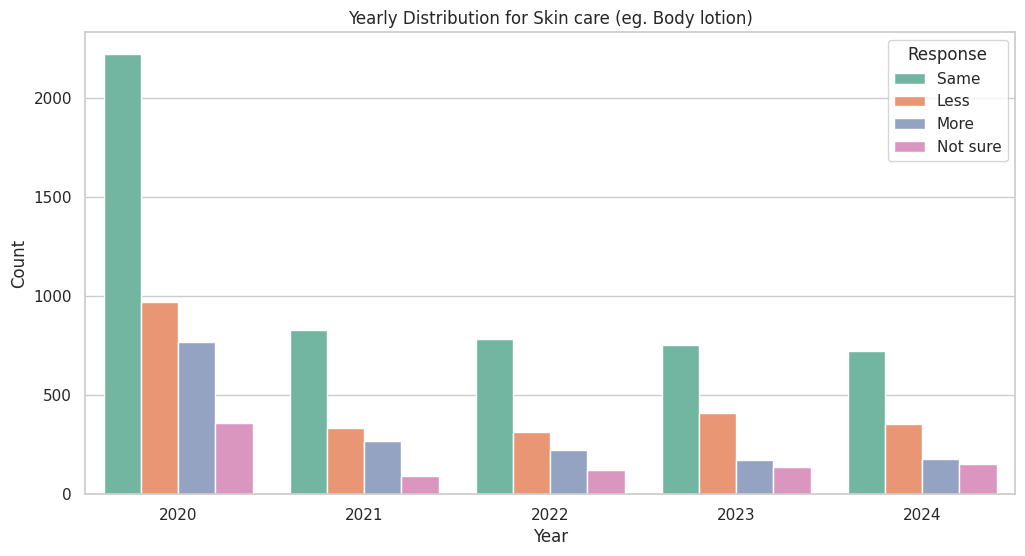

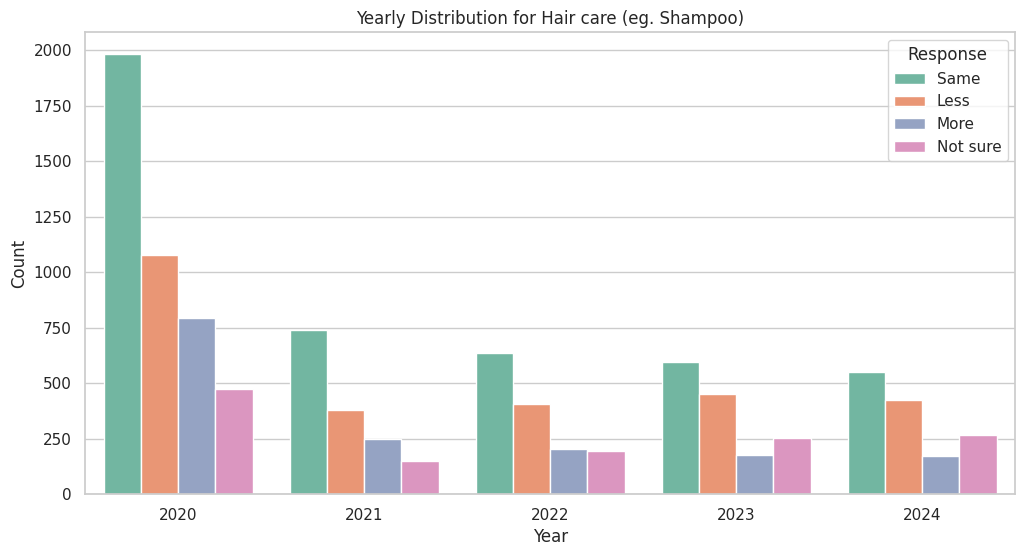

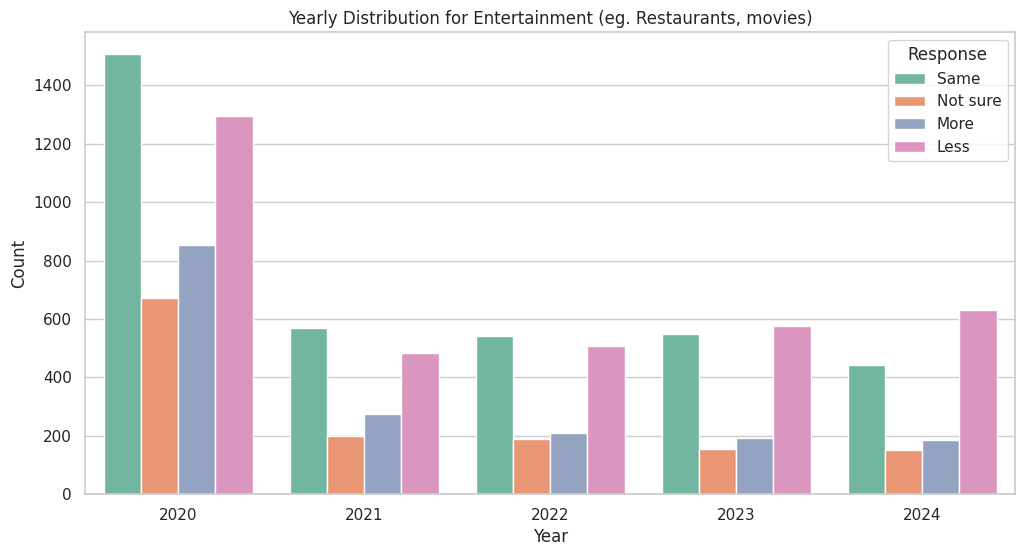

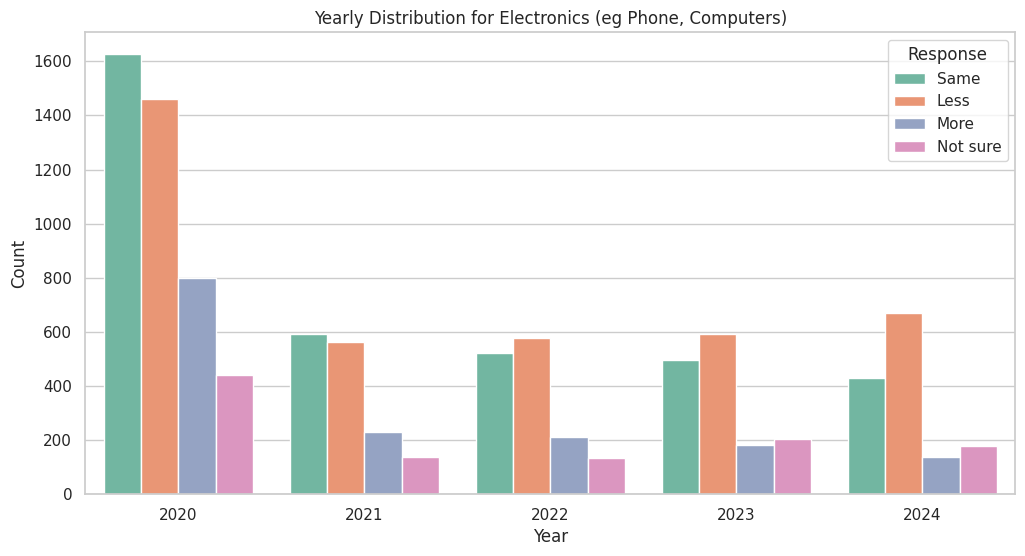

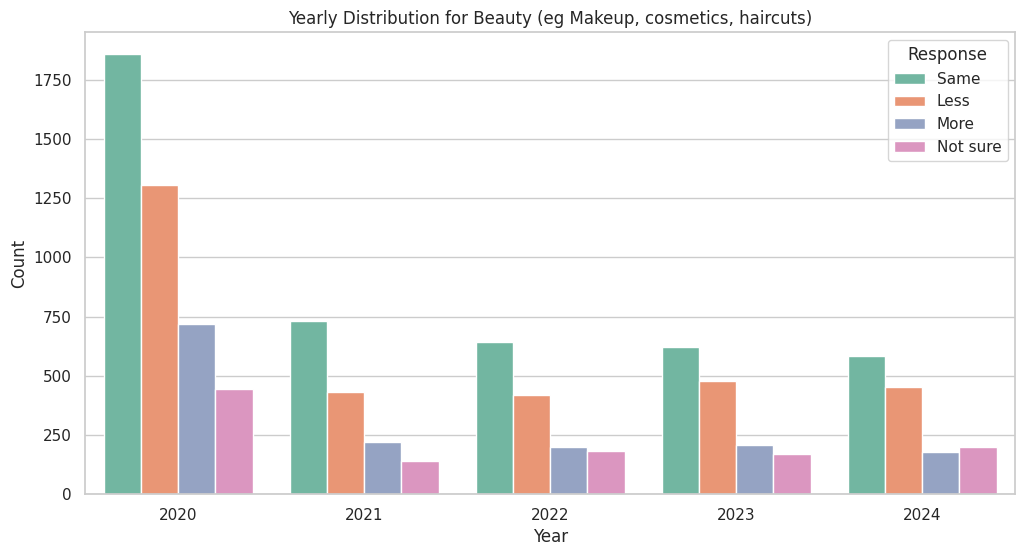

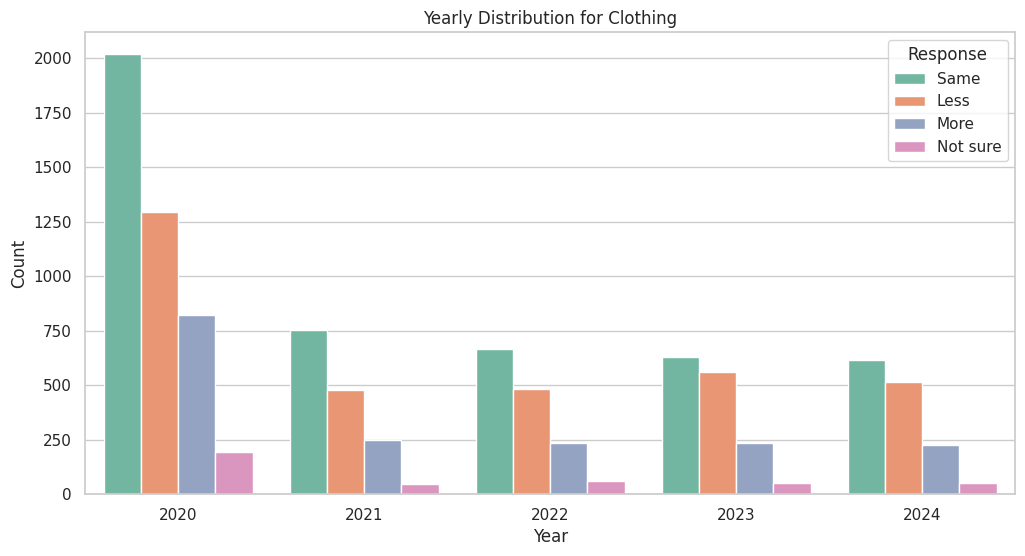

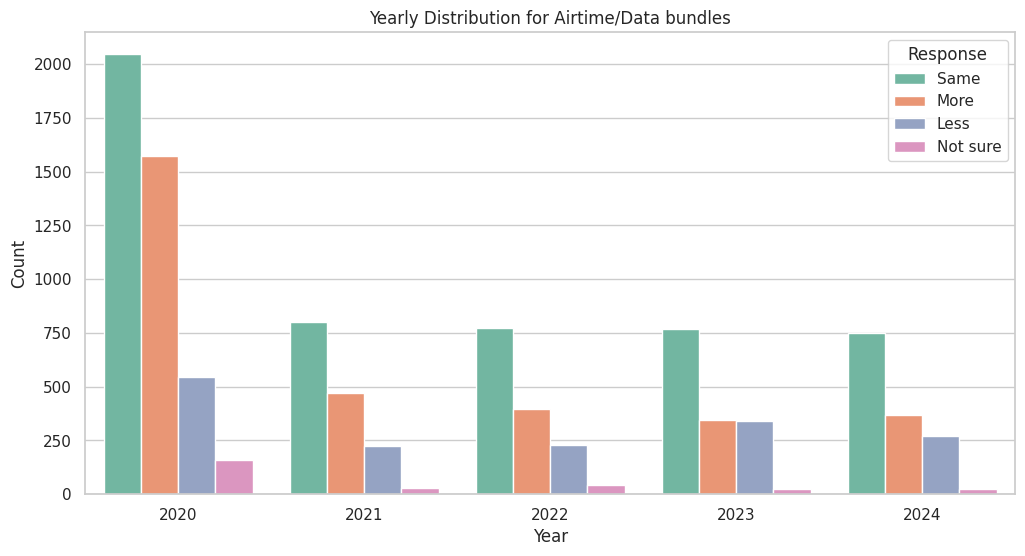

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

# Define product categories for analysis
product_categories = [
    'Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
    'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
    'Medicines/Natural remedies', 'Alcohol beverages',
    'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
    'Entertainment (eg. Restaurants, movies)', 'Electronics (eg Phone, Computers)',
    'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
    'Airtime/Data bundles'
]

# Plotting Monthly Trends for Each Product Category
for category in product_categories:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, x='Year', hue=category, palette='Set2')
    plt.title(f'Yearly Distribution for {category}')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.legend(title='Response')
    plt.show()


Demographic Comparison for each Product Category

Visualize how demographic factors influence purchasing behavior for each product category.

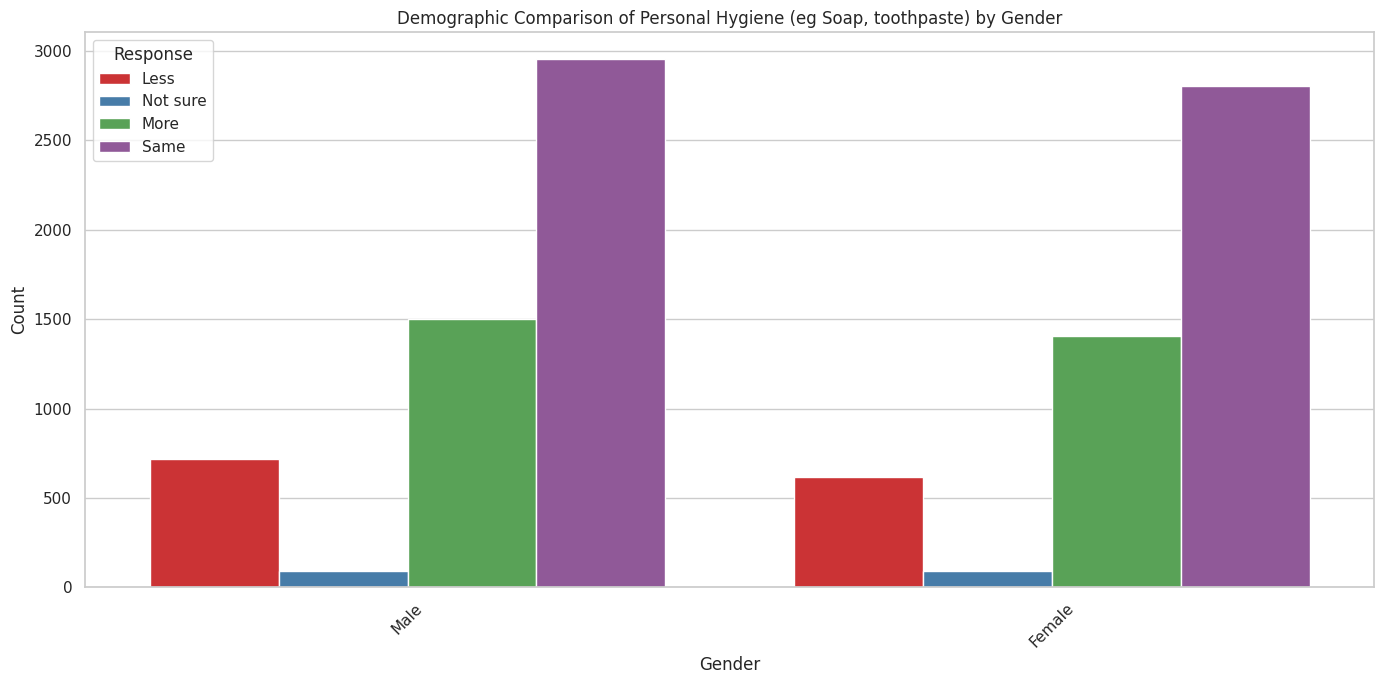

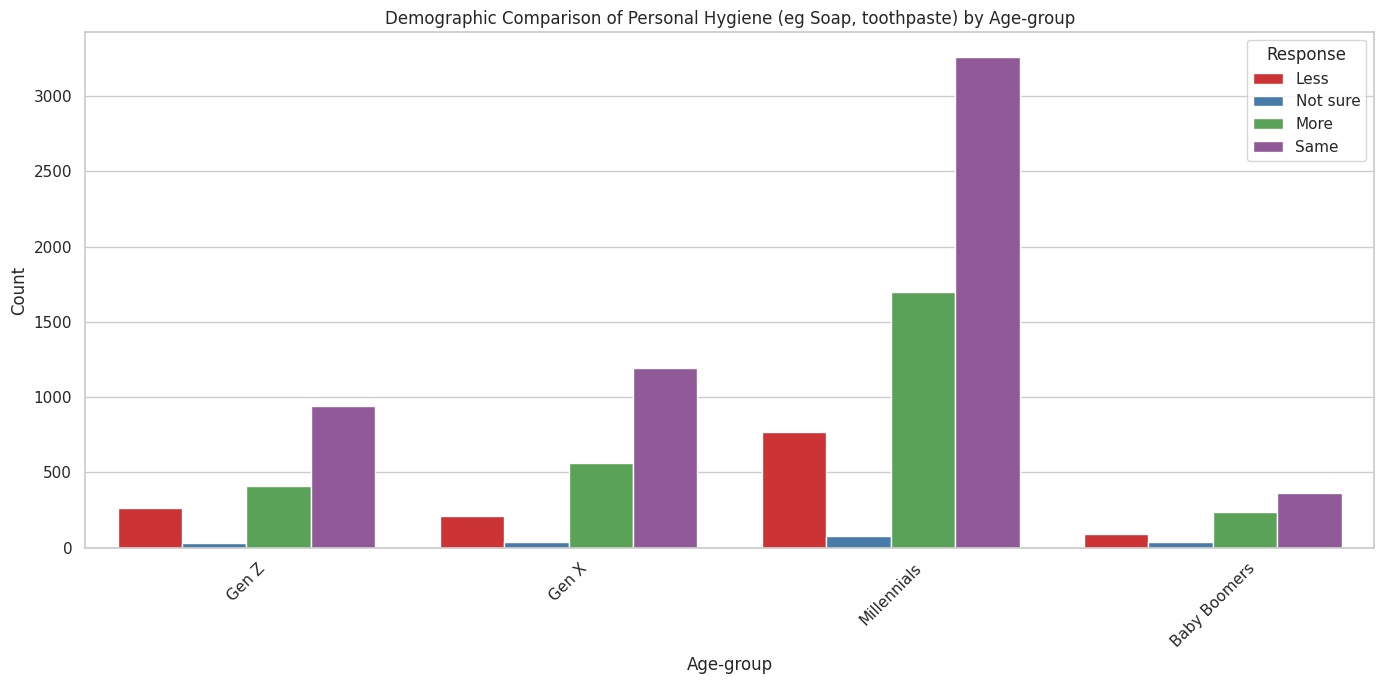

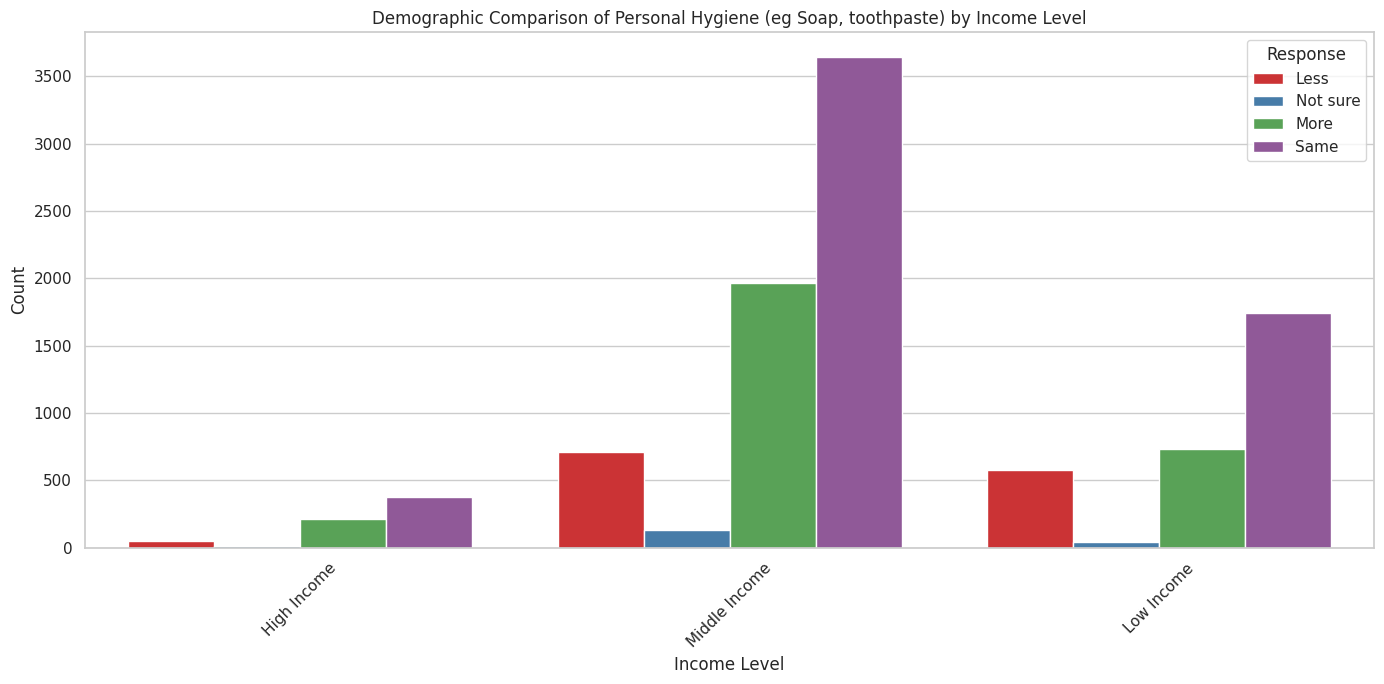

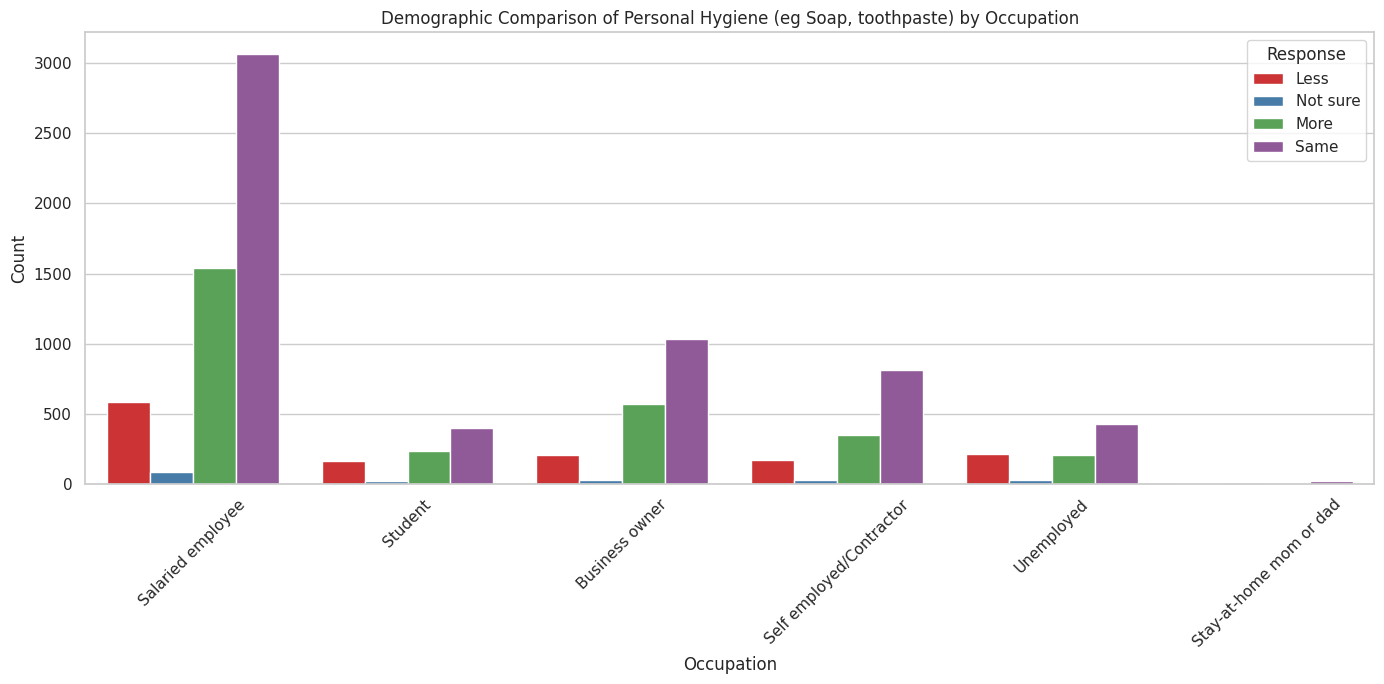

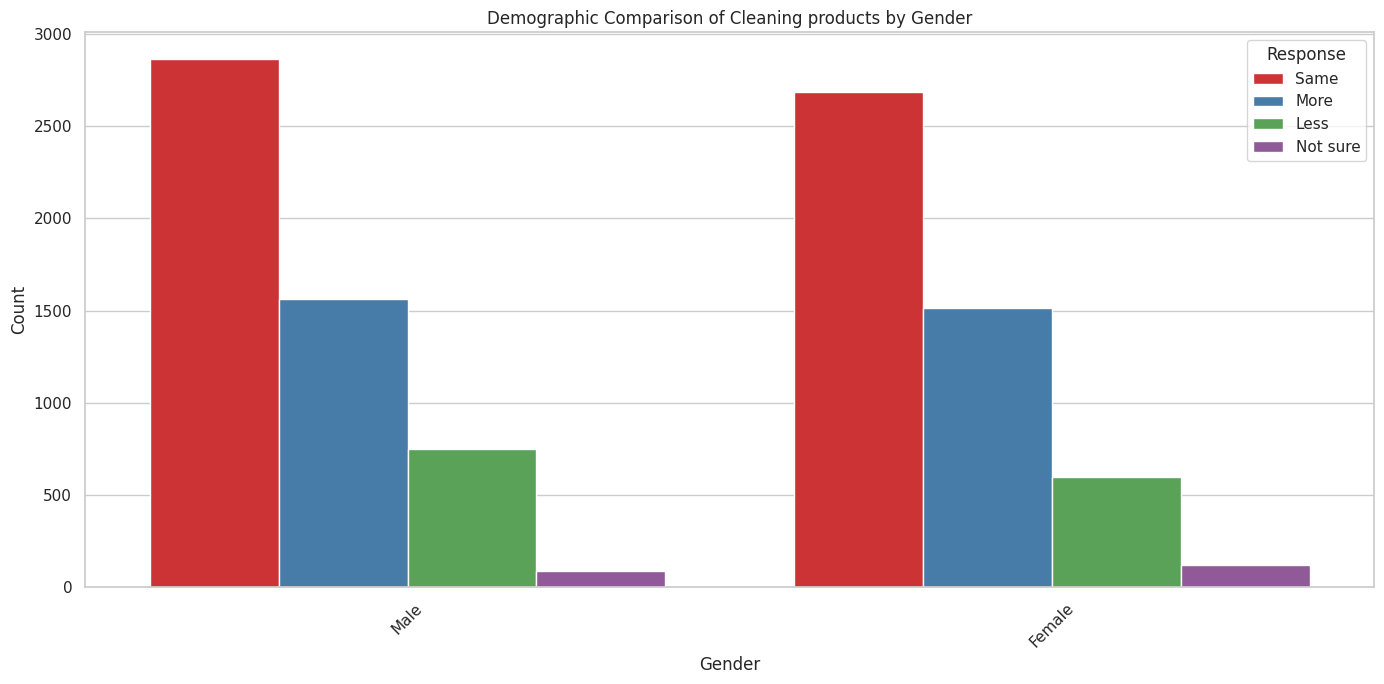

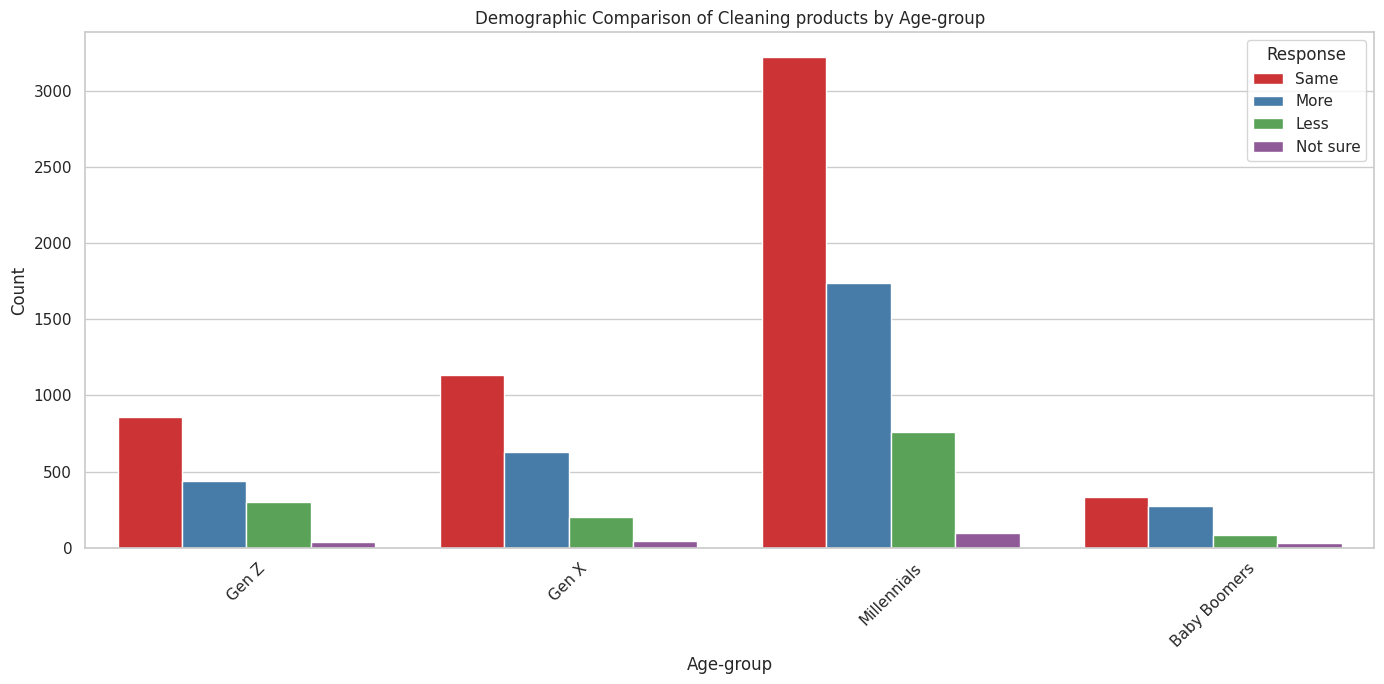

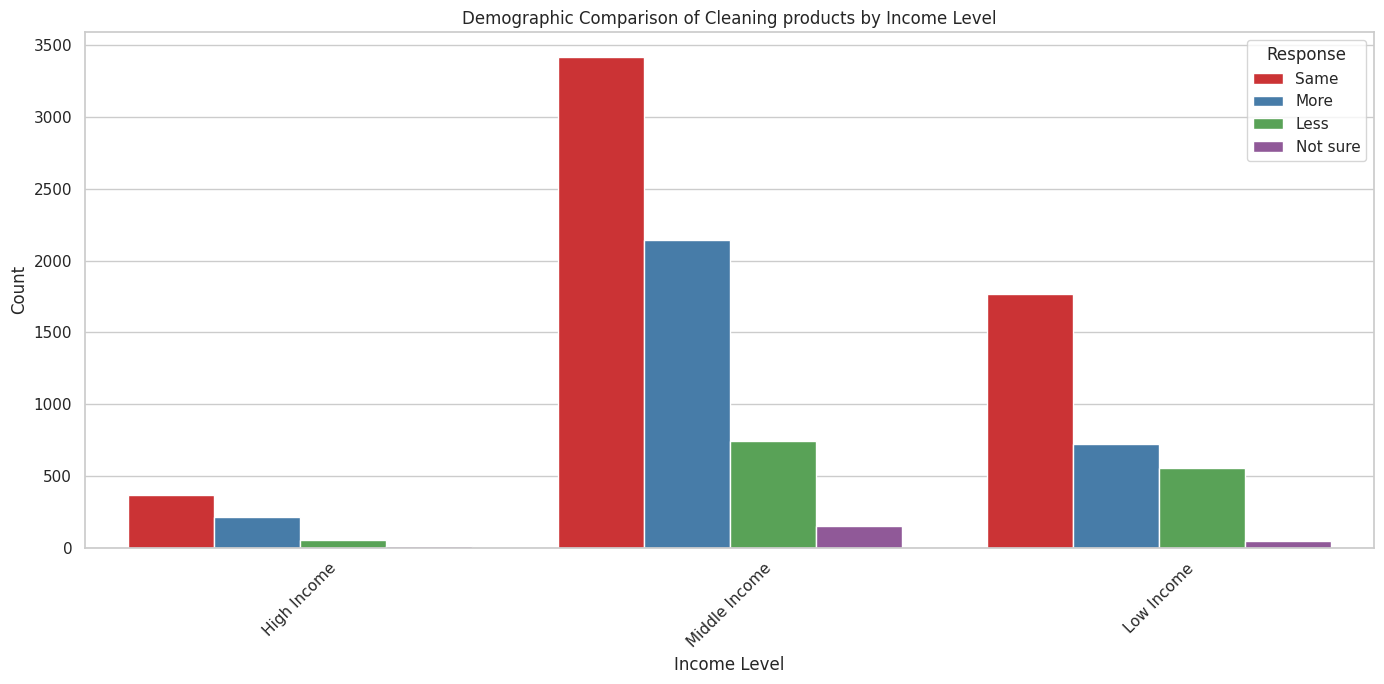

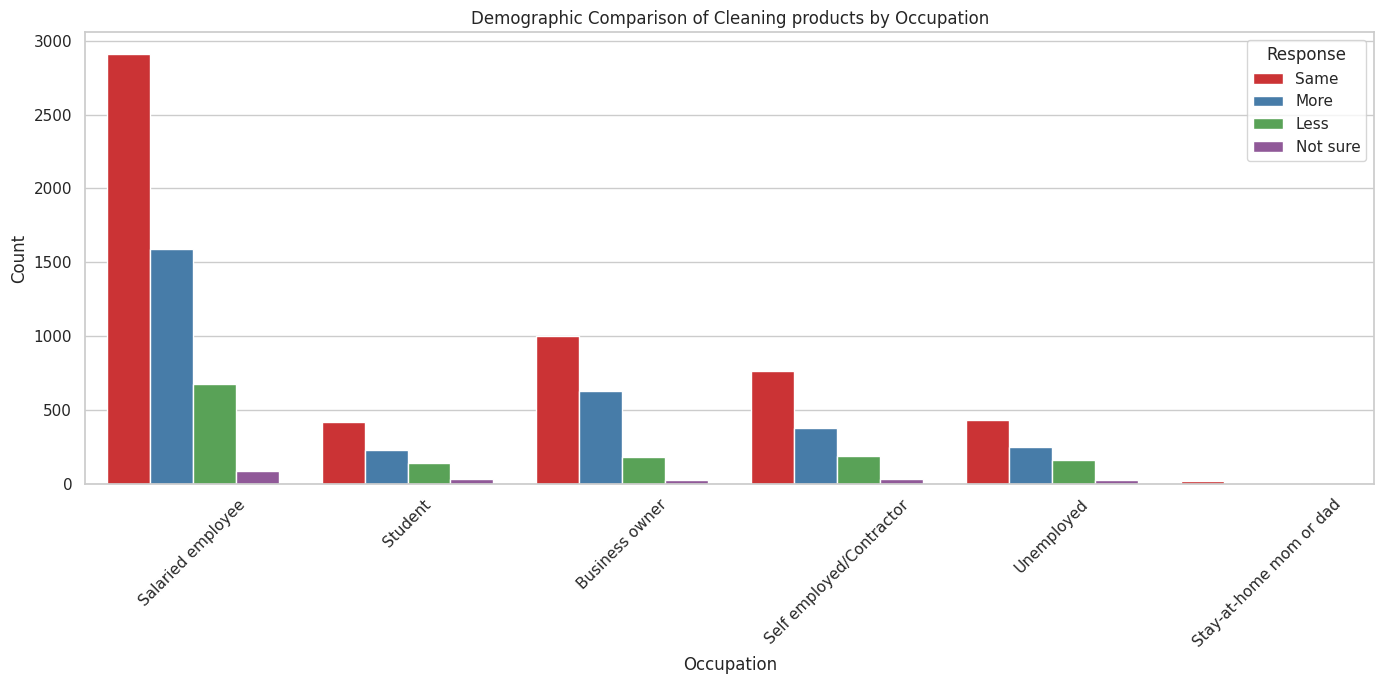

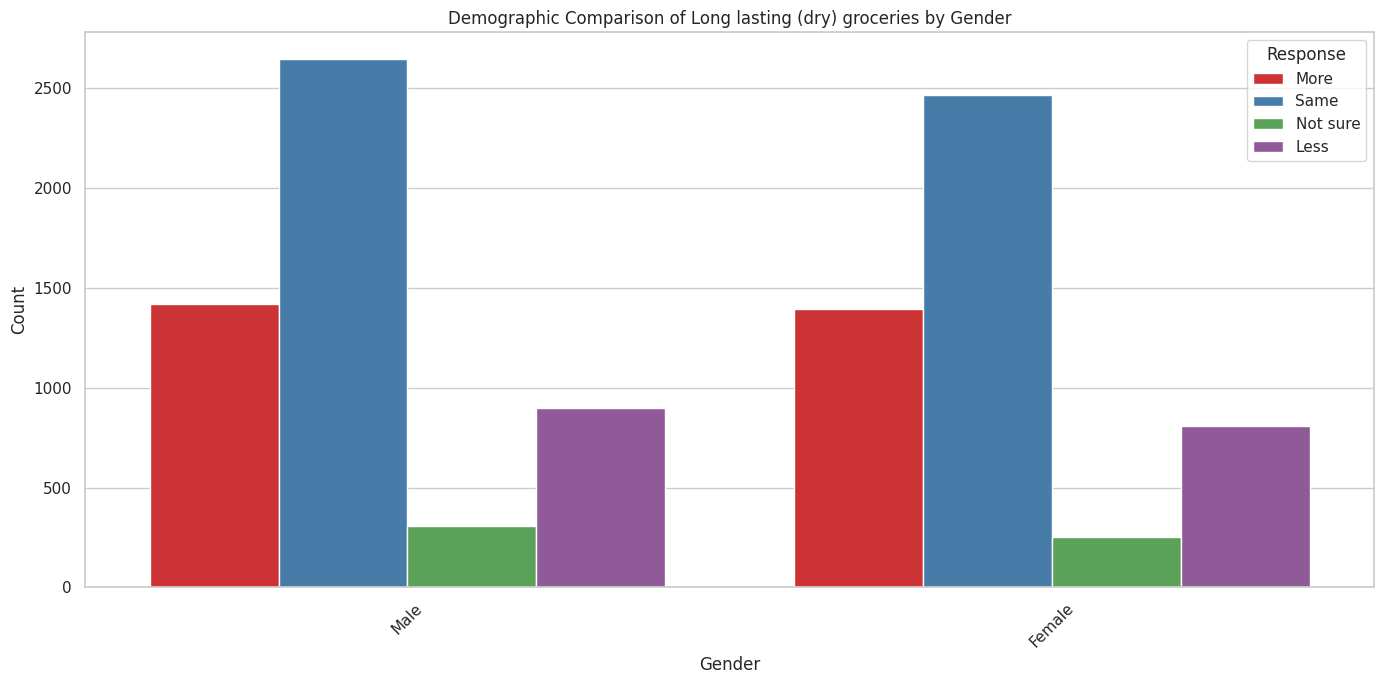

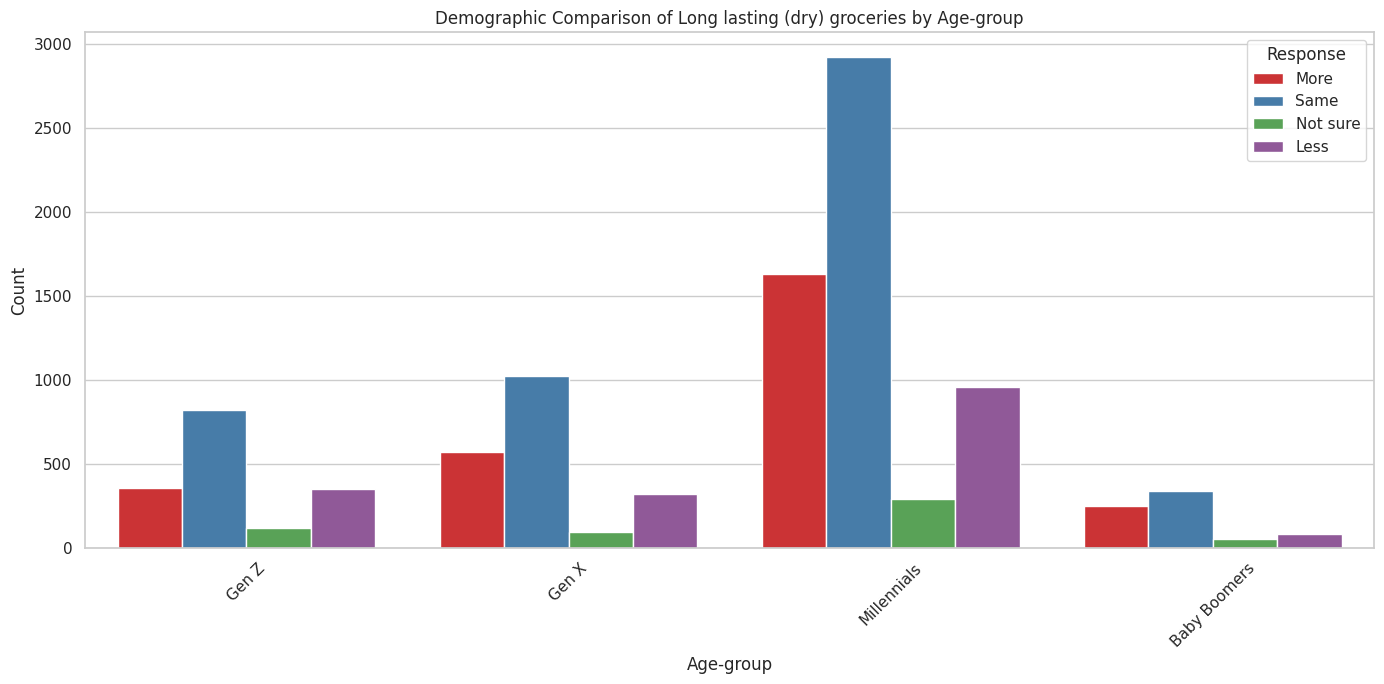

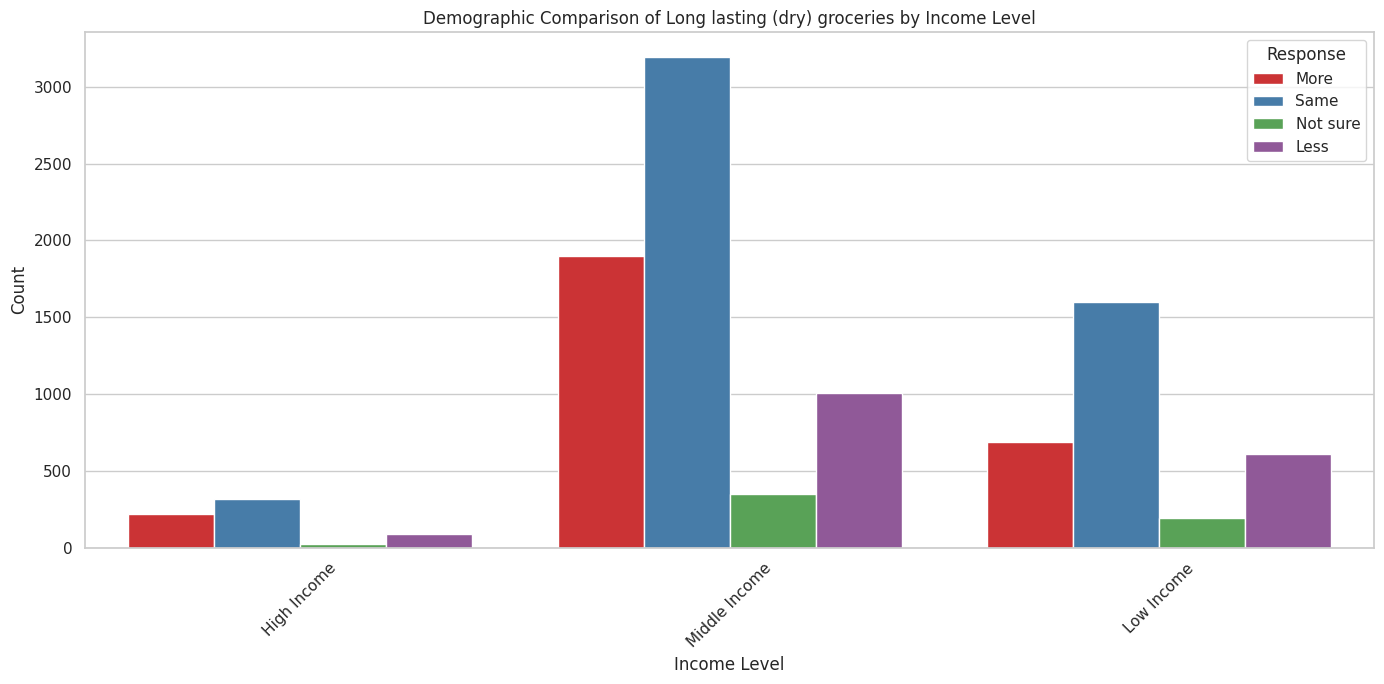

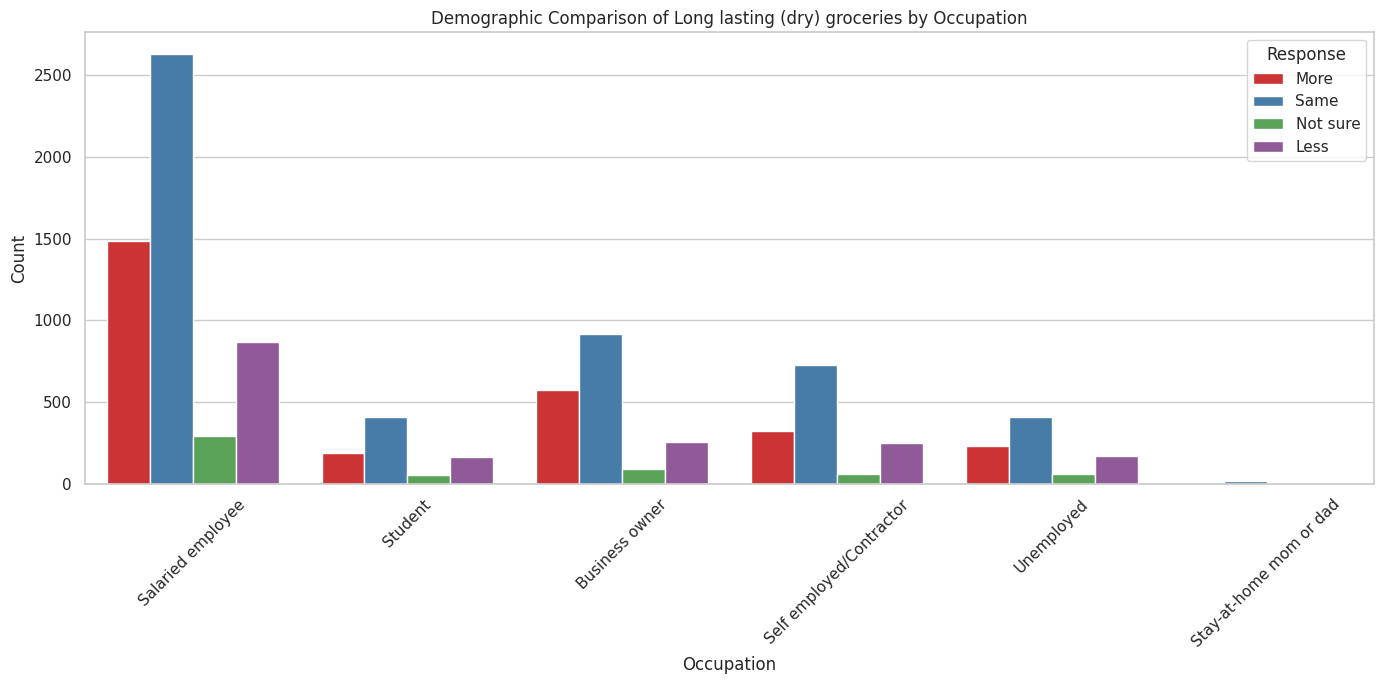

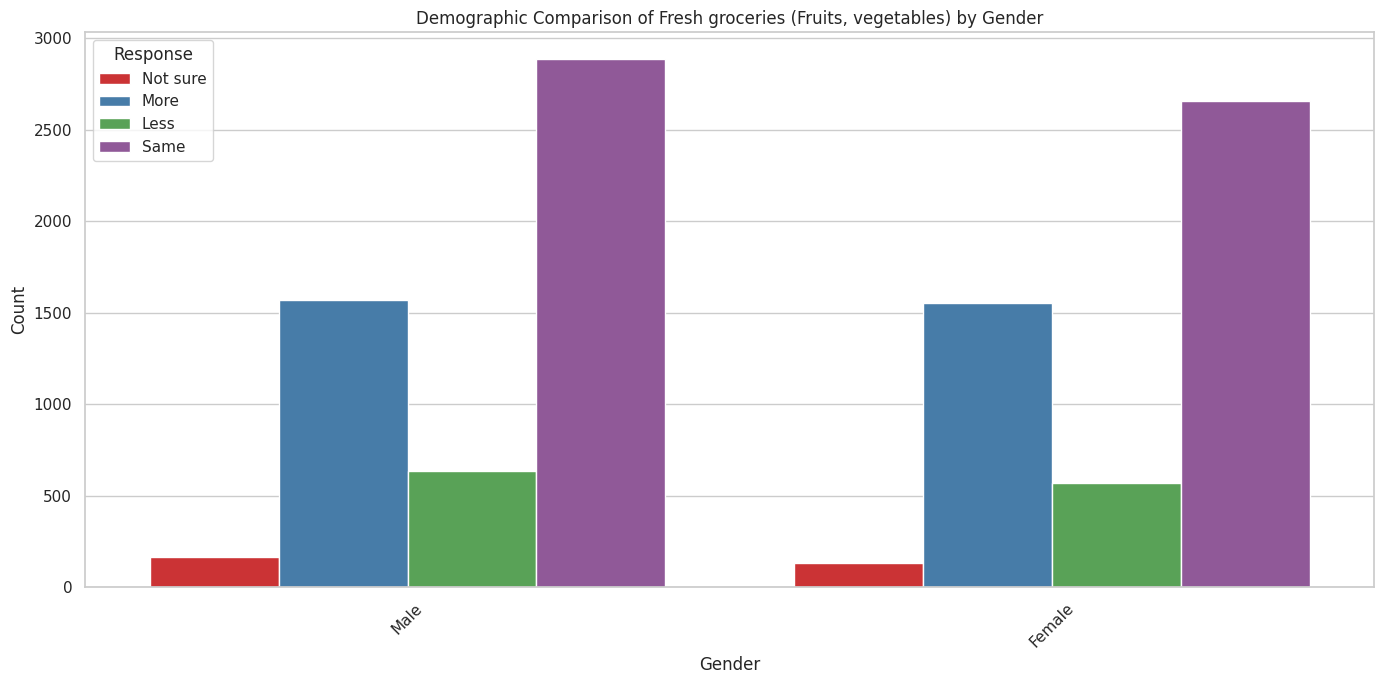

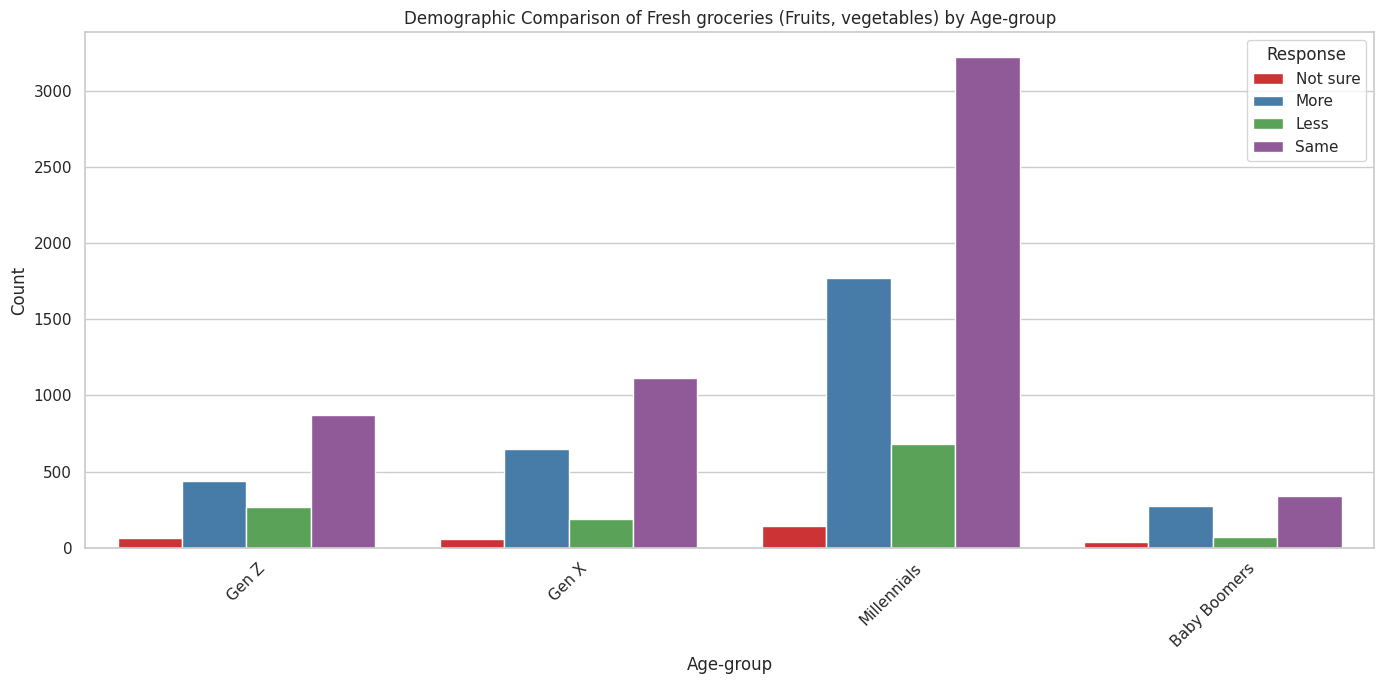

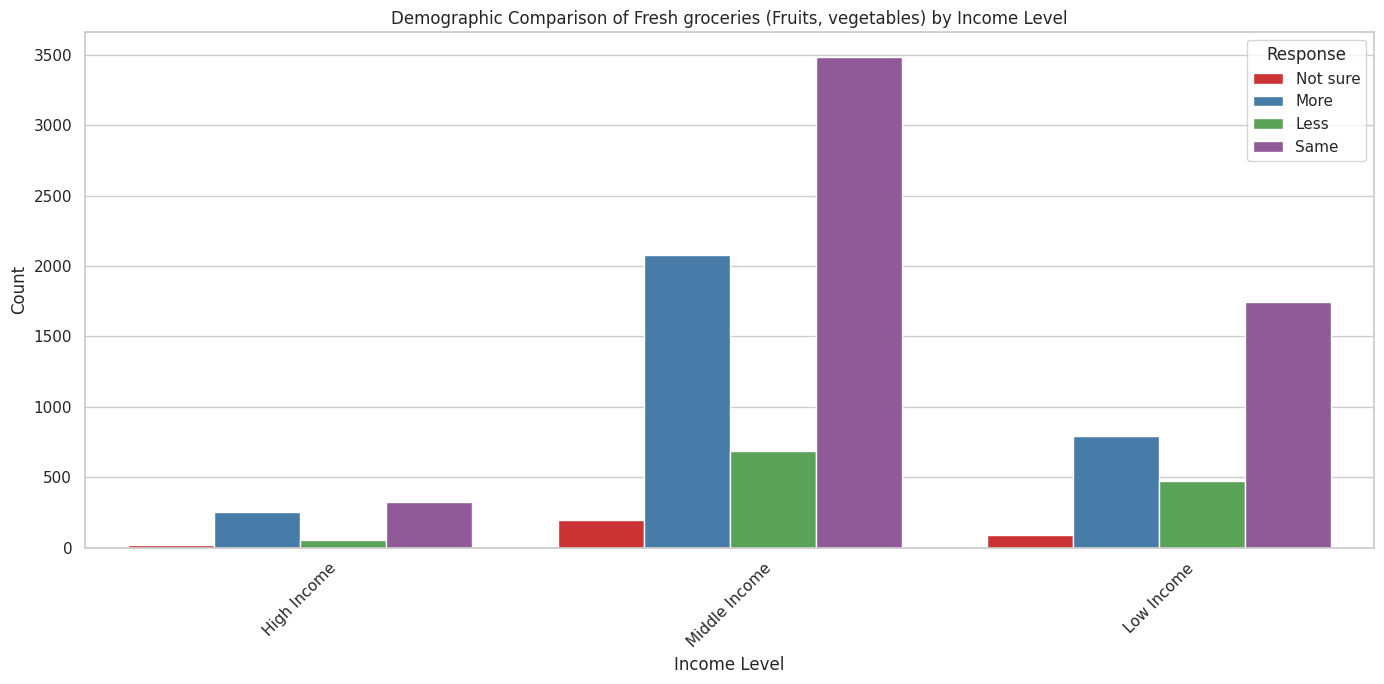

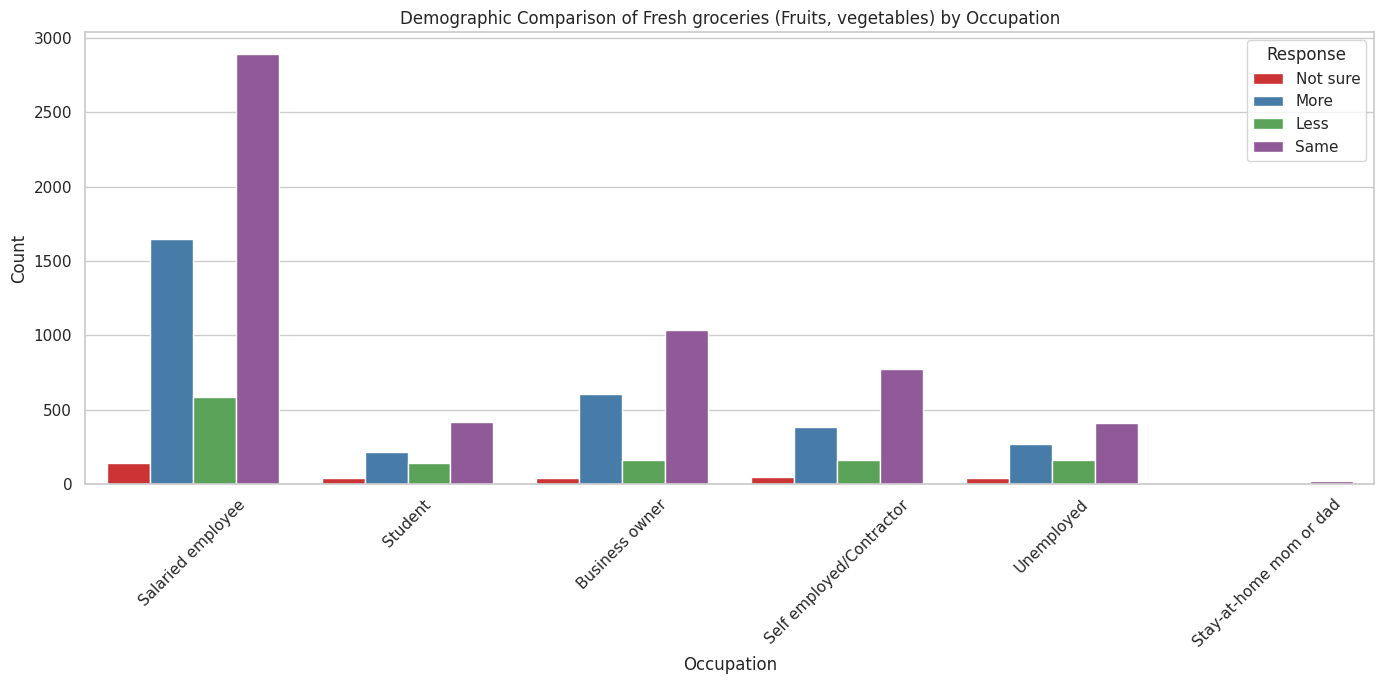

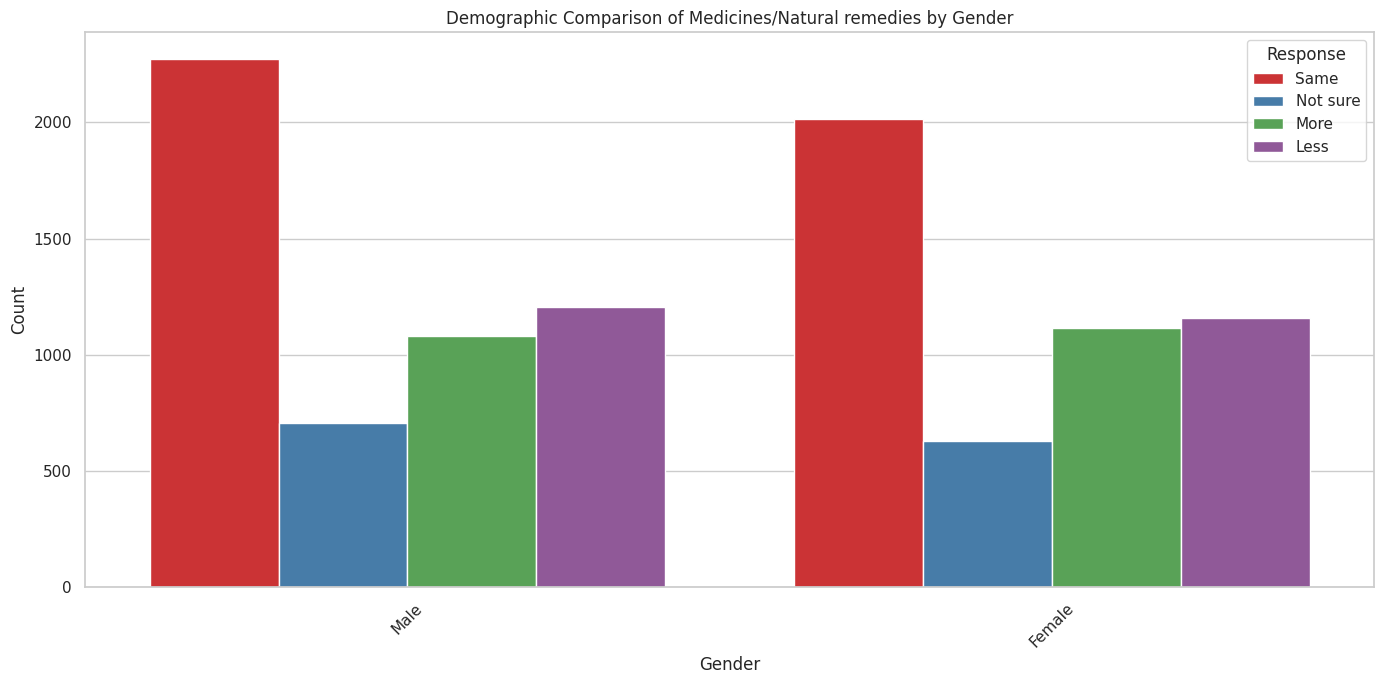

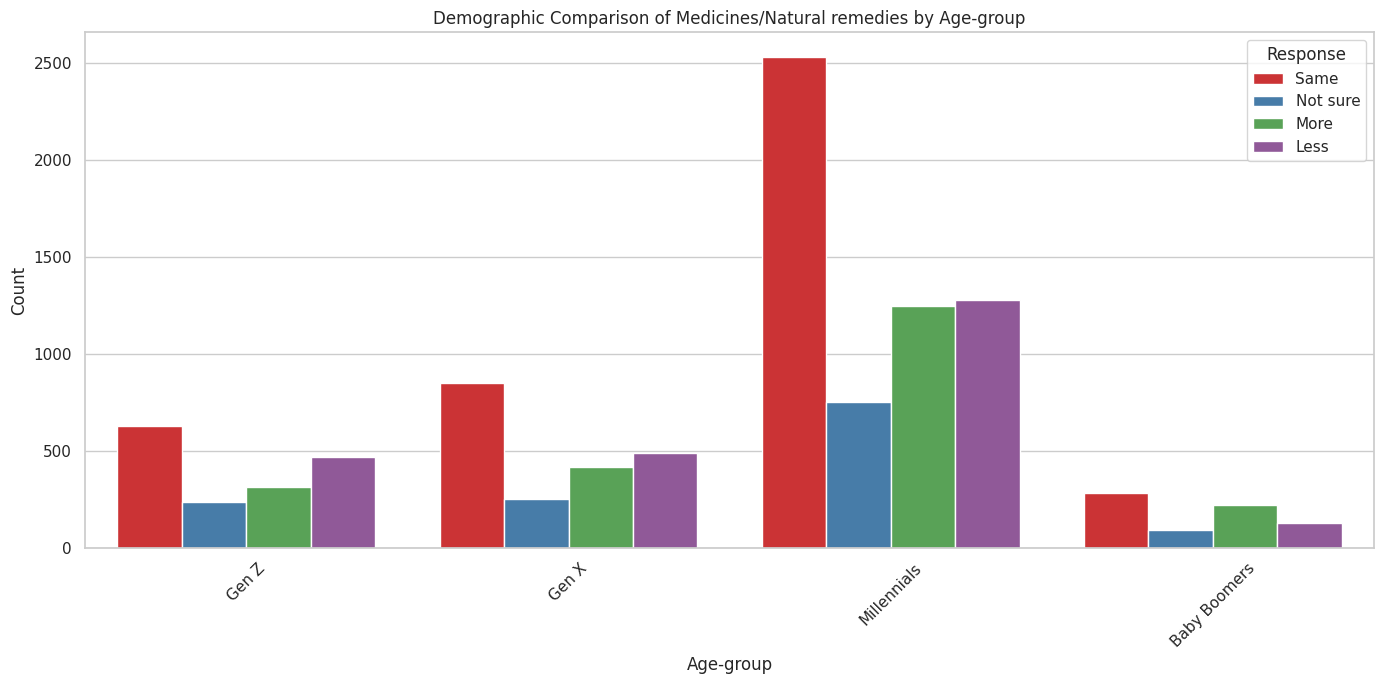

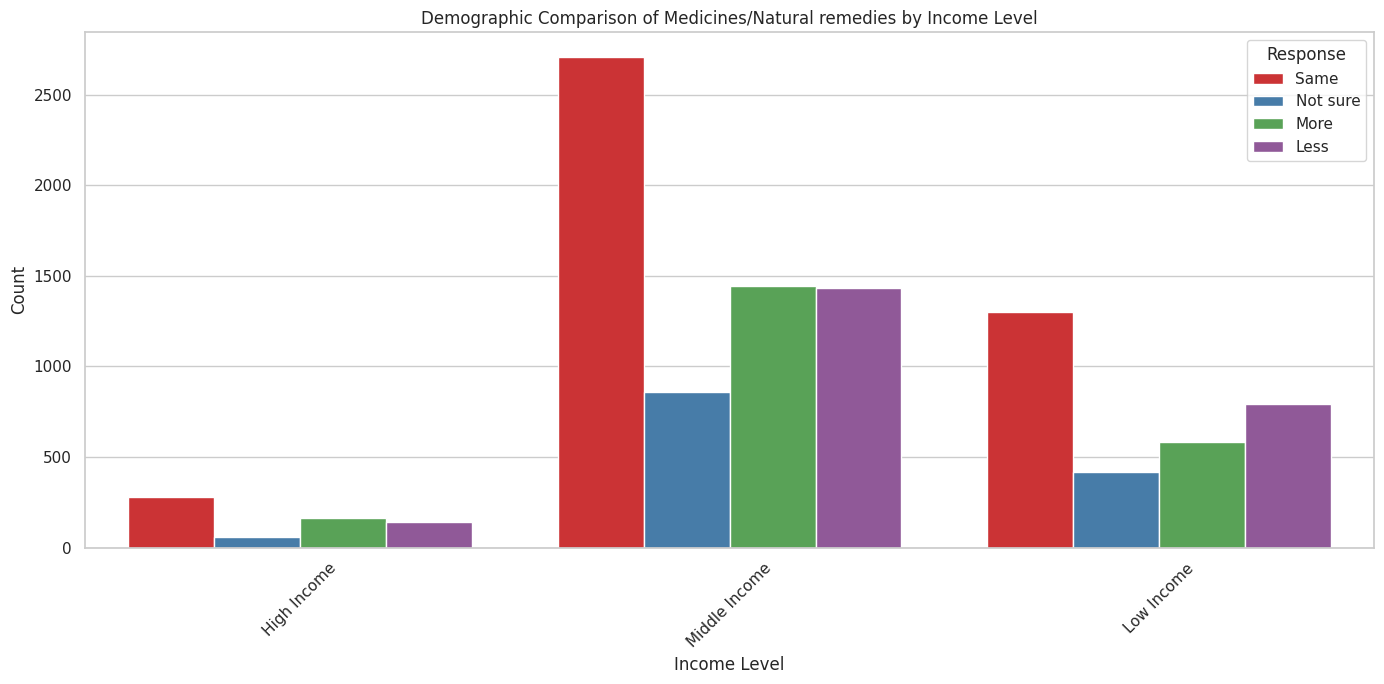

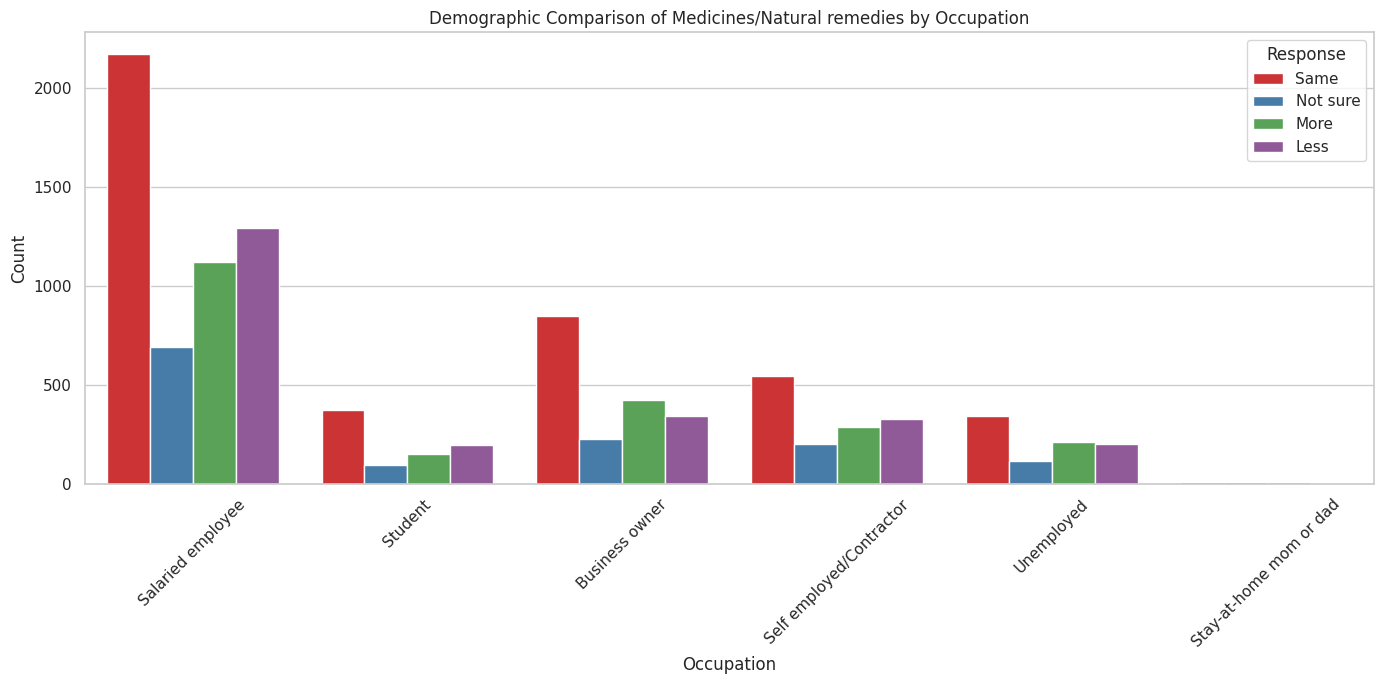

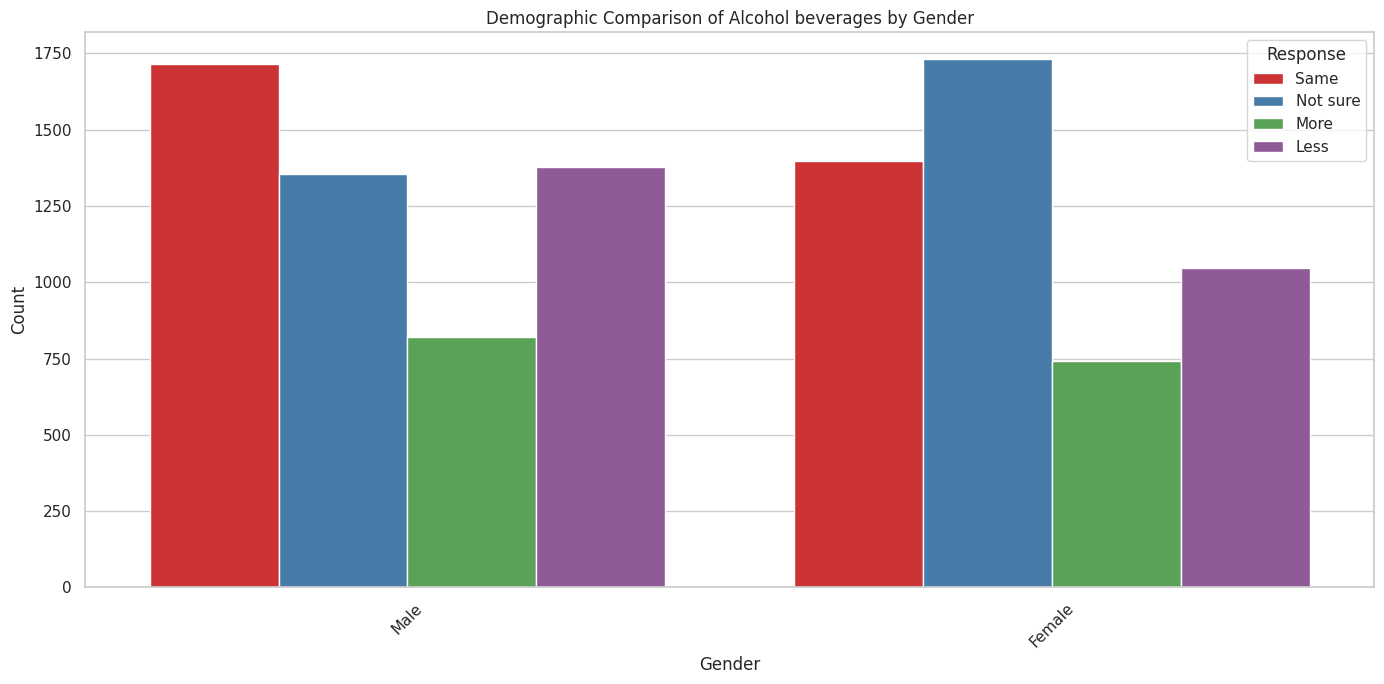

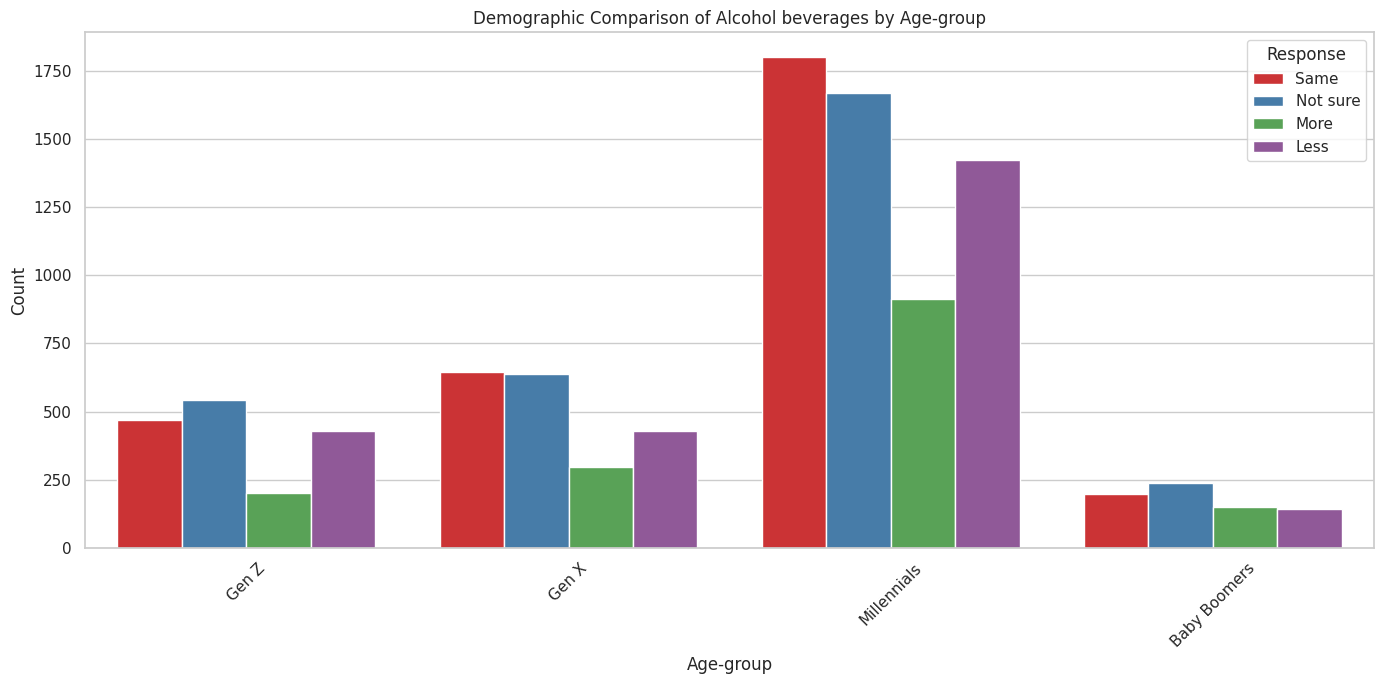

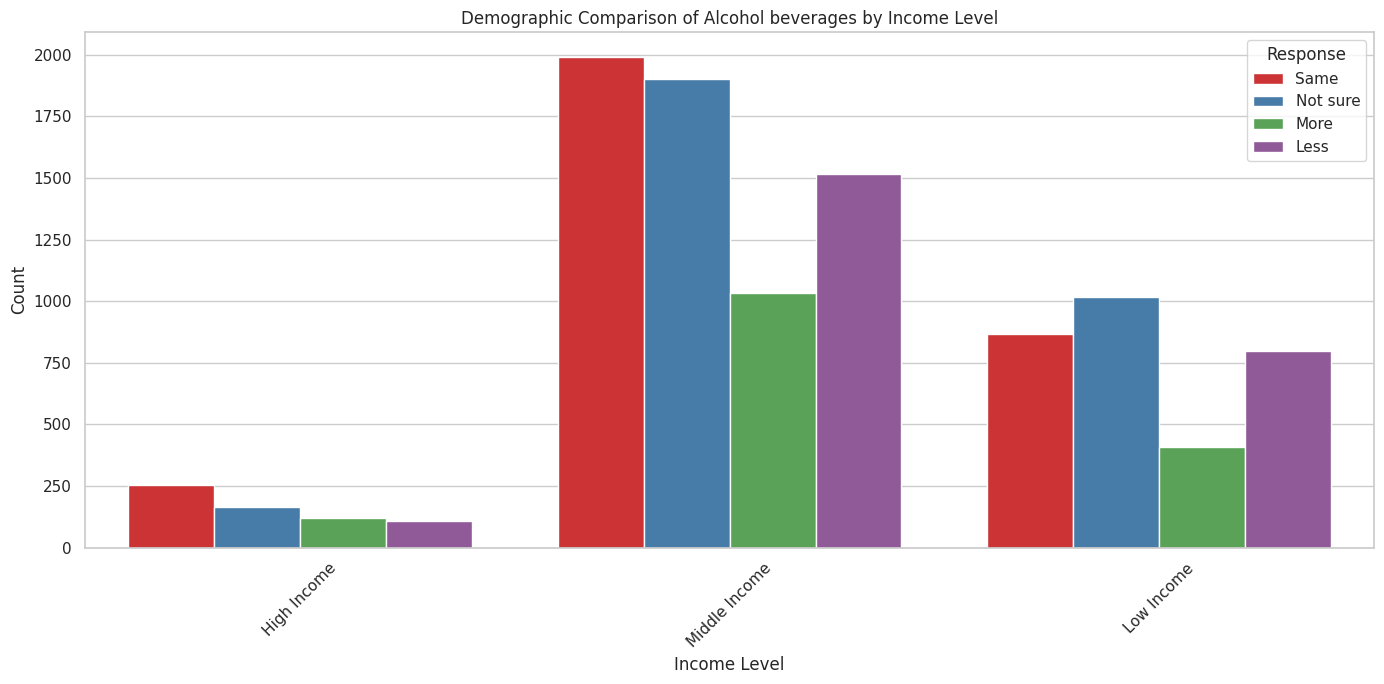

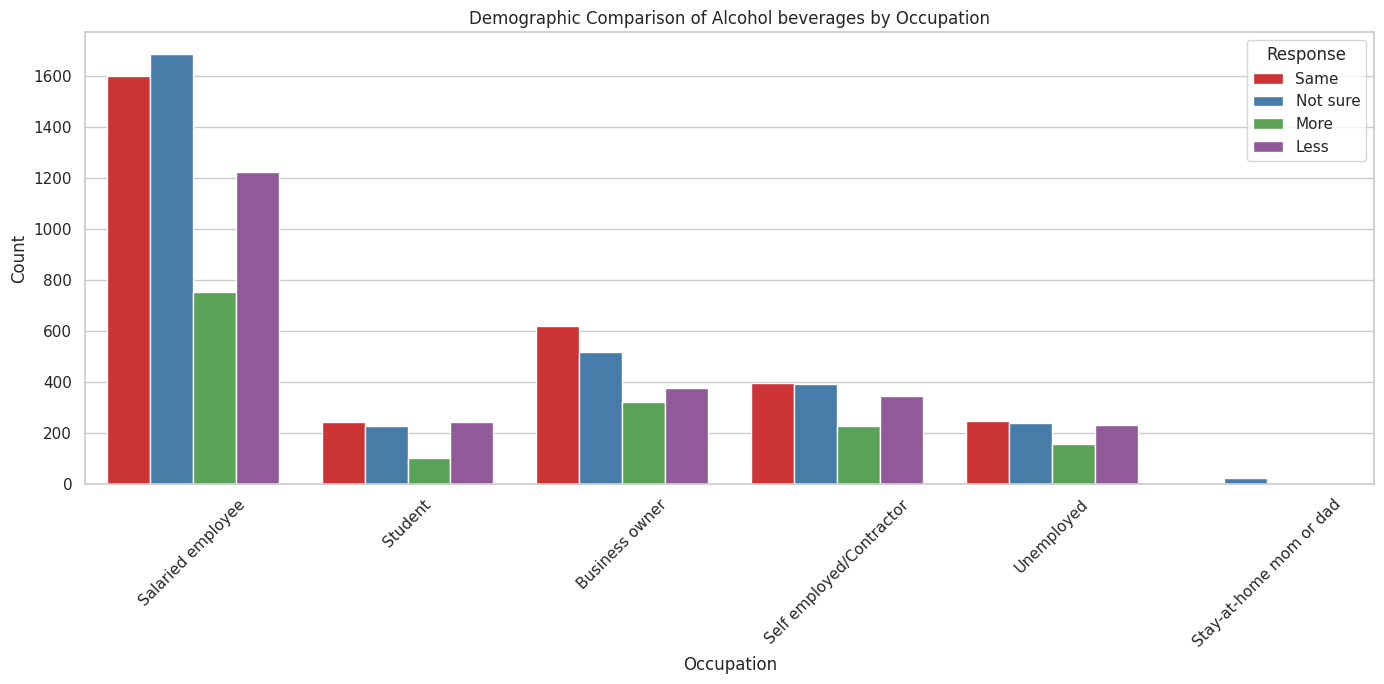

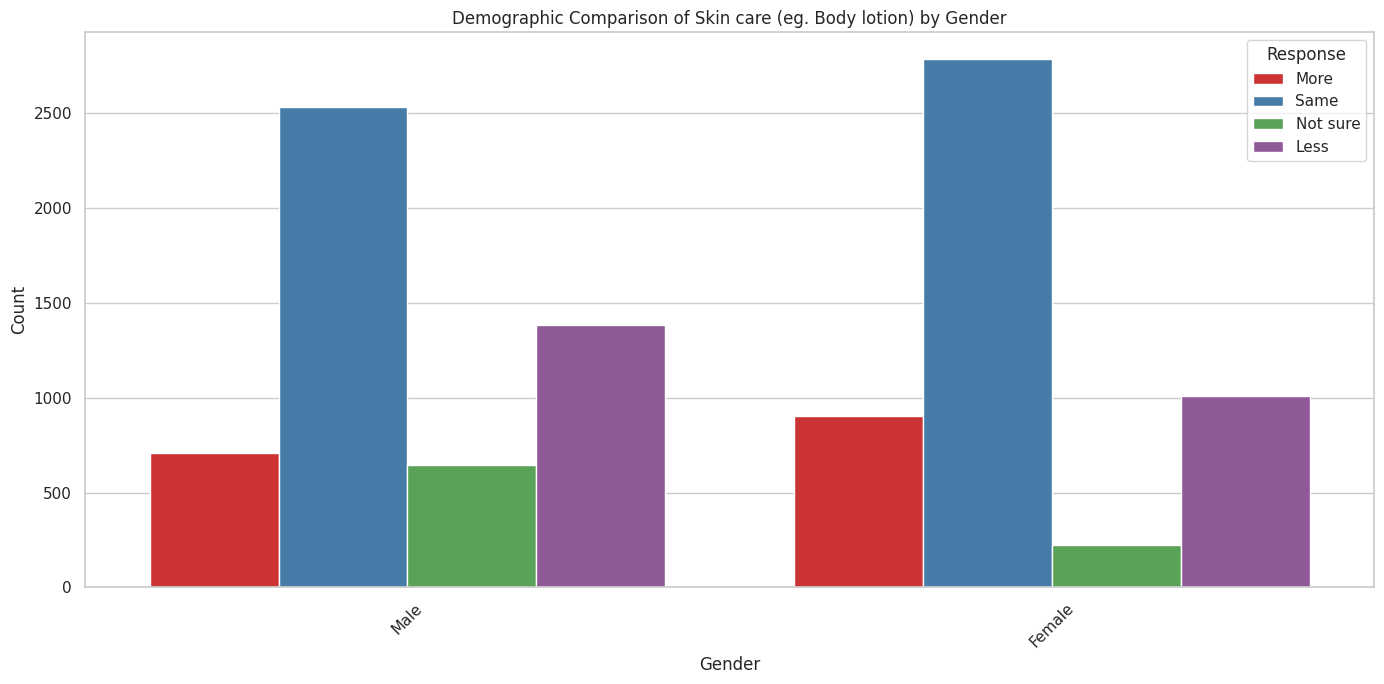

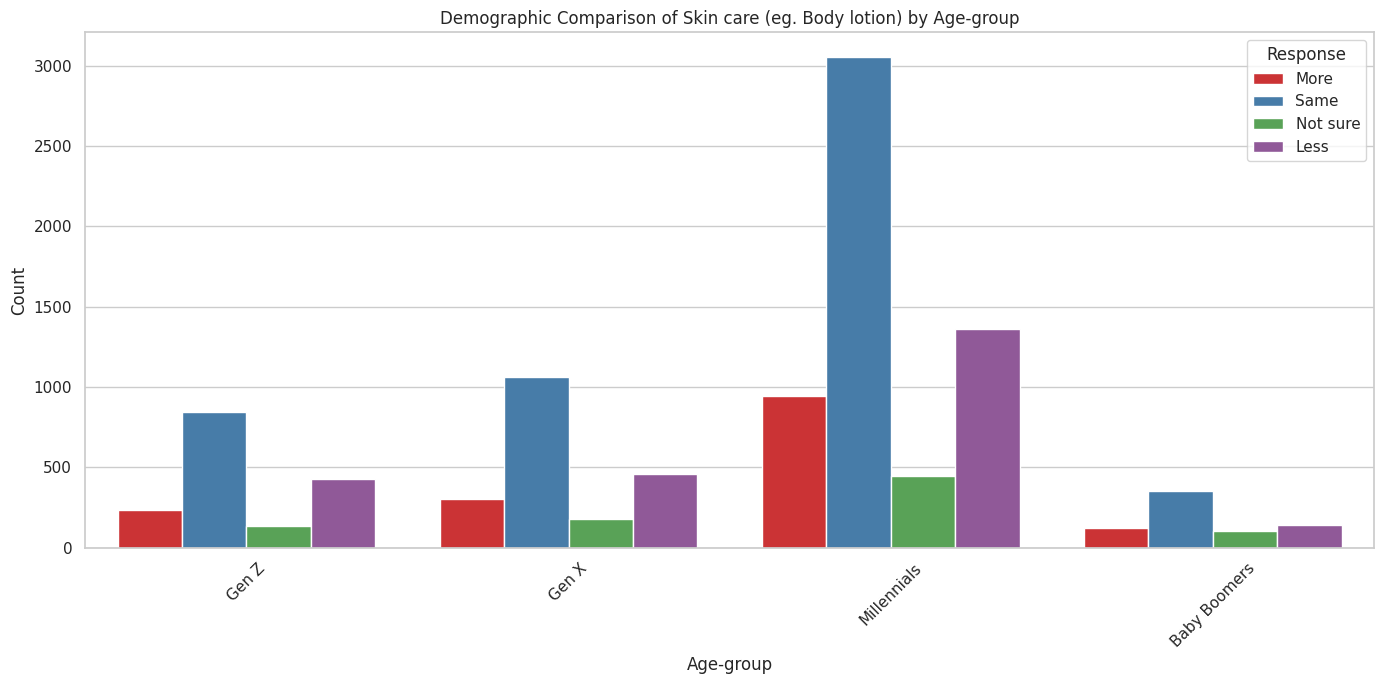

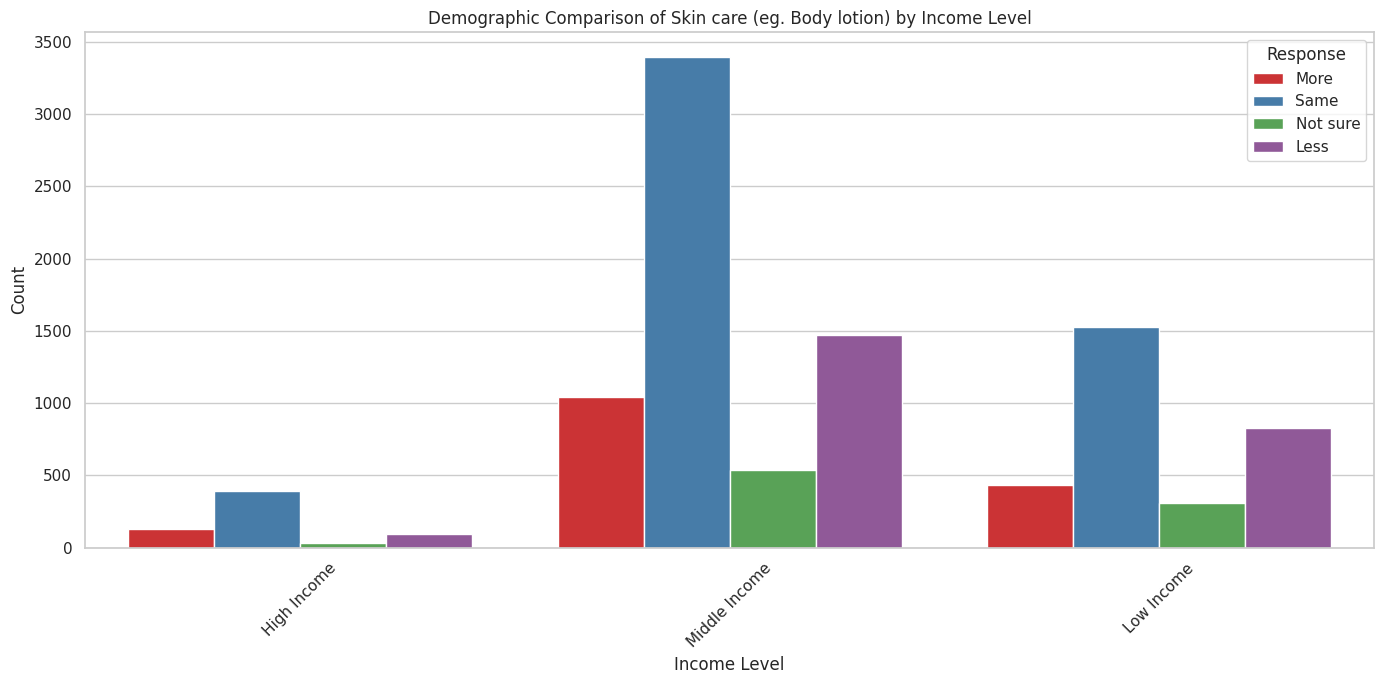

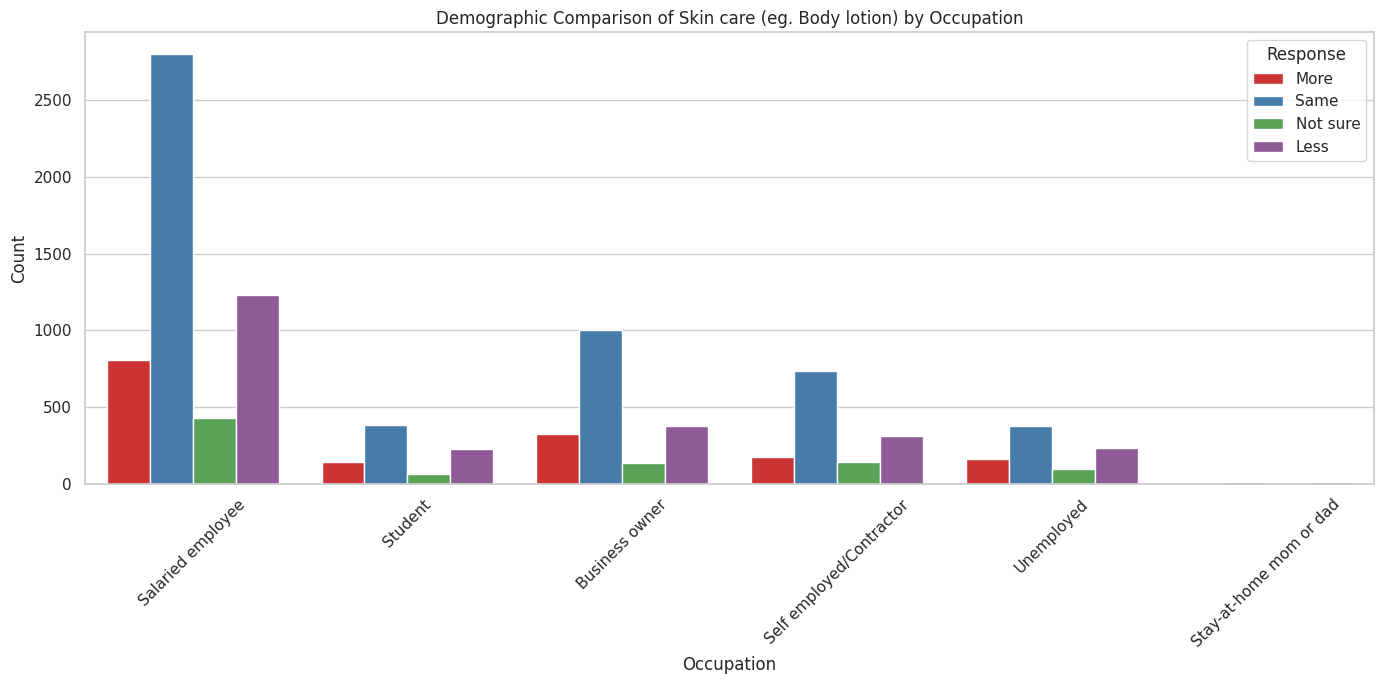

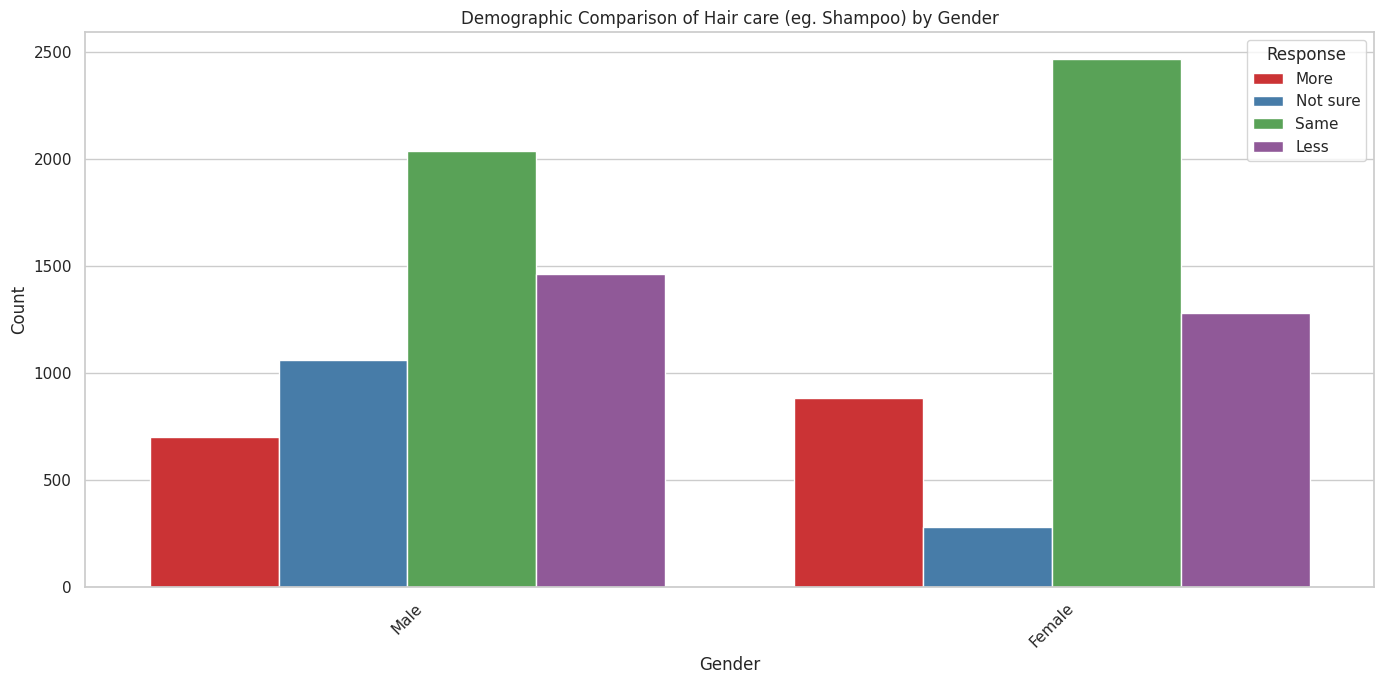

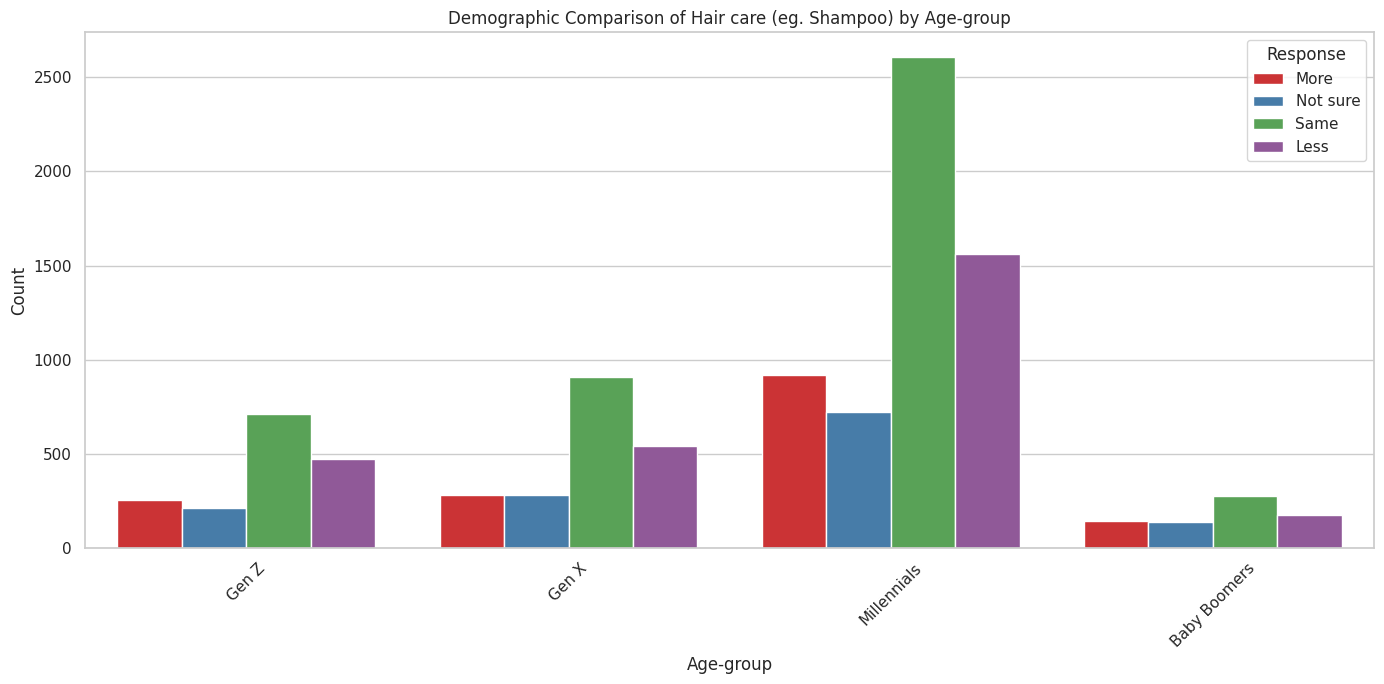

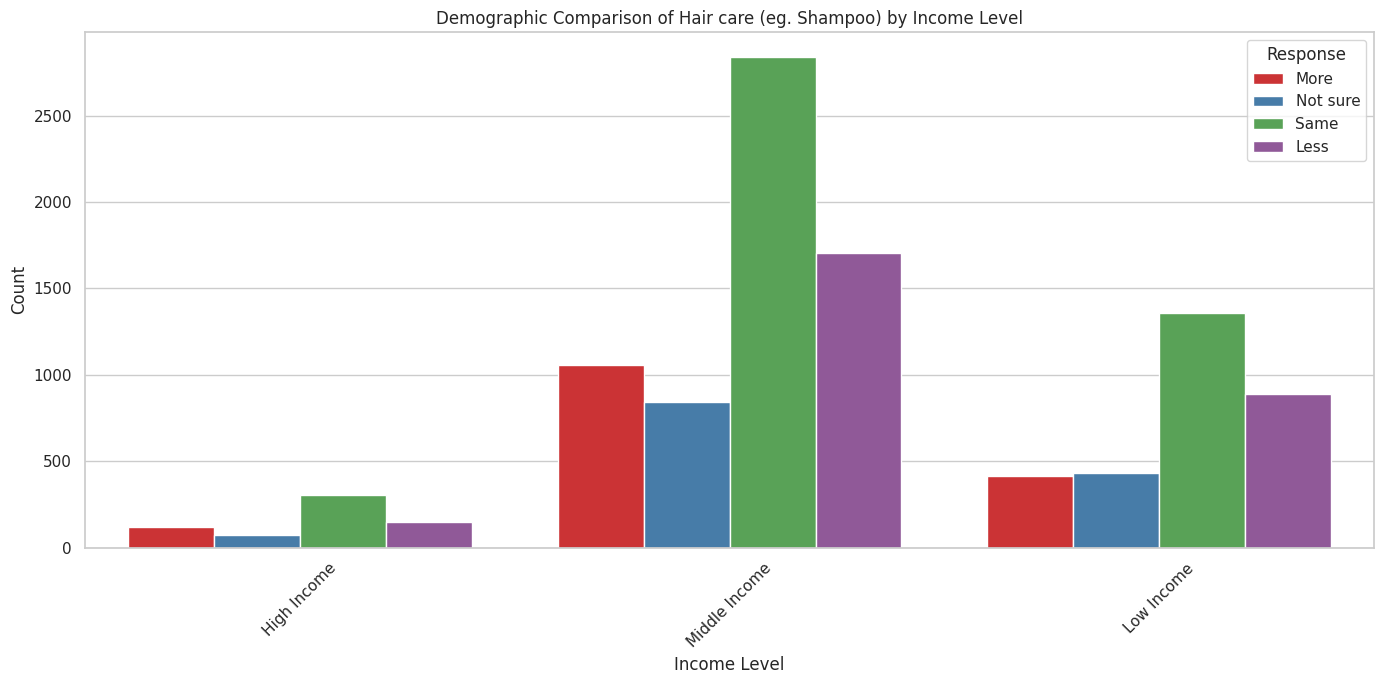

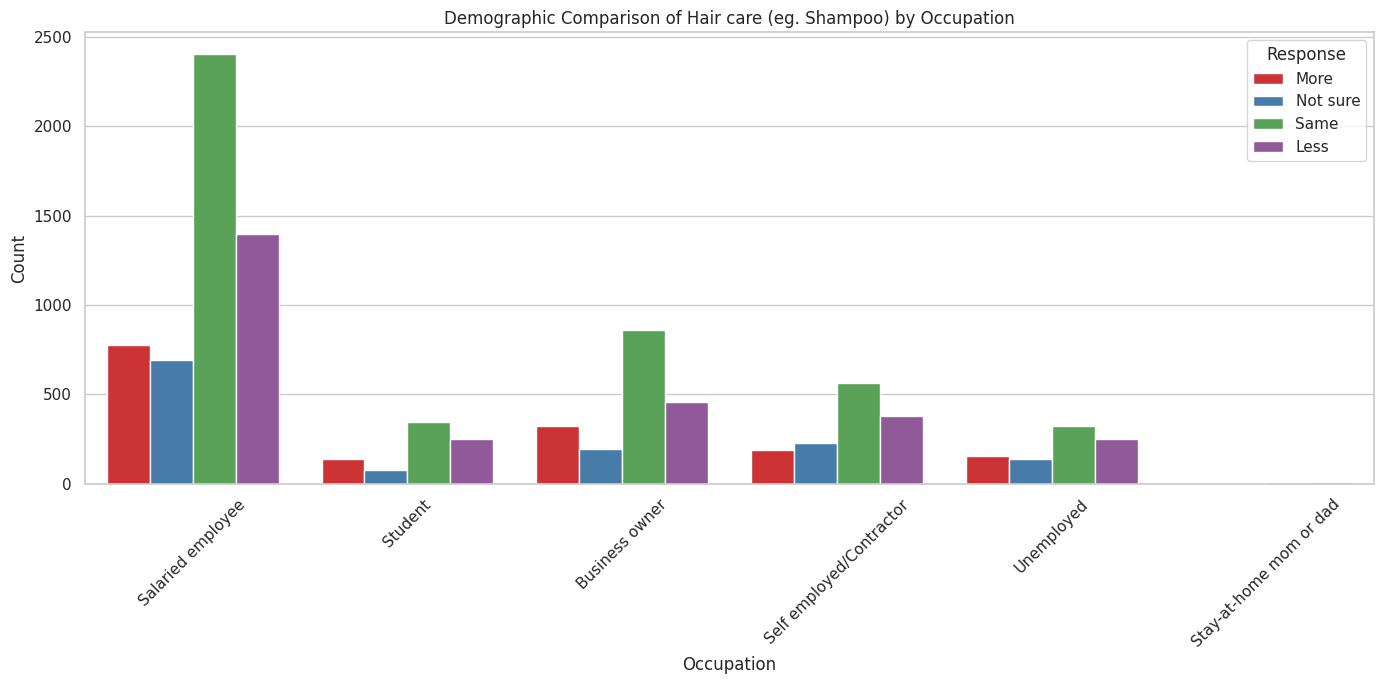

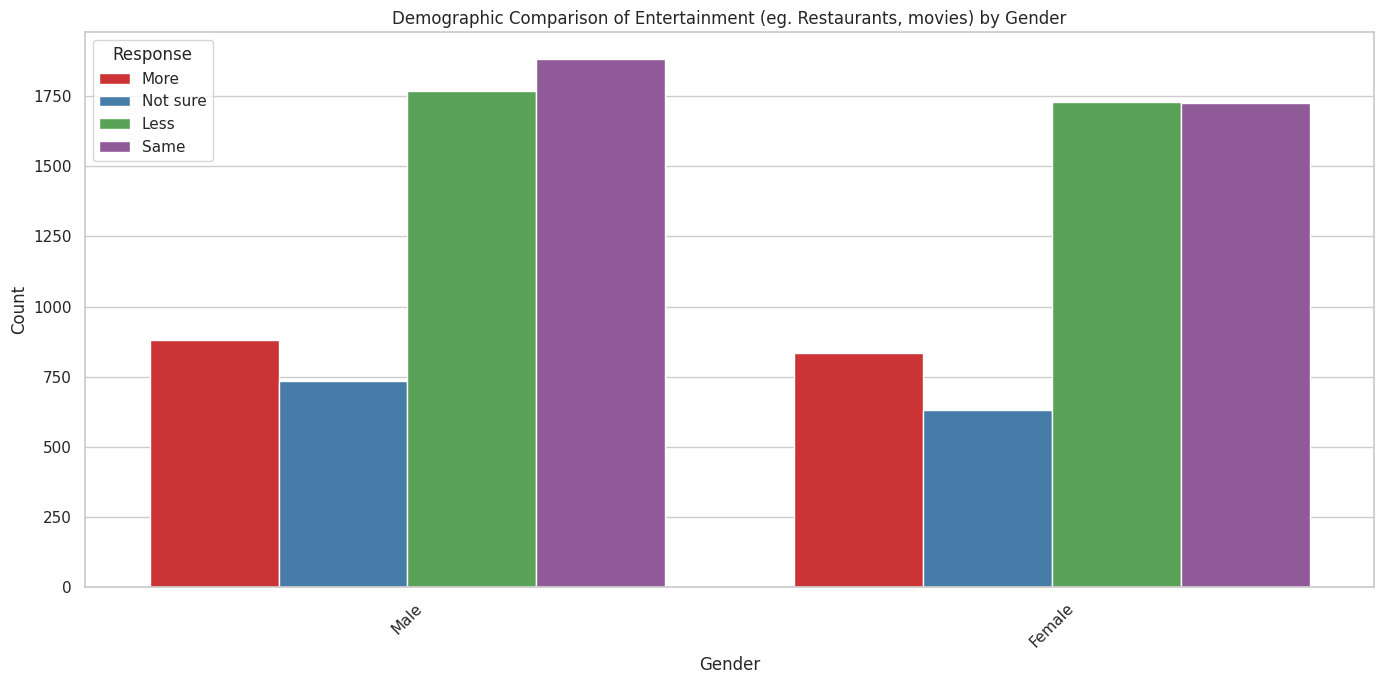

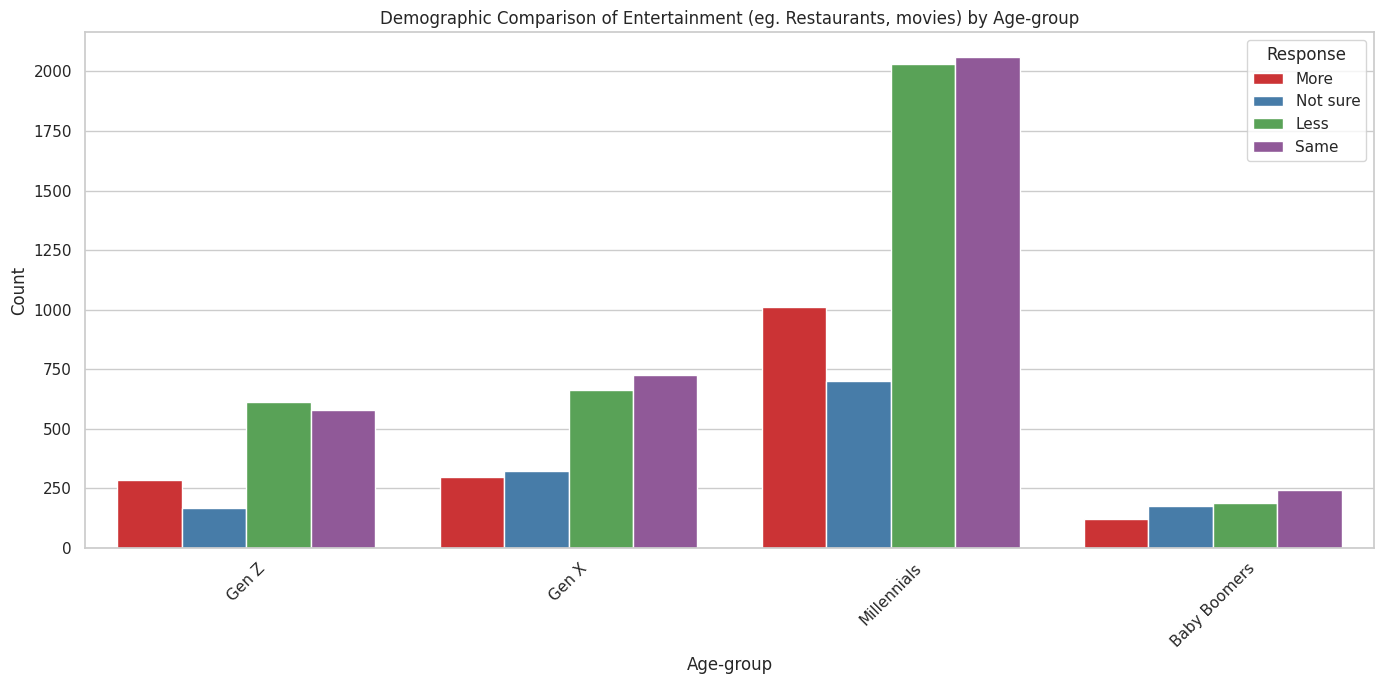

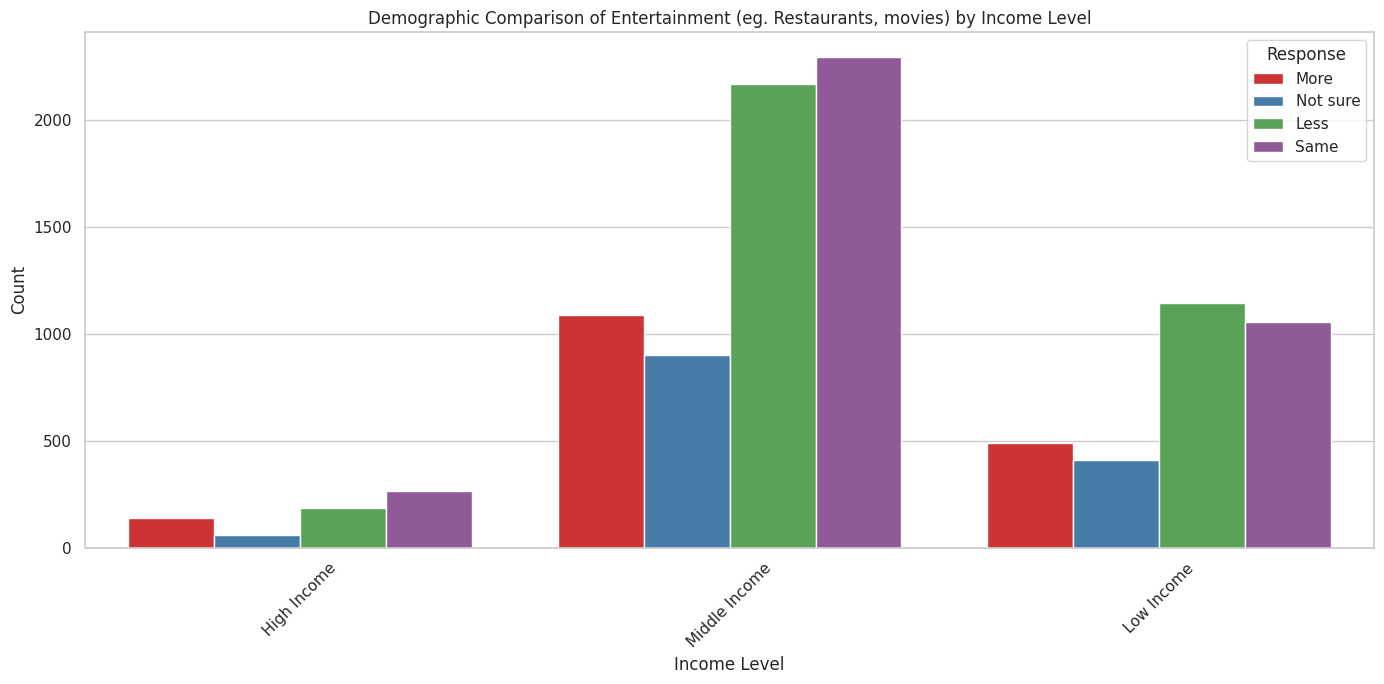

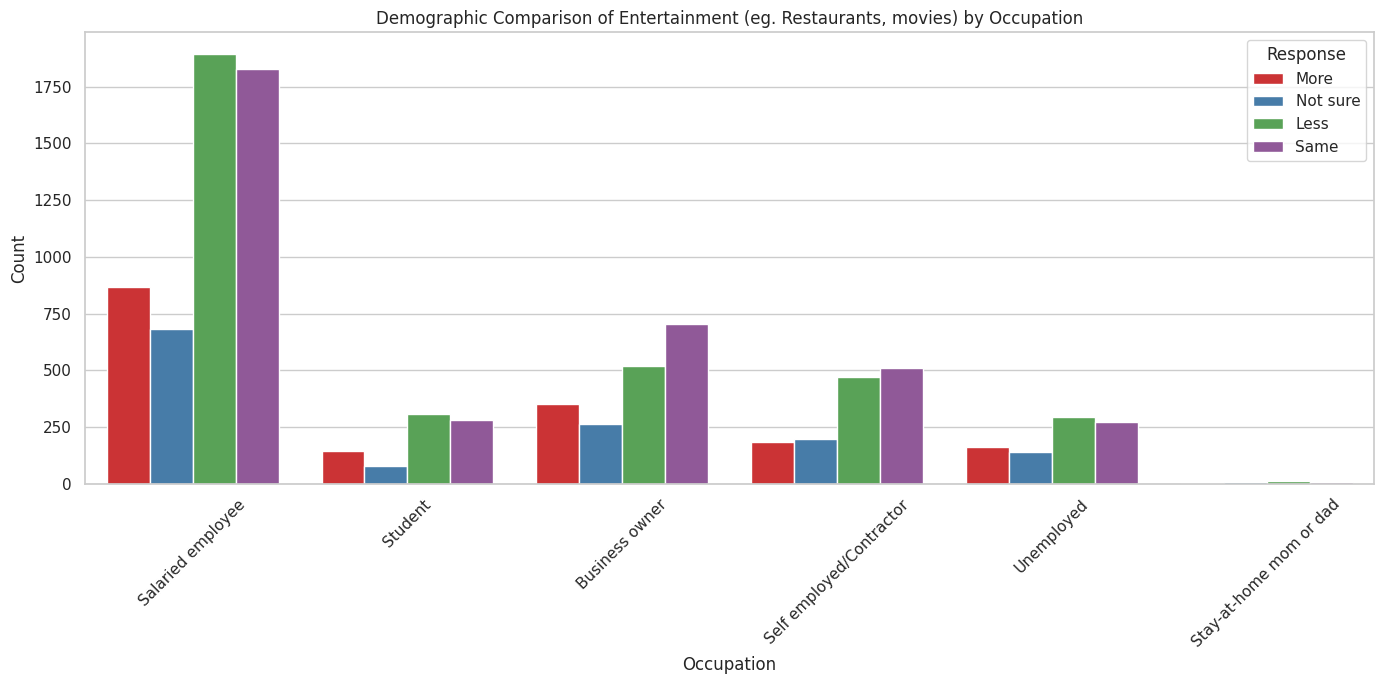

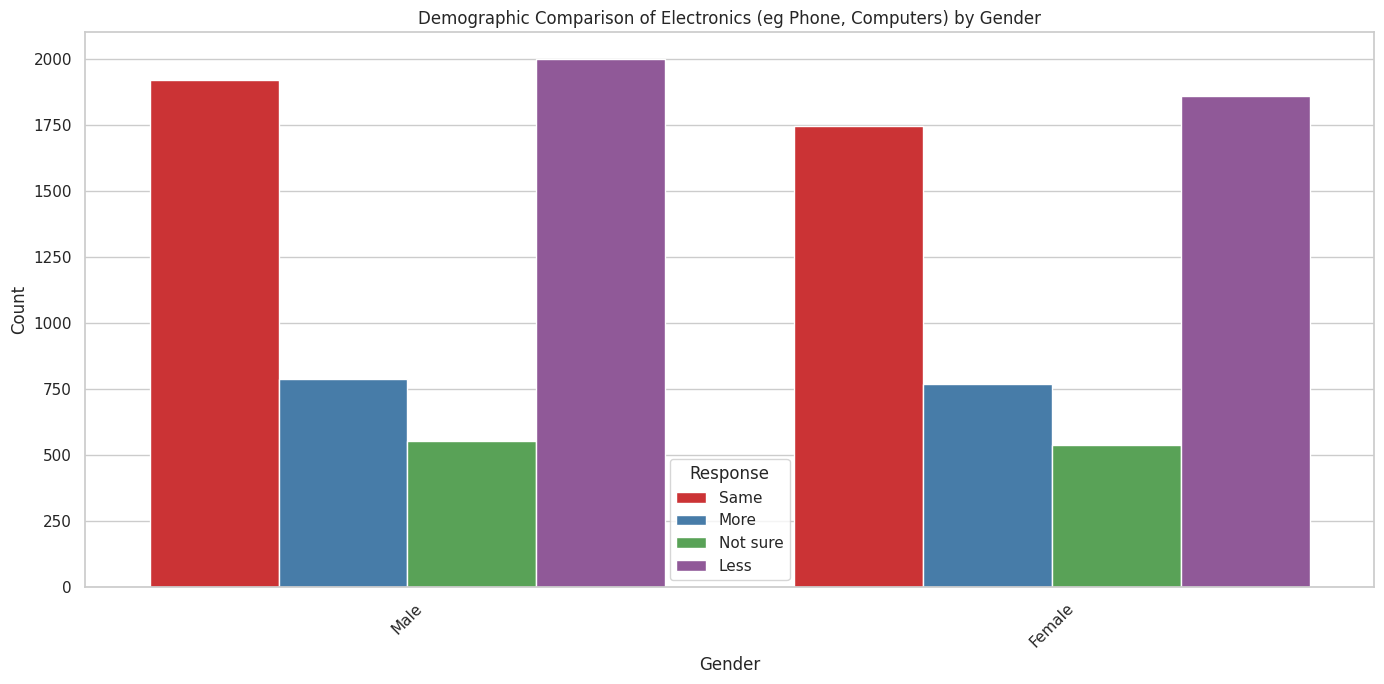

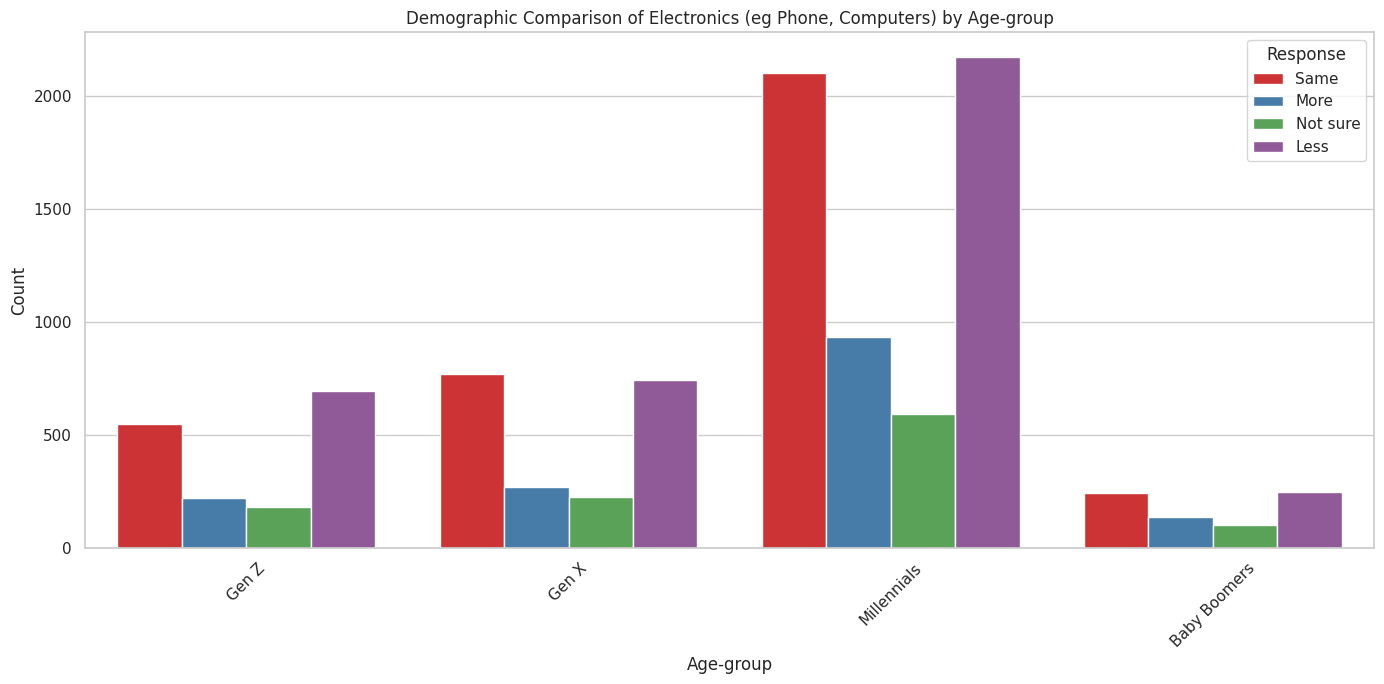

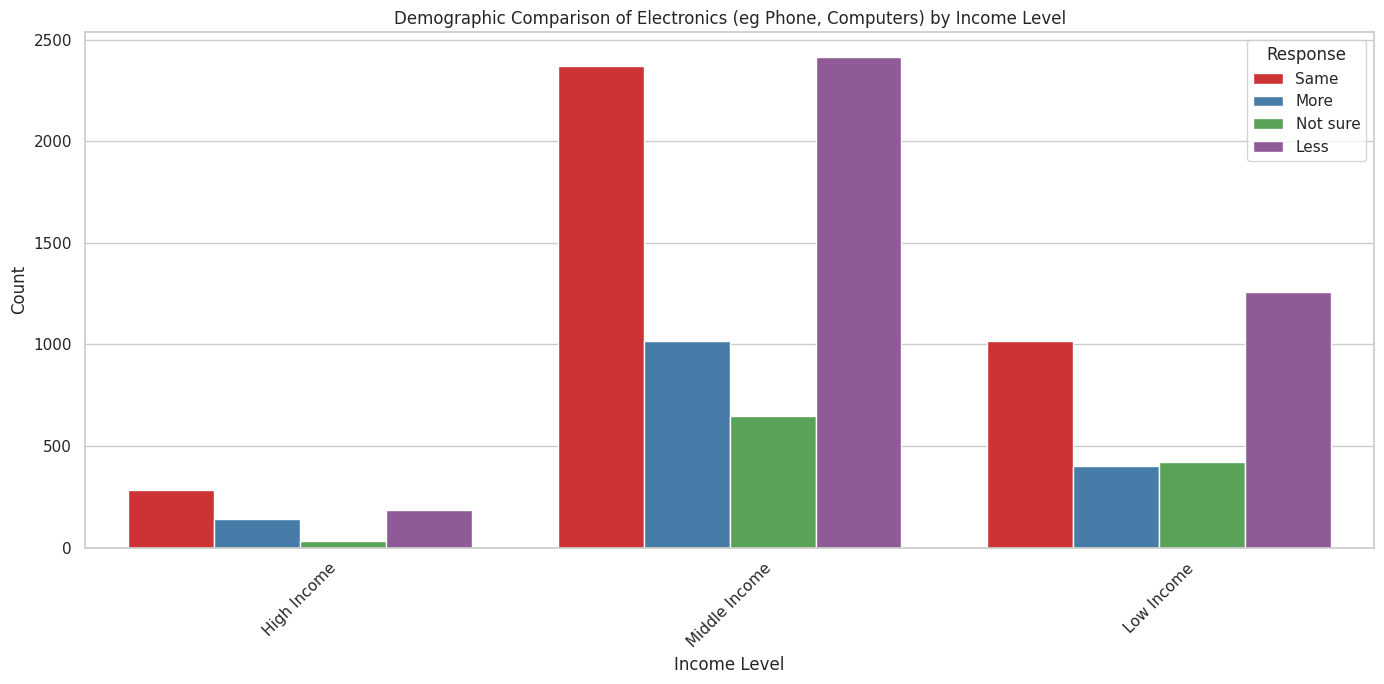

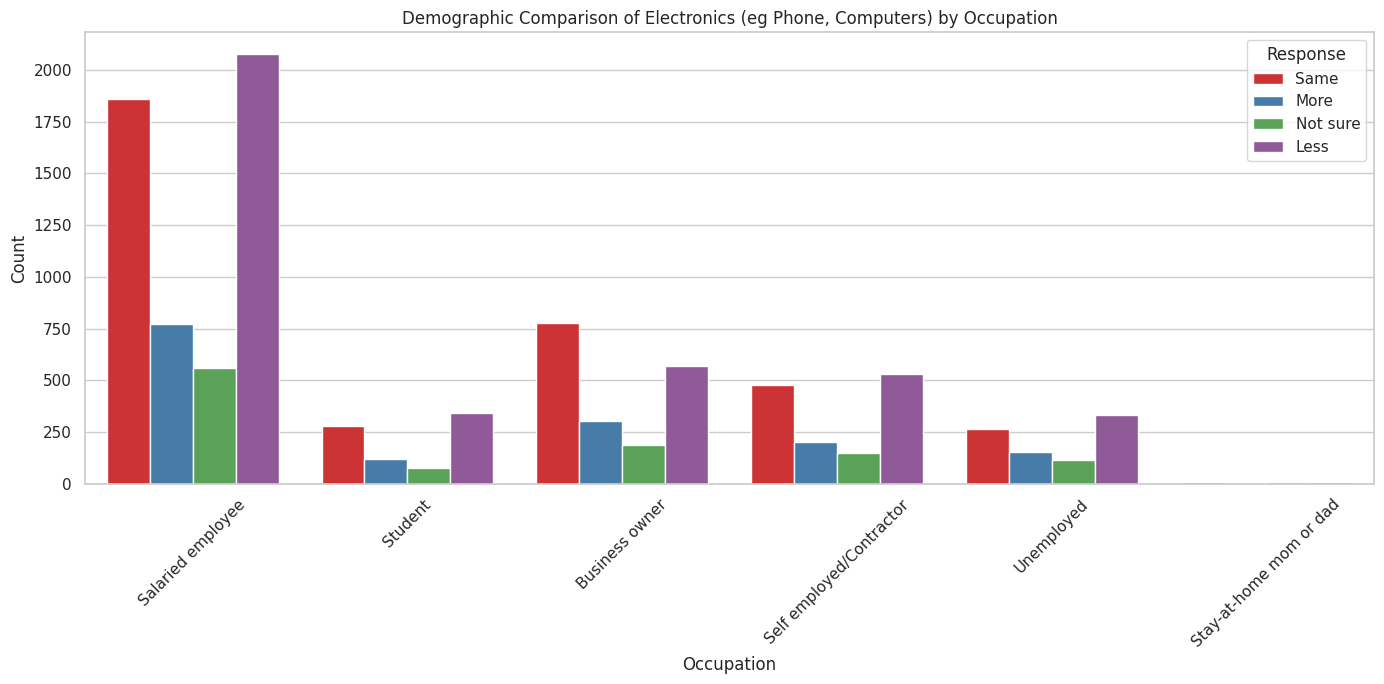

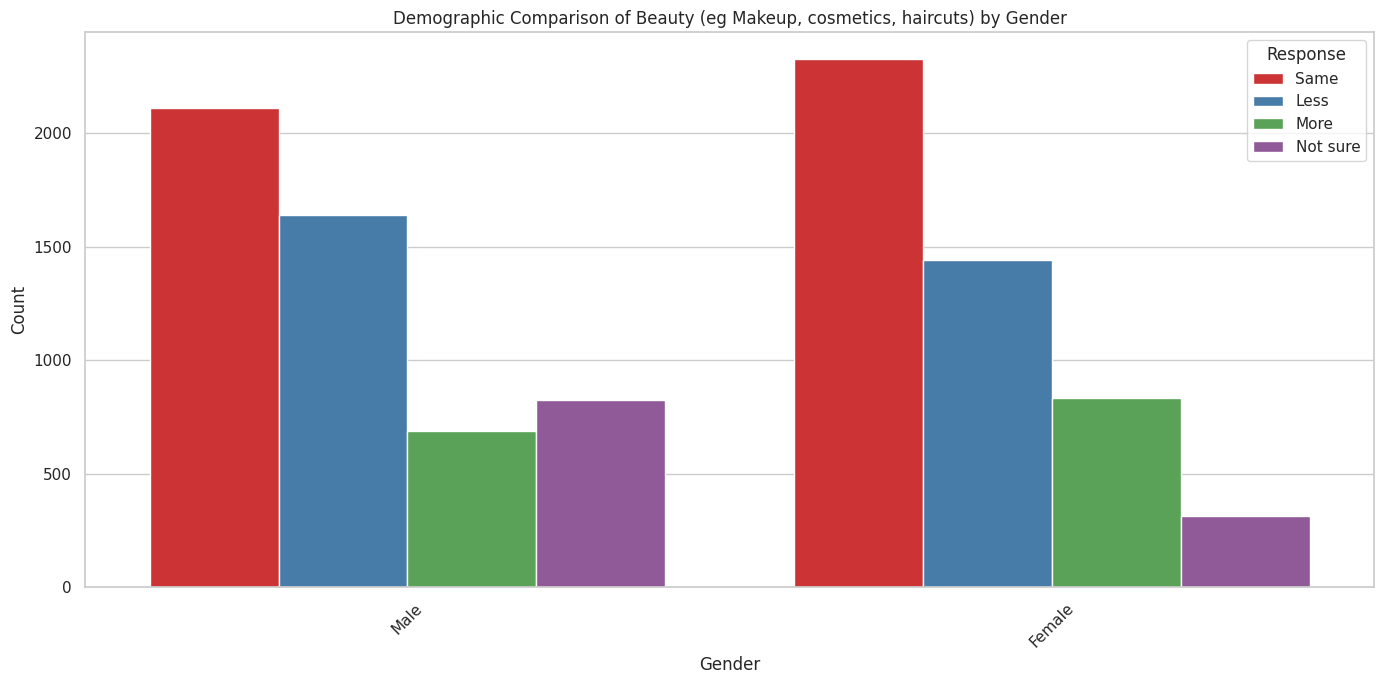

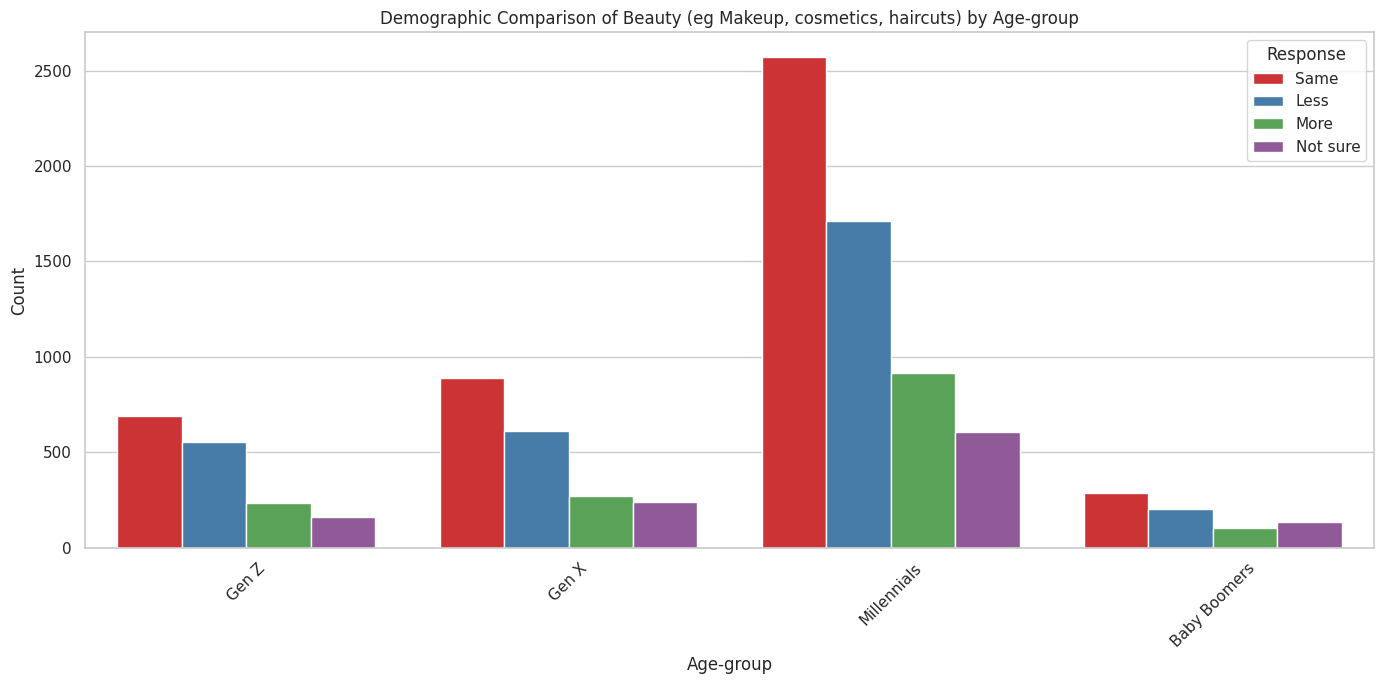

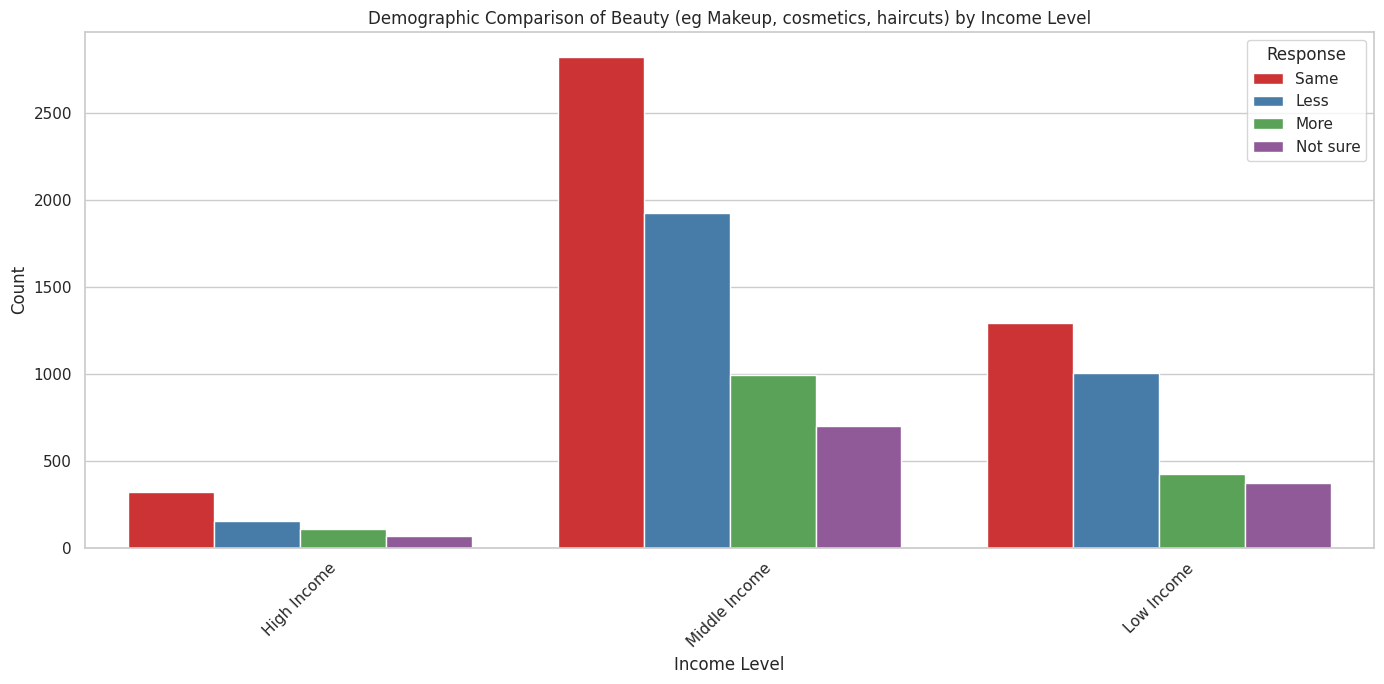

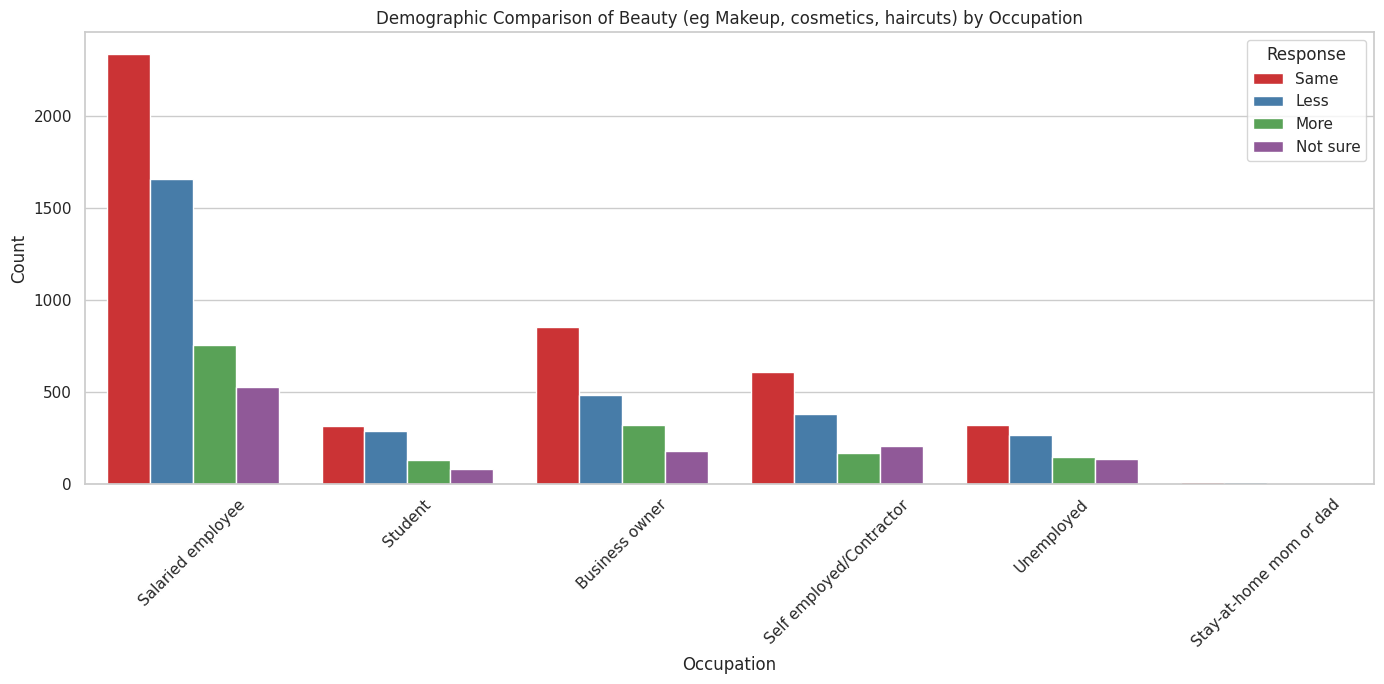

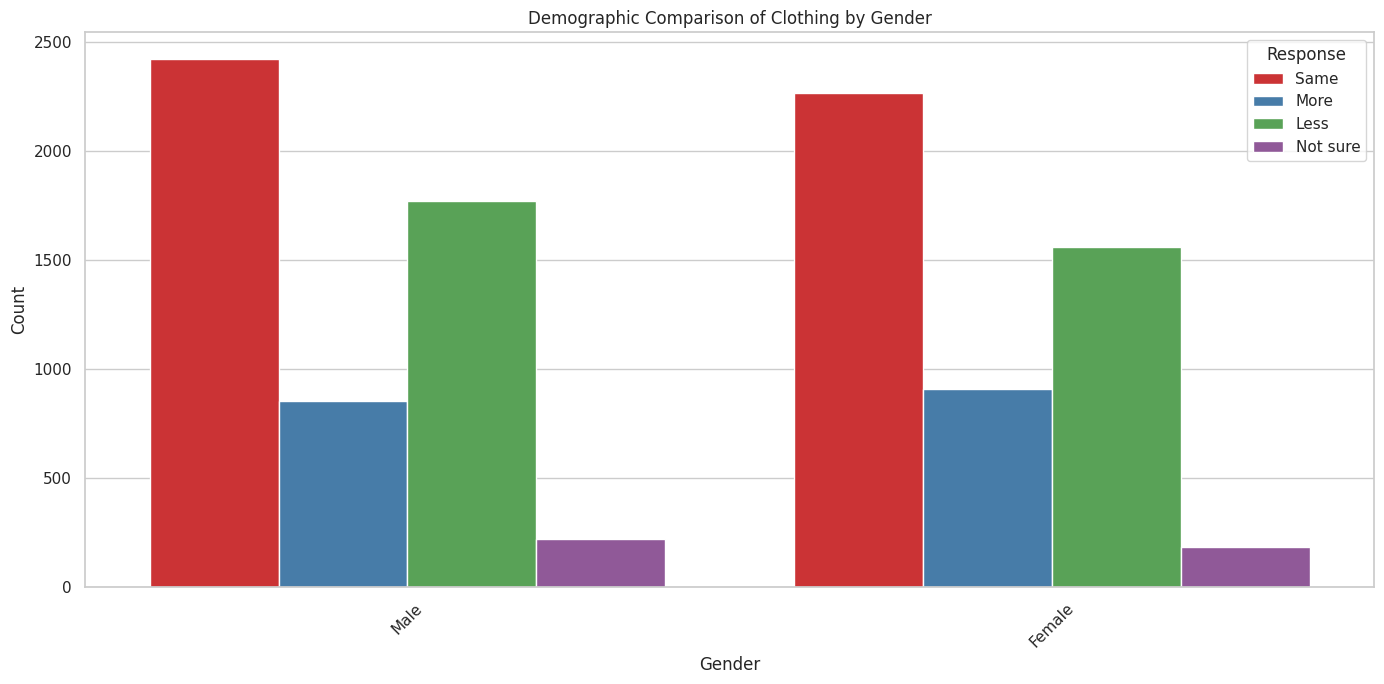

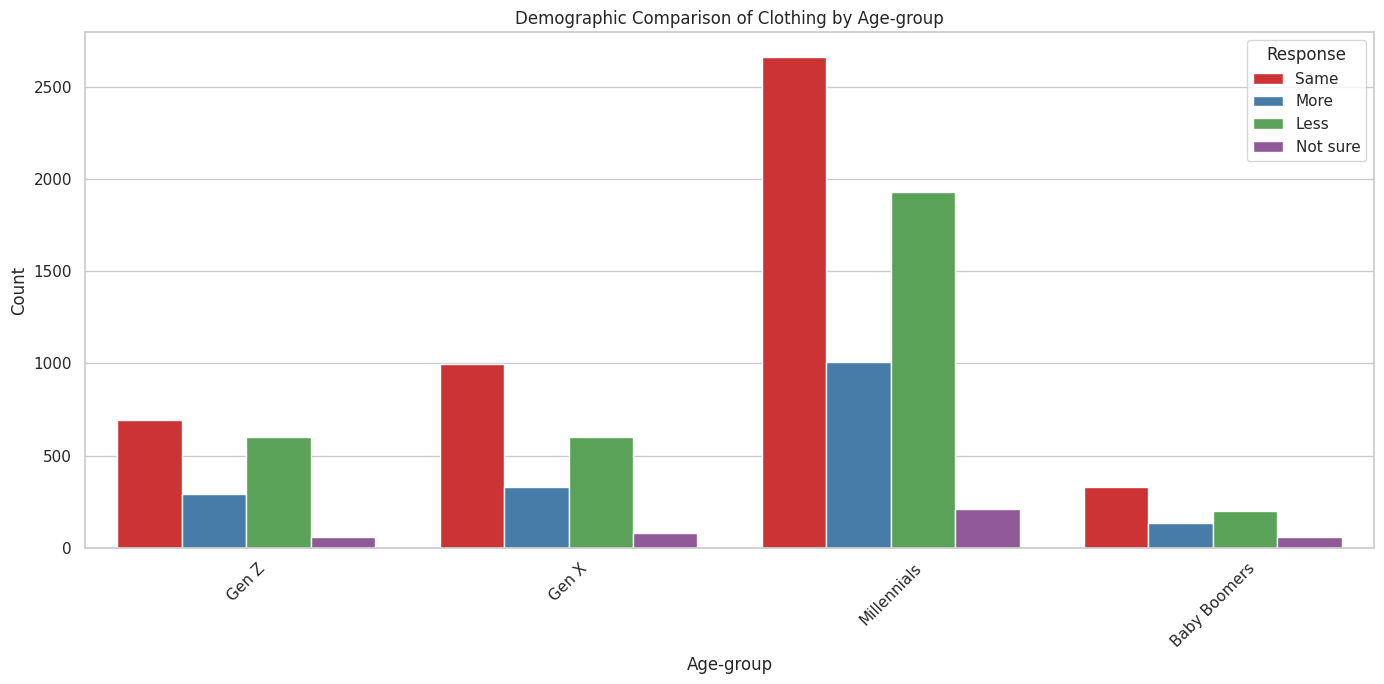

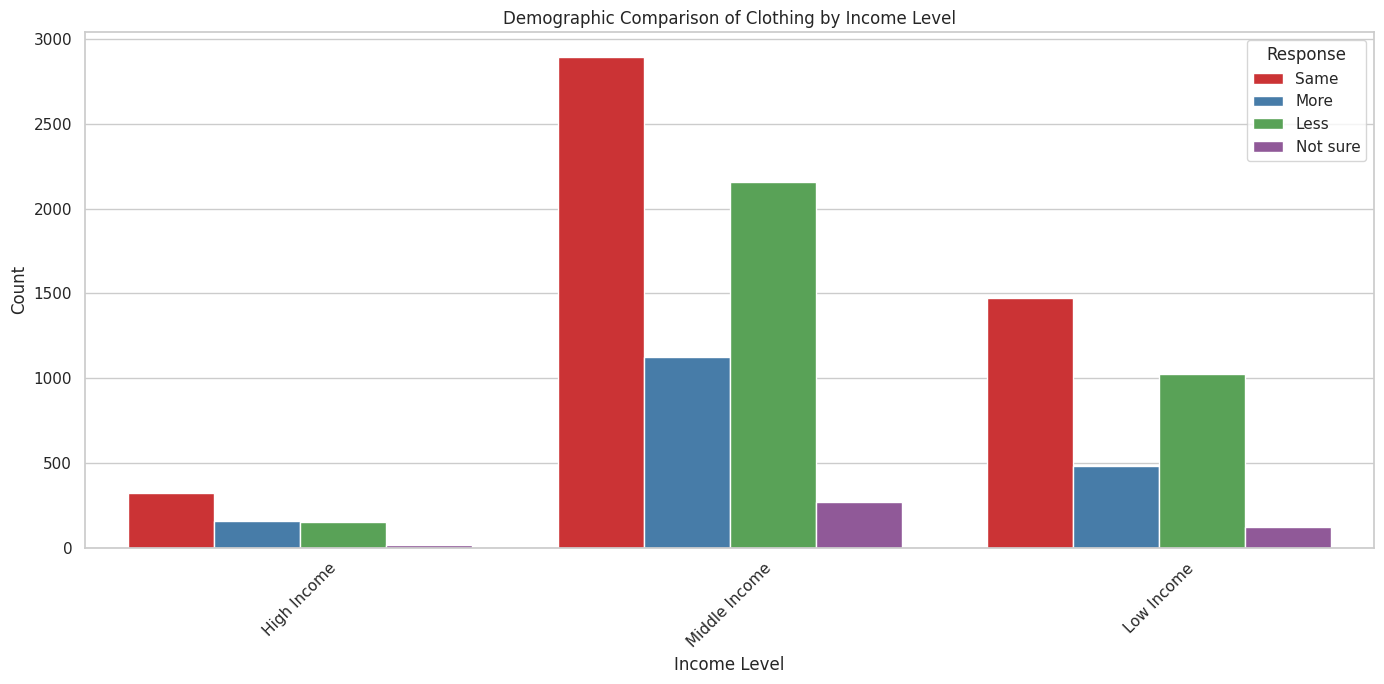

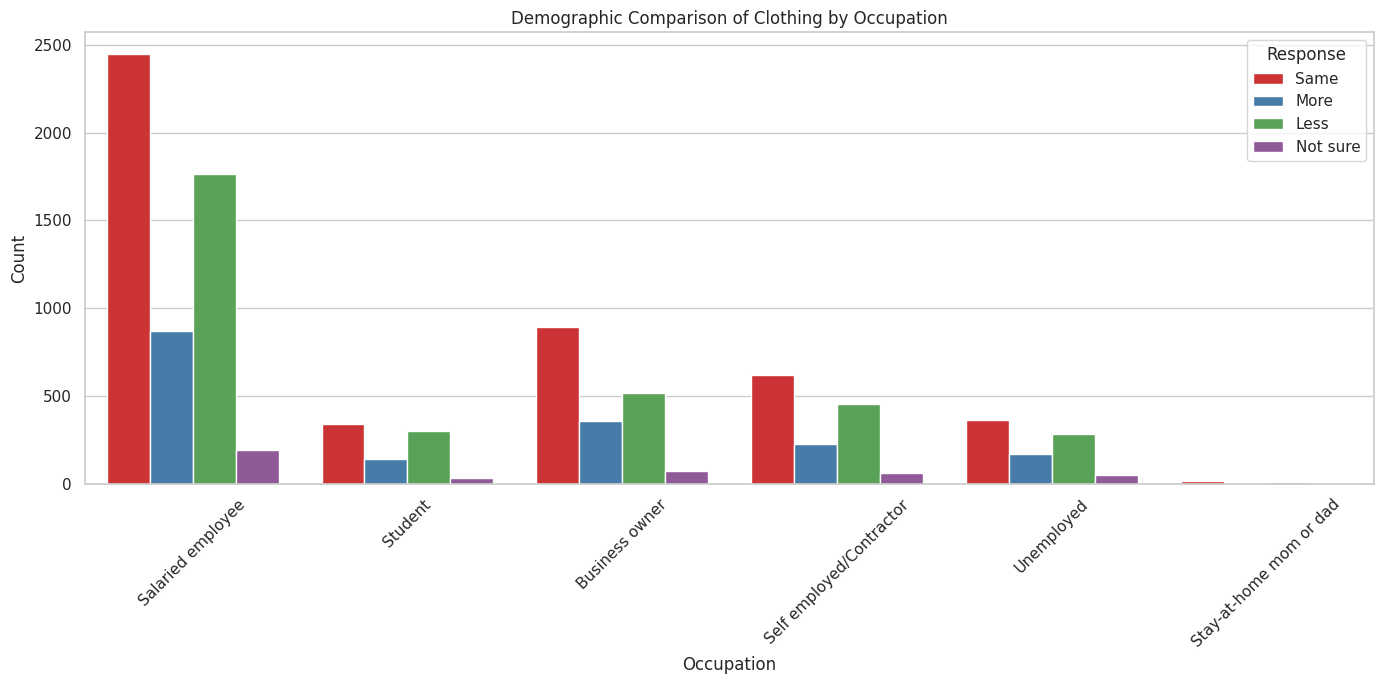

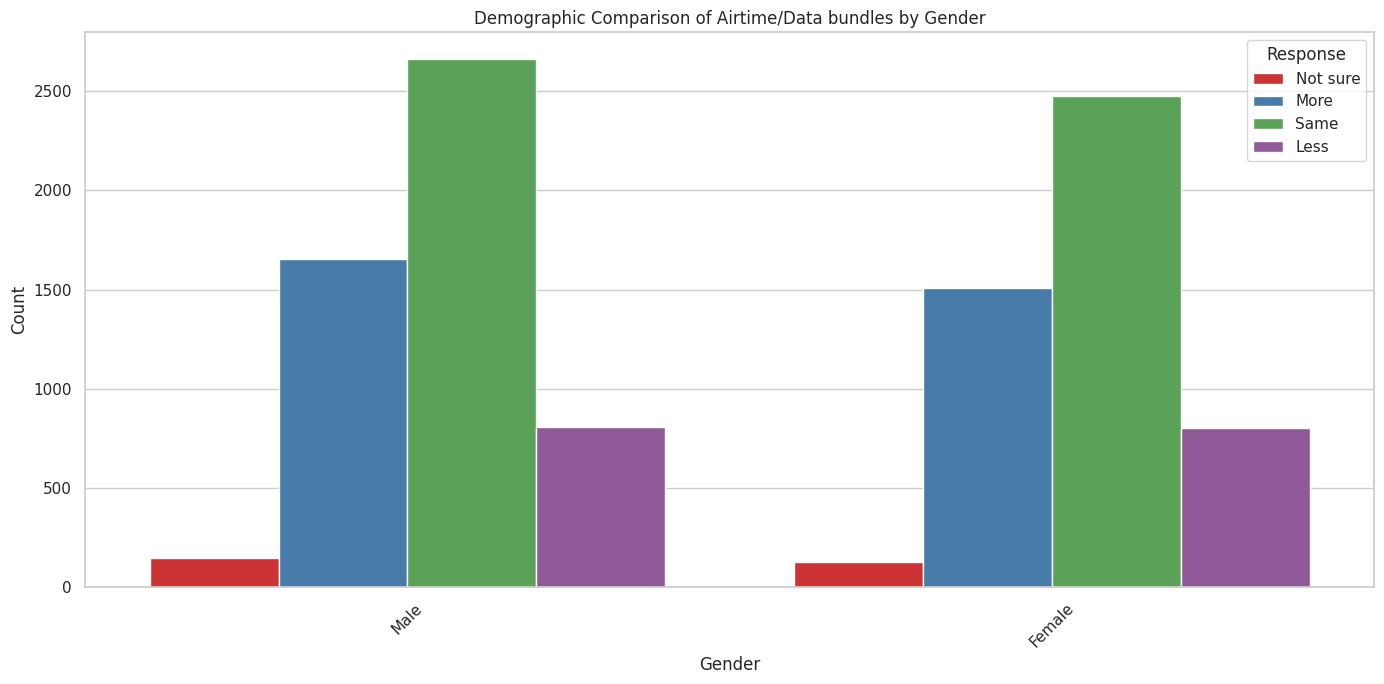

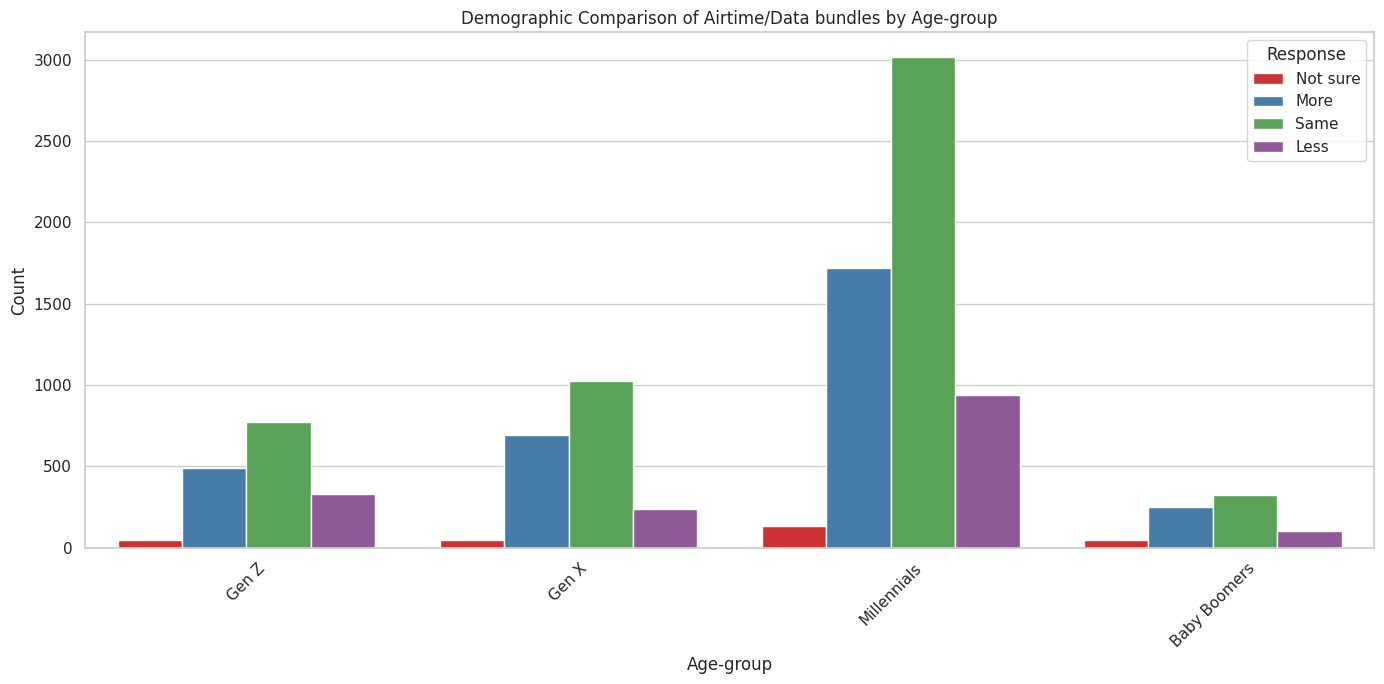

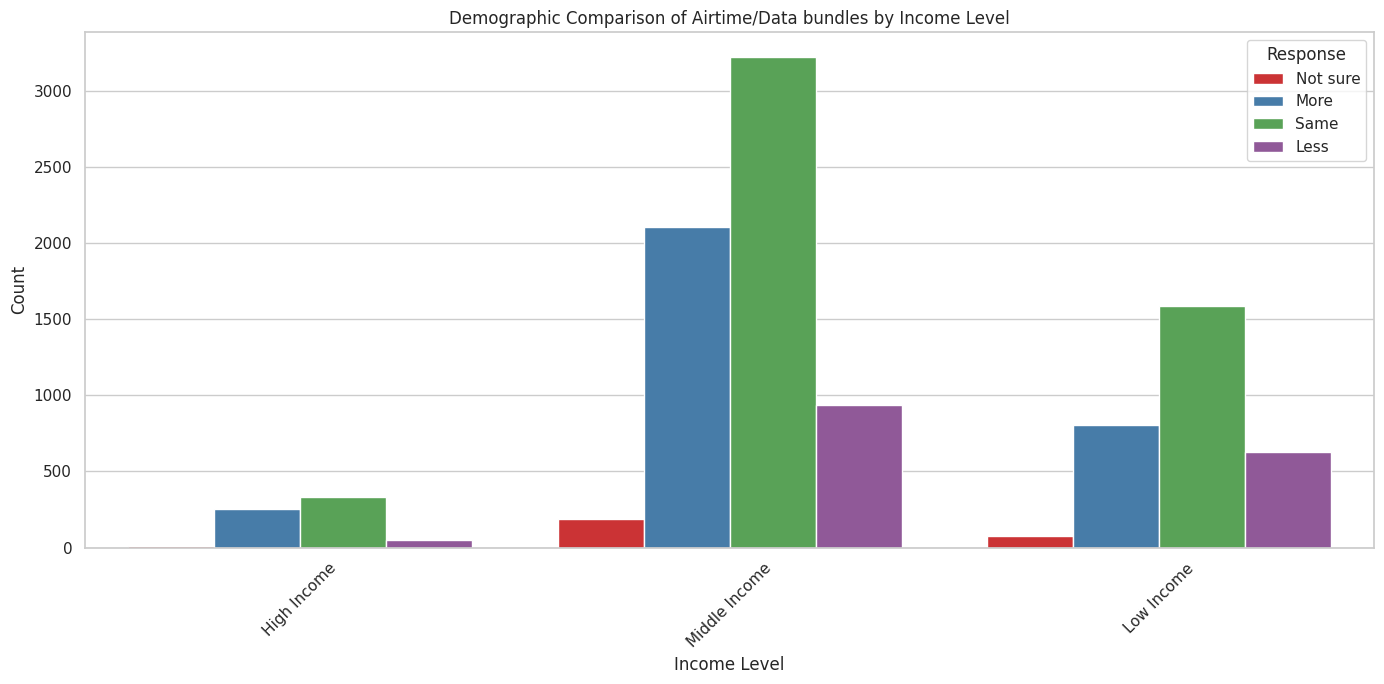

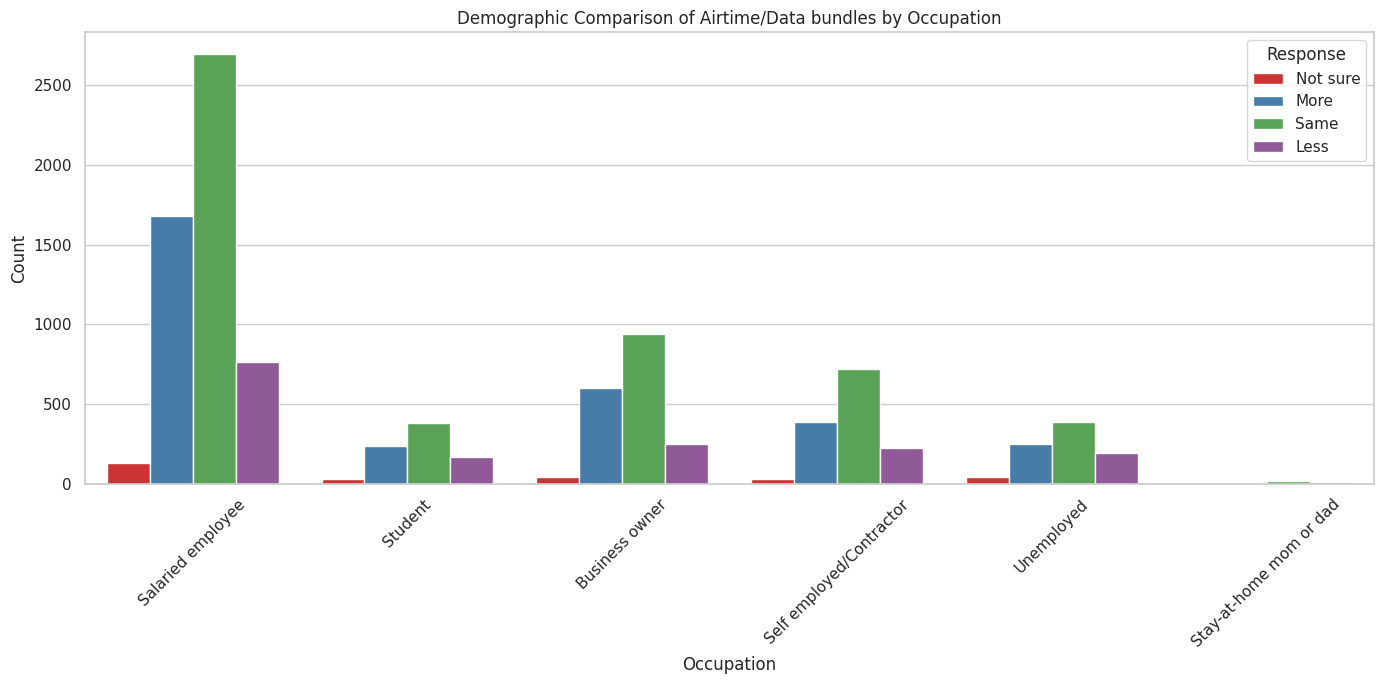

In [ ]:
# Define the demographic variables to analyze
demographic_vars = ['Gender', 'Age-group', 'Income Level', 'Occupation']

# Define all product categories for analysis
product_categories = [
    'Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
    'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
    'Medicines/Natural remedies', 'Alcohol beverages',
    'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
    'Entertainment (eg. Restaurants, movies)', 'Electronics (eg Phone, Computers)',
    'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
    'Airtime/Data bundles'
]

# Loop through each product category and demographic variable to create plots
for category in product_categories:
    for dem_var in demographic_vars:
        plt.figure(figsize=(14, 7))
        sns.countplot(data=data, x=dem_var, hue=category, palette='Set1')
        plt.title(f'Demographic Comparison of {category} by {dem_var}')
        plt.xlabel(dem_var)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.legend(title='Response')
        plt.tight_layout()
        plt.show()


Heatmap for Yearly Response Distribution

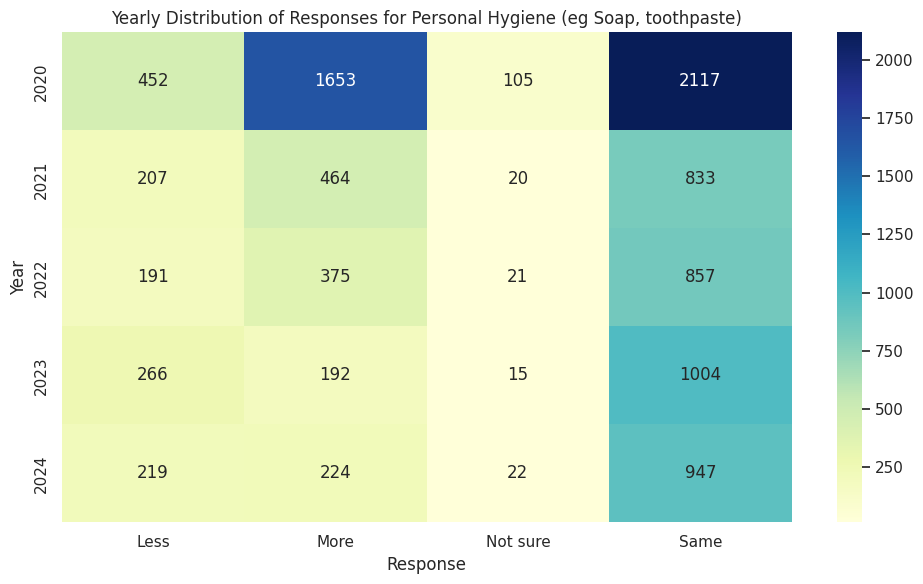

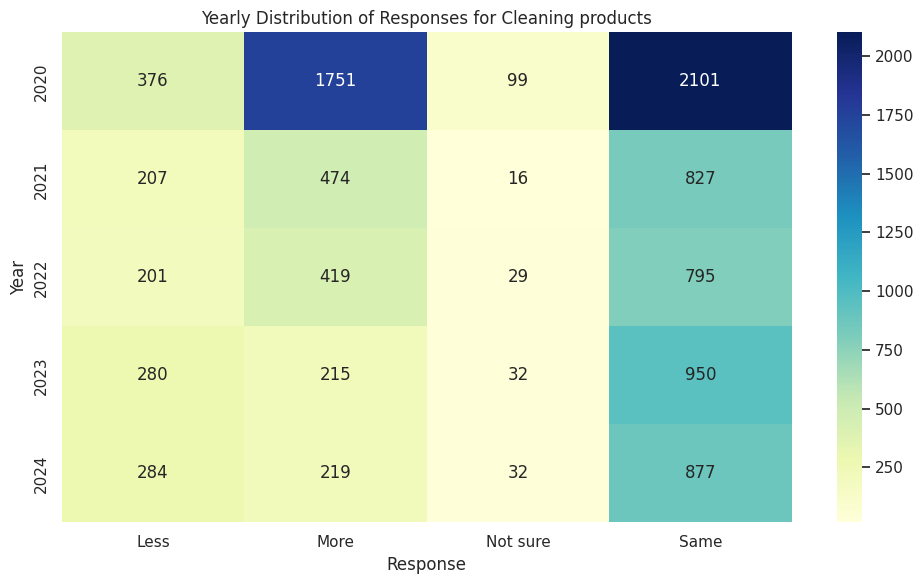

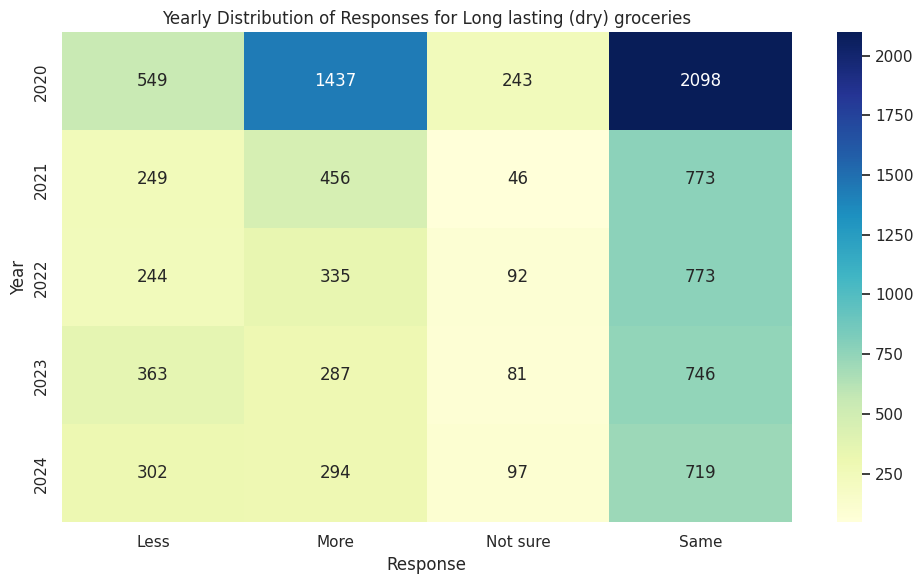

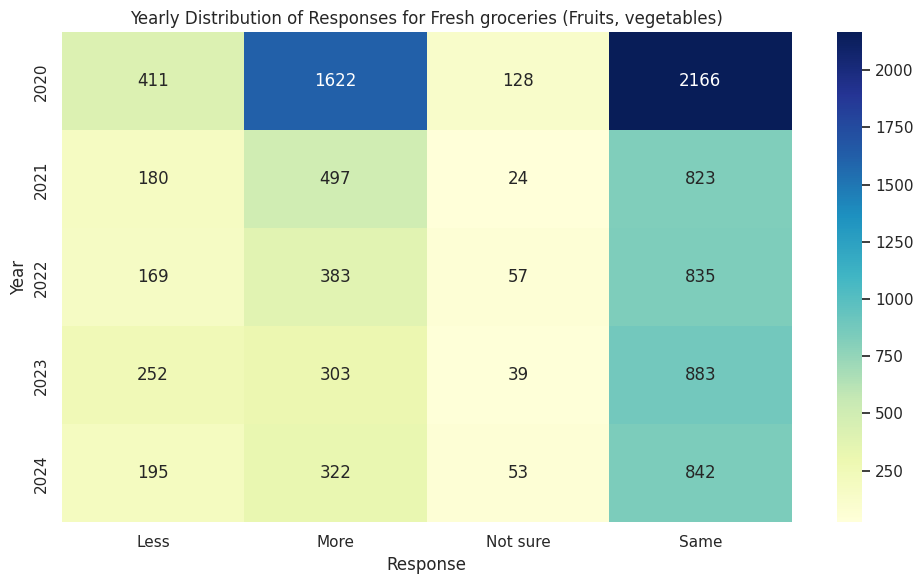

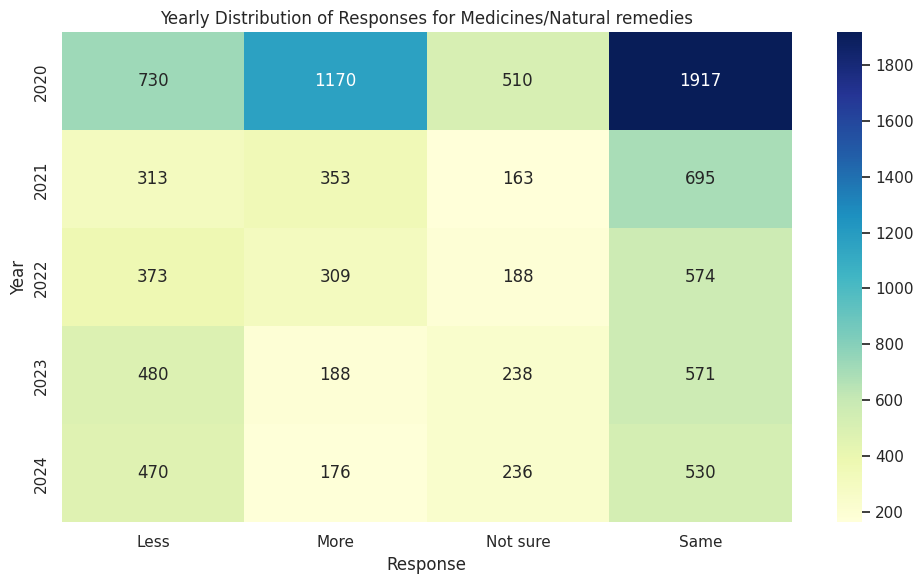

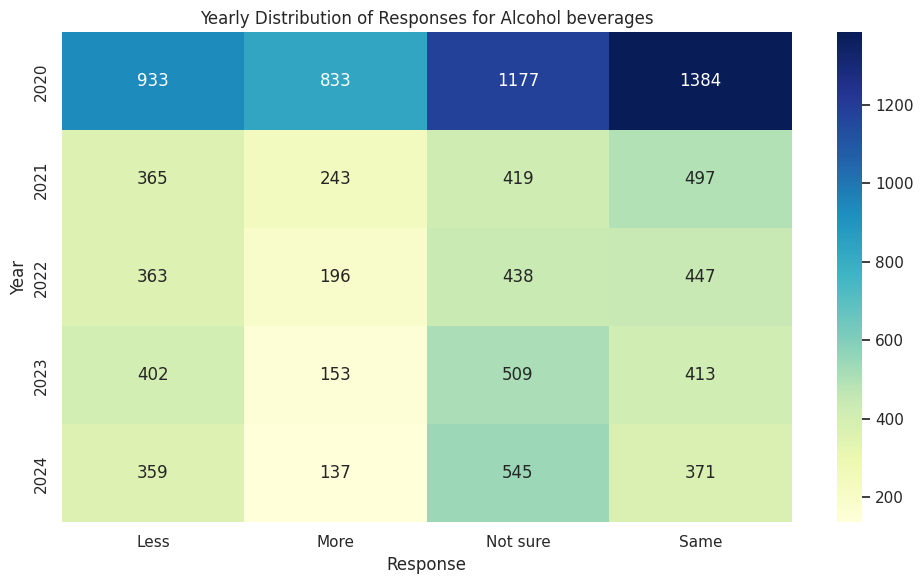

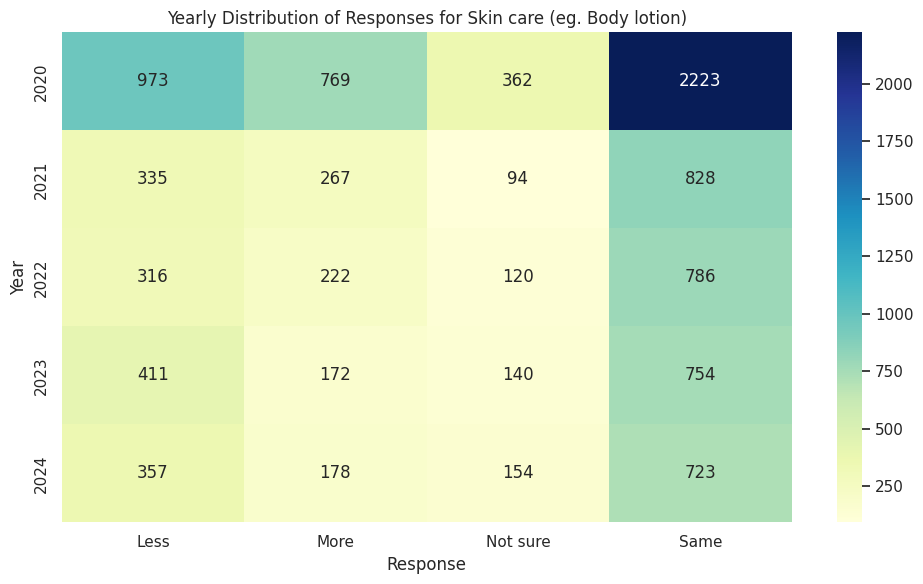

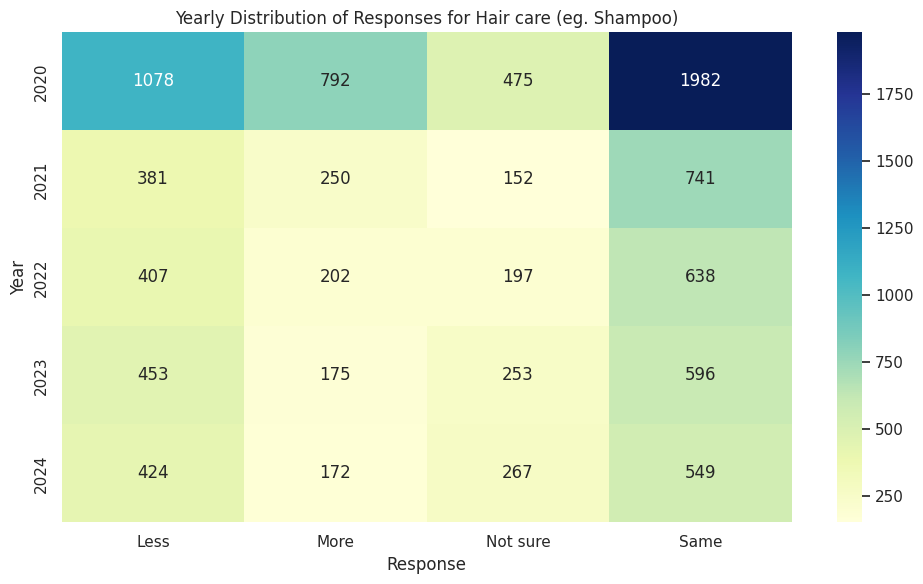

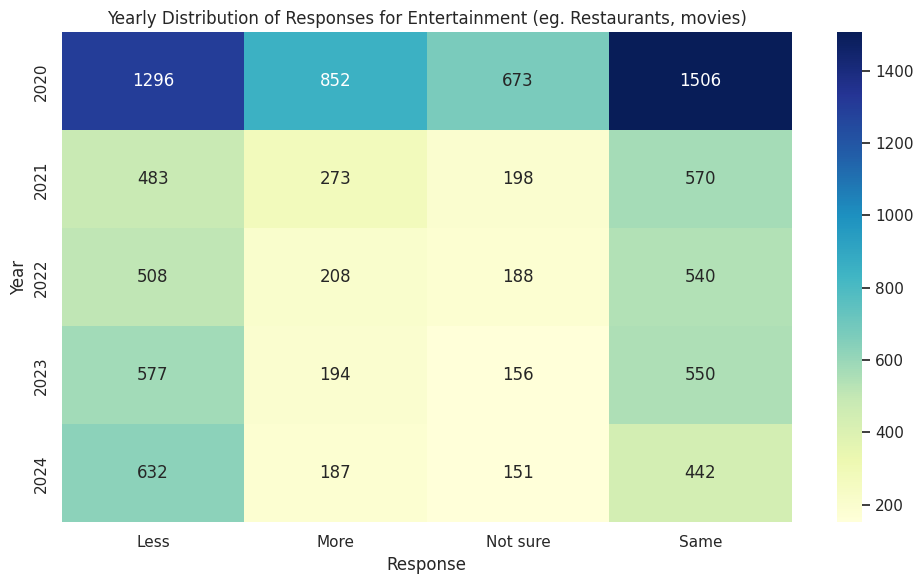

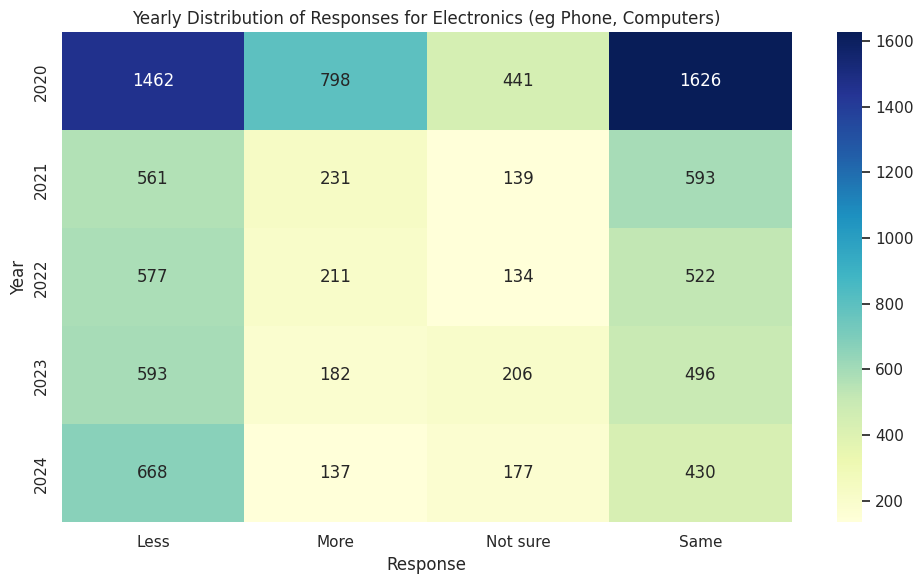

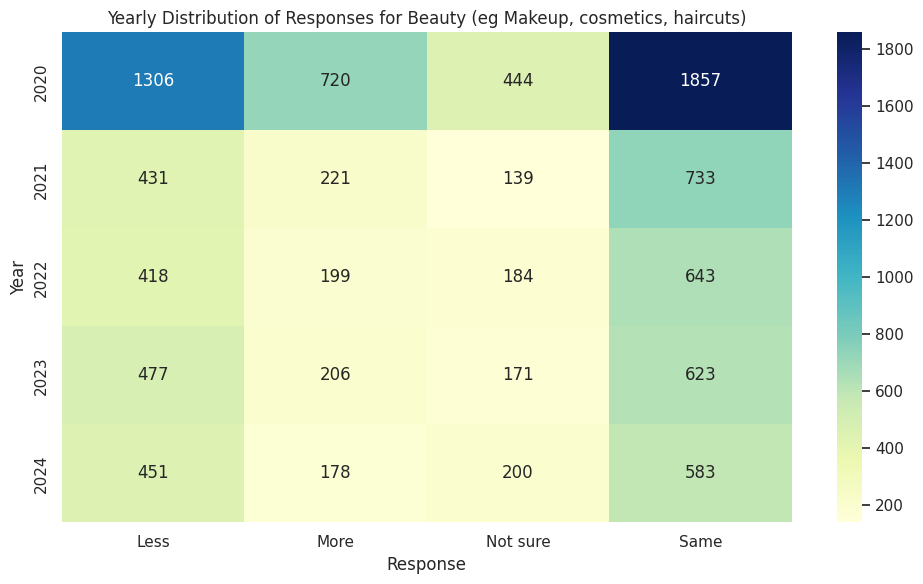

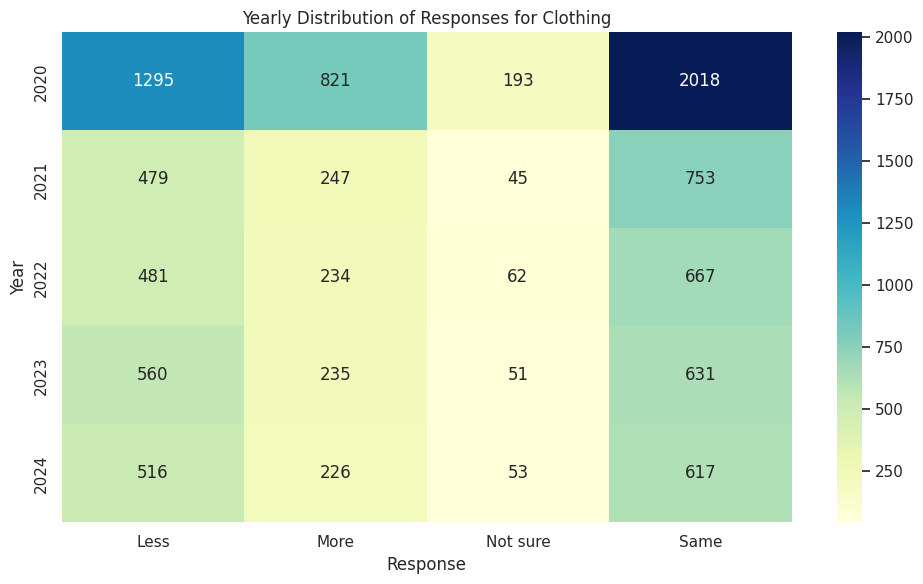

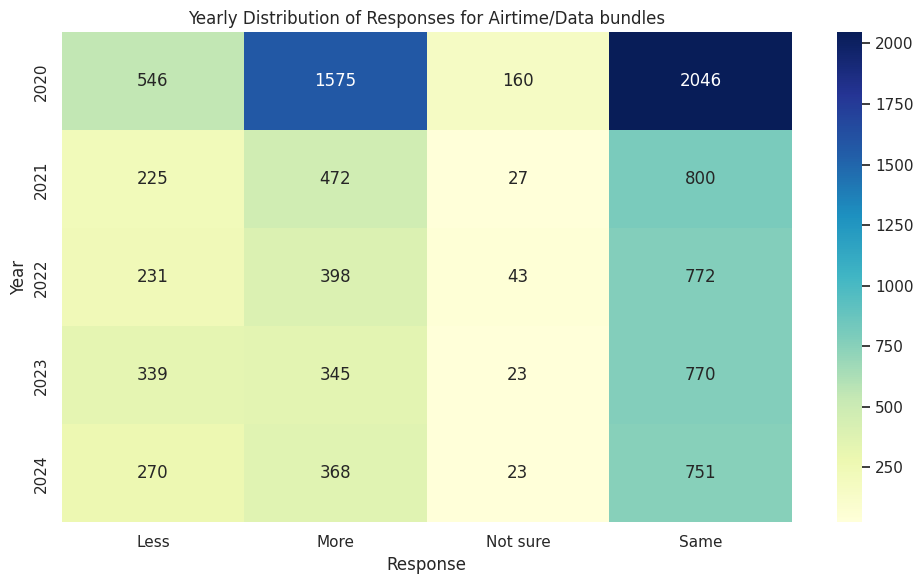

In [ ]:
# Define all product categories for analysis
product_categories = [
    'Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
    'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
    'Medicines/Natural remedies', 'Alcohol beverages',
    'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
    'Entertainment (eg. Restaurants, movies)', 'Electronics (eg Phone, Computers)',
    'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
    'Airtime/Data bundles'
]

# Loop through each product category to create heatmaps
for category in product_categories:
    response_pivot = pd.crosstab(data['Year'], data[category])
    plt.figure(figsize=(10, 6))
    sns.heatmap(response_pivot, annot=True, cmap='YlGnBu', fmt="d")
    plt.title(f'Yearly Distribution of Responses for {category}')
    plt.xlabel('Response')
    plt.ylabel('Year')
    plt.tight_layout()
    plt.show()


### 2. Distributions:
* Gender Distribution: The count of males and females appears almost balanced, with males slightly outnumbering females.
* Age-group Distribution: Millennials dominate the population significantly compared to Gen X, Gen Z, and Baby Boomers.
* Income Level Distribution: Most individuals fall into the "Middle Income" category, followed by "Low Income," with "High Income" being the smallest group.
* Occupation Distribution: The majority are salaried employees, followed by business owners and self-employed individuals. Students, stay-at-home parents, and unemployed individuals form smaller groups.

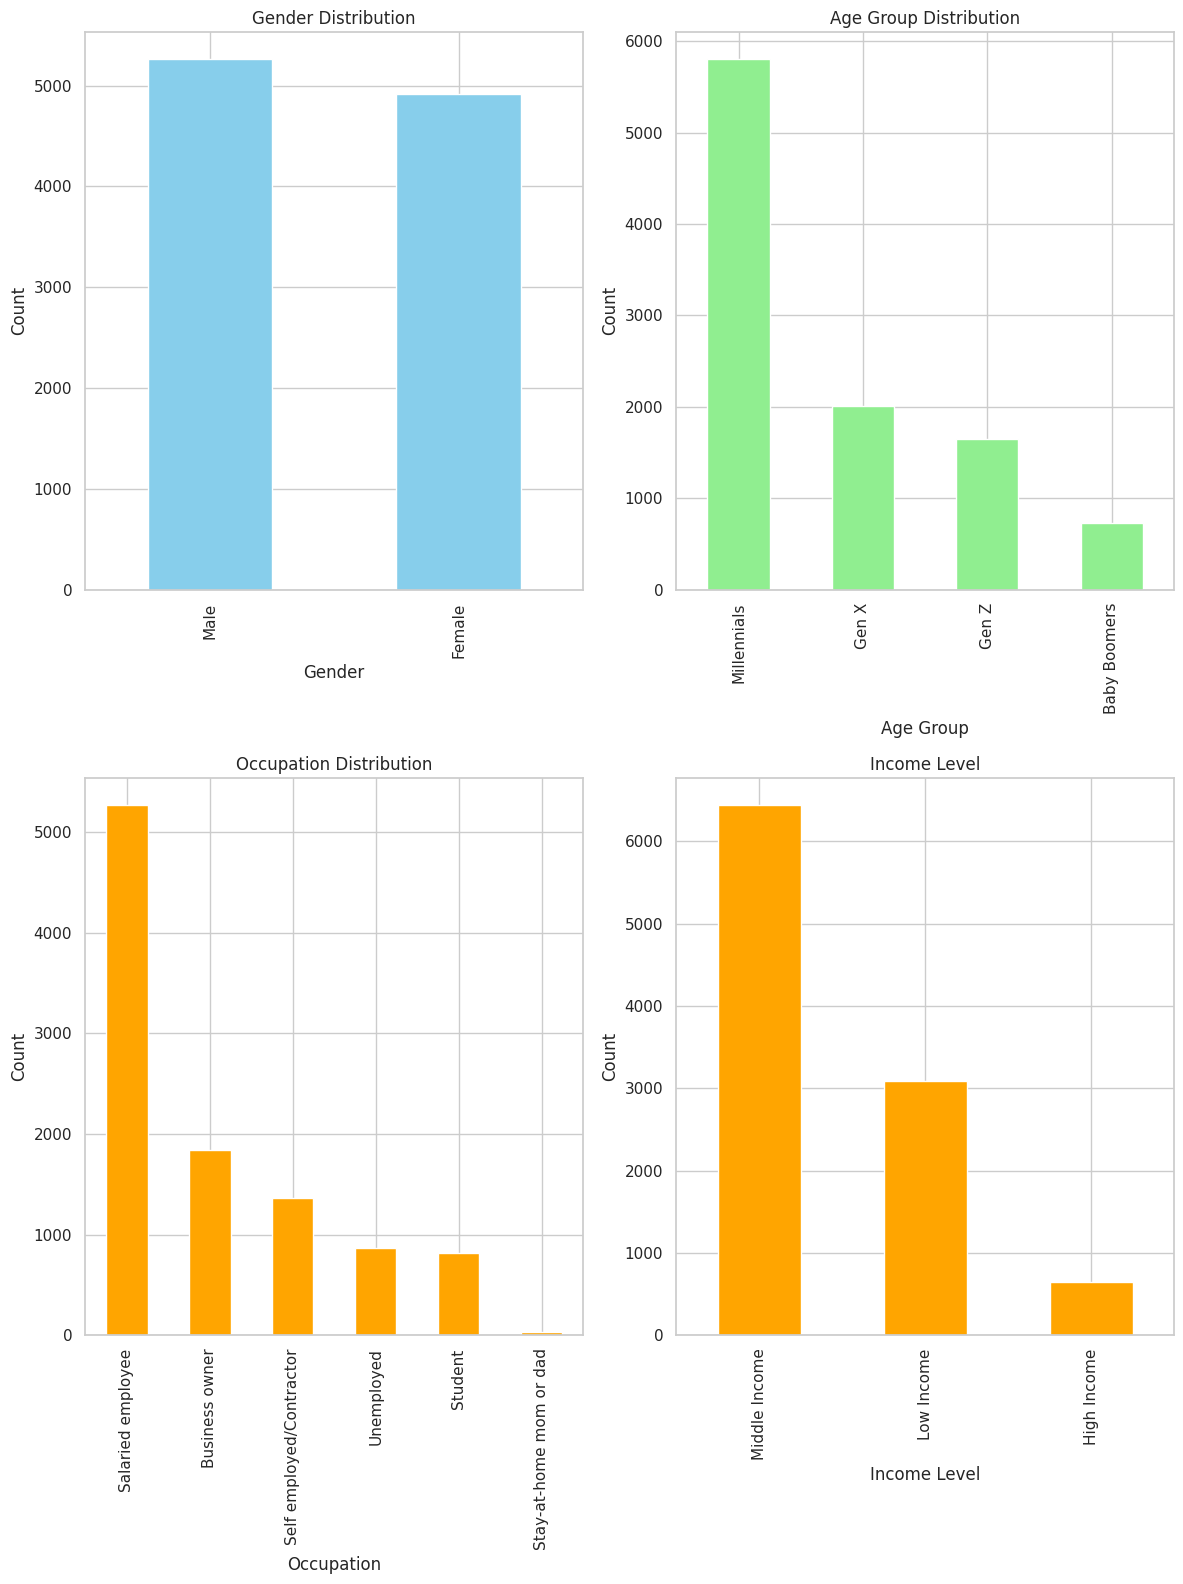

In [ ]:
# Summarizing the columns of interest for EDA: Gender, Income Level, and Occupation
eda_summary = data[['Gender', 'Age-group', 'Occupation', "Income Level"]].describe()

# Visualizing distributions for Gender, Age Group, Income-Level and Occupation
plt.figure(figsize=(12, 16))

# Gender Distribution
plt.subplot(2, 2, 1)
data['Gender'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

# Income Level Distribution
plt.subplot(2, 2, 2)
data['Age-group'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

# Occupation Distribution
plt.subplot(2, 2, 3)
data['Occupation'].value_counts().plot(kind='bar', color='orange')
plt.title('Occupation Distribution')
plt.xlabel('Occupation')
plt.ylabel('Count')

# Occupation Distribution
plt.subplot(2, 2, 4)
data['Income Level'].value_counts().plot(kind='bar', color='orange')
plt.title('Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Extract year and month from the Period column.

## Feature encoding and Correlation Heatmap:
Encoded features (Gender, Income Level, Occupation) have minimal direct correlation, which is expected as they are categorical.

The heatmap shows relationships between variables:
- Gender and other variables have negligible correlations.
- Income level has a weak negative correlation with occupation and age group.
- Occupation and age group show a slightly stronger negative correlation, indicating potential differences in career stages or occupations tied to age.


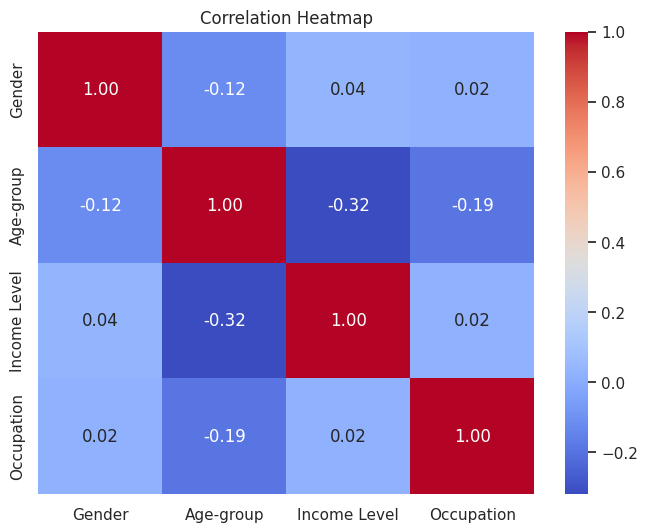

In [ ]:
# Correlation Analysis (encoded numerically for Gender, Income-Level, Occupation)
encoded_data = data[['Gender', 'Age-group', 'Income Level', 'Occupation']].copy()

# Mapping for encoding
gender_map = {'Male': 1, 'Female': 0}
age_group_map = {'Millenials': 3, 'Gen Z': 2, 'Gen X': 1, 'Baby Boomers': 0}
income_map = {'High Income': 2, 'Middle Income': 1, 'Low Income': 0}
occupation_map = {v: i for i, v in enumerate(data['Occupation'].unique())}

encoded_data['Gender'] = encoded_data['Gender'].map(gender_map)
encoded_data['Age-group'] = encoded_data['Age-group'].map(age_group_map)
encoded_data['Income Level'] = encoded_data['Income Level'].map(income_map)
encoded_data['Occupation'] = encoded_data['Occupation'].map(occupation_map)

# Compute correlation
correlation_matrix = encoded_data.corr()

# Plotting correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Statistical Analysis

## Model Development

In [ ]:
encoded_data.head()

,Gender,Age-group,Income Level,Occupation
0,1,2.0,2,0
1,0,1.0,1,0
2,1,NaN,1,0
3,0,2.0,1,0
4,0,NaN,1,0


In [ ]:
encoded_data['Age-group'] = encoded_data['Age-group'].fillna(encoded_data['Age-group'].mean())
encoded_data['Age-group'] = encoded_data['Age-group'].astype(int)
encoded_data.head()

,Gender,Age-group,Income Level,Occupation
0,1,2,2,0
1,0,1,1,0
2,1,1,1,0
3,0,2,1,0
4,0,1,1,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

### Split Data into Train and Test

In [ ]:
# 1. Preprocess the data
# Define the target variables (multi-label targets)
y = encoded_data[['Gender', 'Age-group', 'Occupation', "Income Level"]]

# Define feature variables (exclude target columns and irrelevant ones)
X = data.drop(columns=['Gender', 'Age-group', 'Occupation', 'Income Level', 'Year', 'Month'])

# Encode categorical variables in features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [ ]:
data.to_csv("data.csv")

In [ ]:
encoded_data.to_csv("encoded.csv")

* Targets (y) are:
>>
Gender, Age-group, Income-Level, and Occupation.

* Features (X) exclude targets and irrelevant columns.

In [ ]:
# 2. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.shape, y.shape)

(10184, 15) (10184, 4)


In [ ]:
y[:5]

,Gender,Age-group,Occupation,Income Level
0,1,2,0,2
1,0,1,0,1
2,1,1,0,1
3,0,2,0,1
4,0,1,0,1


In [ ]:
X_train.to_csv("X_train.csv")

In [ ]:
y_train.to_csv("y_train.csv")

In [ ]:
X_test.to_csv("X_test.csv")

In [ ]:
y_test.to_csv("y_test.csv")

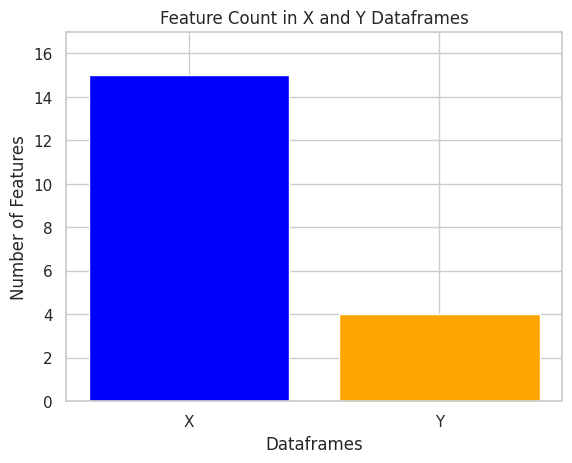

In [ ]:
# Simulate the shapes as given
x_shape = X.shape
y_shape = y.shape

# Create the bar chart
labels = ['X', 'Y']
features = [x_shape[1], y_shape[1]]

plt.bar(labels, features, color=['blue', 'orange'])
plt.xlabel('Dataframes')
plt.ylabel('Number of Features')
plt.title('Feature Count in X and Y Dataframes')
plt.ylim(0, max(features) + 2)

# Display the bar chart
plt.show()

### Model Training:

The MultiOutputClassifier wraps a Random Forest classifier to predict multiple outputs.

- [Source 1](https://scikit-learn.org/1.5/modules/multiclass.html)
- [Source 2](https://www.geeksforgeeks.org/multiclass-vs-multioutput-algorithms-in-machine-learning/)
- [Source 3](https://www.itjfs.com/index.php/ijfs/article/view/1182/432)
- [Source 4](https://www.mdpi.com/2075-1680/11/9/436)
- [Source 5](https://www.sciencedirect.com/science/article/abs/pii/S0020025515006246)

#### Random Forest

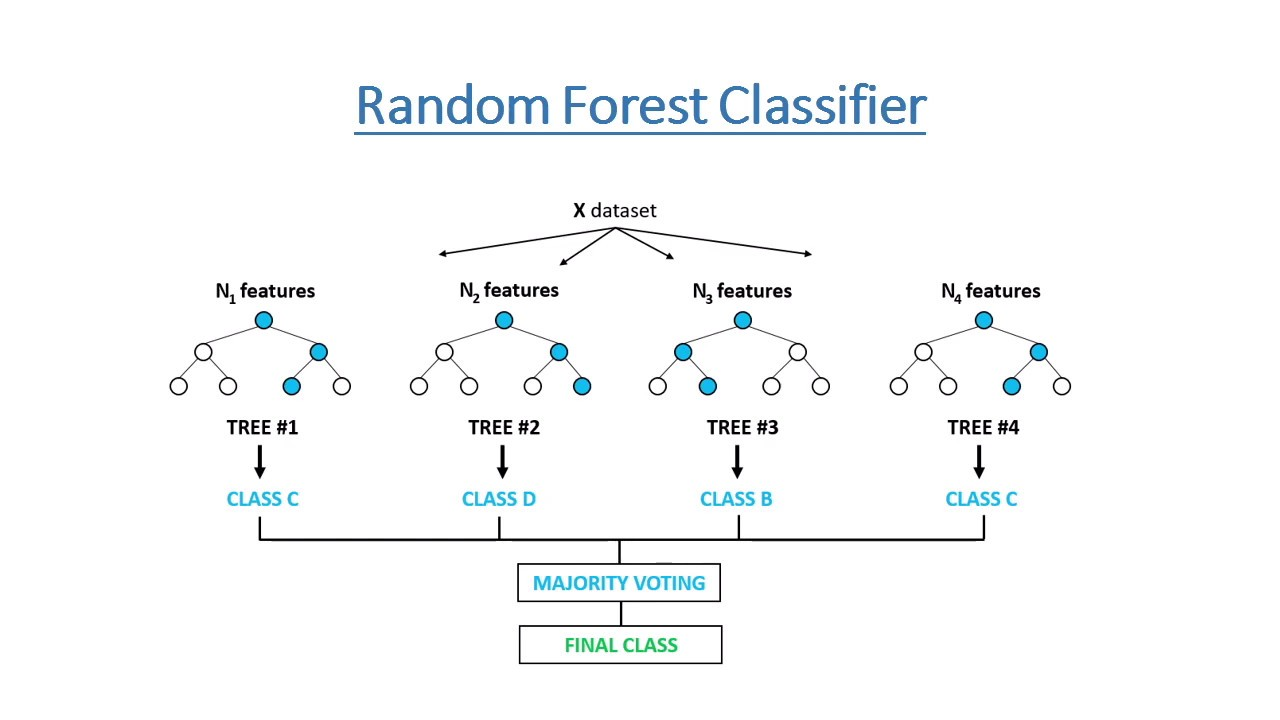

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
# from sklearn.feature_selection import SelectFromModel # REMOVE/COMMENT OUT
from sklearn.metrics import classification_report
import joblib
import os

# Age group mapping
unique_age_groups = data['Age-group'].unique()
print("\nUnique Age Groups:", unique_age_groups)
age_group_map = {'Millennials': 3, 'Gen Z': 2, 'Gen X': 1, 'Baby Boomers': 0}
missing_age_groups = [ag for ag in unique_age_groups if ag not in age_group_map and pd.notna(ag)]
if missing_age_groups:
    print(f"Warning: Missing age groups in mapping: {missing_age_groups}.")

gender_map = {'Male': 1, 'Female': 0}
income_map = {'High Income': 2, 'Middle Income': 1, 'Low Income': 0}

# Occupation mapping
data['Occupation'] = data['Occupation'].fillna('Unknown')
unique_occupations = data['Occupation'].unique()
print("\nUnique Occupations:", unique_occupations)
occupation_map = {v: i for i, v in enumerate(unique_occupations)}

# Create encoded target DataFrame
encoded_data = pd.DataFrame()
encoded_data['Gender'] = data['Gender'].map(gender_map)
encoded_data['Age-group'] = data['Age-group'].map(age_group_map)
encoded_data['Income Level'] = data['Income Level'].map(income_map)
encoded_data['Occupation'] = data['Occupation'].map(occupation_map)

y = encoded_data[['Gender', 'Age-group', 'Occupation', "Income Level"]].copy()
y = y.fillna(-1) # Handle potential NaNs

# Define feature variables (ALL original features intended for input)
feature_cols = [
    'Period', 'Location',
    'Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
    'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
    'Medicines/Natural remedies', 'Alcohol beverages',
    'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
    'Entertainment (eg. Restaurants, movies)', 'Electronics (eg Phone, Computers)',
    'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
    'Airtime/Data bundles'
]

# Check if all feature columns exist
missing_features = [col for col in feature_cols if col not in data.columns]
if missing_features:
    print(f"Error: Missing feature columns in data.csv: {missing_features}")
    exit()

X = data[feature_cols].copy()

# --- Label Encode Features ---
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = X[col].fillna('Unknown') # Handle NaNs before encoding
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# --- Train/Test Split ---
# Use the full encoded X now
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain/Test Shapes (Using ALL Features):")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# --- Model Training (GridSearchCV) ---
# Use the FULL X_train, X_test now
param_grid = {
    'n_estimators': [100, 150], # Keep reduced grid or expand as needed
    'max_depth': [10, 20],
    'min_samples_split': [5, 10]
}

# Create the base estimator with GridSearchCV
# Using X_train (full features) now
base_estimator = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3, # Use 3 folds for faster example
    scoring='accuracy', # Or another appropriate metric
    n_jobs=-1
)

# Create the MultiOutputClassifier
multi_output = MultiOutputClassifier(base_estimator, n_jobs=-1)

# Fit the model using FULL features
print("\nStarting GridSearchCV and MultiOutputClassifier fitting (ALL Features)...")
multi_output.fit(X_train, y_train) # Fit on X_train (full)
print("Fitting complete.")

# --- Evaluation (Optional but recommended) ---
print("\nEvaluating on test set (ALL Features)...")
y_pred_grid = multi_output.predict(X_test) # Predict on X_test (full)

# Prepare for report
label_names = y_train.columns.tolist()
y_pred_df = pd.DataFrame(y_pred_grid, columns=label_names)

print("\nClassification Report (per target):")
for i, label in enumerate(label_names):
    print(f"--- {label} ---")
    if isinstance(y_test, pd.DataFrame):
        true_labels = y_test[label]
    else: # Assuming numpy array
        true_labels = y_test[:, i]
    pred_labels = y_pred_df[label]
    print(classification_report(true_labels, pred_labels, zero_division=0))
    print("-" * 20)


# --- Save the necessary objects ---
output_dir = "model"
os.makedirs(output_dir, exist_ok=True)

# Save the model trained on ALL features
joblib.dump(multi_output, os.path.join(output_dir, 'multi_output_model_all_features.joblib')) # New name!
joblib.dump(label_encoders, os.path.join(output_dir, 'label_encoders.joblib'))
# joblib.dump(selector, os.path.join(output_dir, 'feature_selector.joblib')) # DO NOT SAVE SELECTOR
# joblib.dump(selected_features.tolist(), os.path.join(output_dir, 'selected_features.joblib')) # DO NOT SAVE SELECTED FEATURES LIST
joblib.dump(occupation_map, os.path.join(output_dir, 'occupation_map.joblib'))

# Define inverse maps for prediction output
inv_gender_map = {v: k for k, v in gender_map.items()}
inv_age_group_map = {v: k for k, v in age_group_map.items()}
inv_income_map = {v: k for k, v in income_map.items()}
inv_occupation_map = {v: k for k, v in occupation_map.items()}

inverse_maps = {
    'Gender': inv_gender_map,
    'Age-group': inv_age_group_map,
    'Income Level': inv_income_map,
    'Occupation': inv_occupation_map
}
joblib.dump(inverse_maps, os.path.join(output_dir, 'inverse_maps.joblib'))
# Save the full list of features used for training
joblib.dump(feature_cols, os.path.join(output_dir, 'feature_cols.joblib')) # Keep this

print(f"\nModel (trained on ALL features), encoders, maps, and feature list saved to '{output_dir}' directory.")
print(f"Model saved as: multi_output_model_all_features.joblib")
print("Feature selector was NOT saved.")


Unique Age Groups: ['Gen Z' 'Gen X' 'Millennials' 'Baby Boomers']

Unique Occupations: ['Salaried employee' 'Student' 'Business owner' 'Self employed/Contractor'
 'Unemployed' 'Stay-at-home mom or dad']

Train/Test Shapes (Using ALL Features):
X_train: (8147, 15) y_train: (8147, 4)
X_test: (2037, 15) y_test: (2037, 4)

Starting GridSearchCV and MultiOutputClassifier fitting (ALL Features)...
Fitting complete.

Evaluating on test set (ALL Features)...

Classification Report (per target):
--- Gender ---
              precision    recall  f1-score   support

           0       0.61      0.54      0.58      1005
           1       0.60      0.67      0.63      1032

    accuracy                           0.61      2037
   macro avg       0.61      0.61      0.60      2037
weighted avg       0.61      0.61      0.60      2037

--------------------
--- Age-group ---
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       150
           1     

In [ ]:
# 3. Initialize and train the model
rfc_base_classifier = RandomForestClassifier(random_state=42)
multi_classifier_rfc = MultiOutputClassifier(rfc_base_classifier)
multi_classifier_rfc.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [ ]:
# 4. Make predictions
y_pred_rfc = multi_classifier_rfc.predict(X_test)
y_pred_rfc[:5]

array([[0, 3, 0, 1],
       [0, 3, 0, 0],
       [1, 3, 0, 0],
       [1, 3, 0, 1],
       [0, 2, 2, 1]])

In [ ]:
data.iloc[:3, 8:]

,"Personal Hygiene (eg Soap, toothpaste)",Cleaning products,Long lasting (dry) groceries,"Fresh groceries (Fruits, vegetables)",Medicines/Natural remedies,Alcohol beverages,Skin care (eg. Body lotion),Hair care (eg. Shampoo),"Entertainment (eg. Restaurants, movies)","Electronics (eg Phone, Computers)","Beauty (eg Makeup, cosmetics, haircuts)",Clothing,Airtime/Data bundles
0,Less,Same,More,Not sure,Same,Same,More,More,More,Same,Same,Same,Not sure
1,Less,Same,More,Not sure,Same,Same,More,Not sure,More,Same,Less,Same,More
2,Less,Same,More,Not sure,Same,Same,More,More,More,Same,More,Same,More


#### KNearestNeighbors
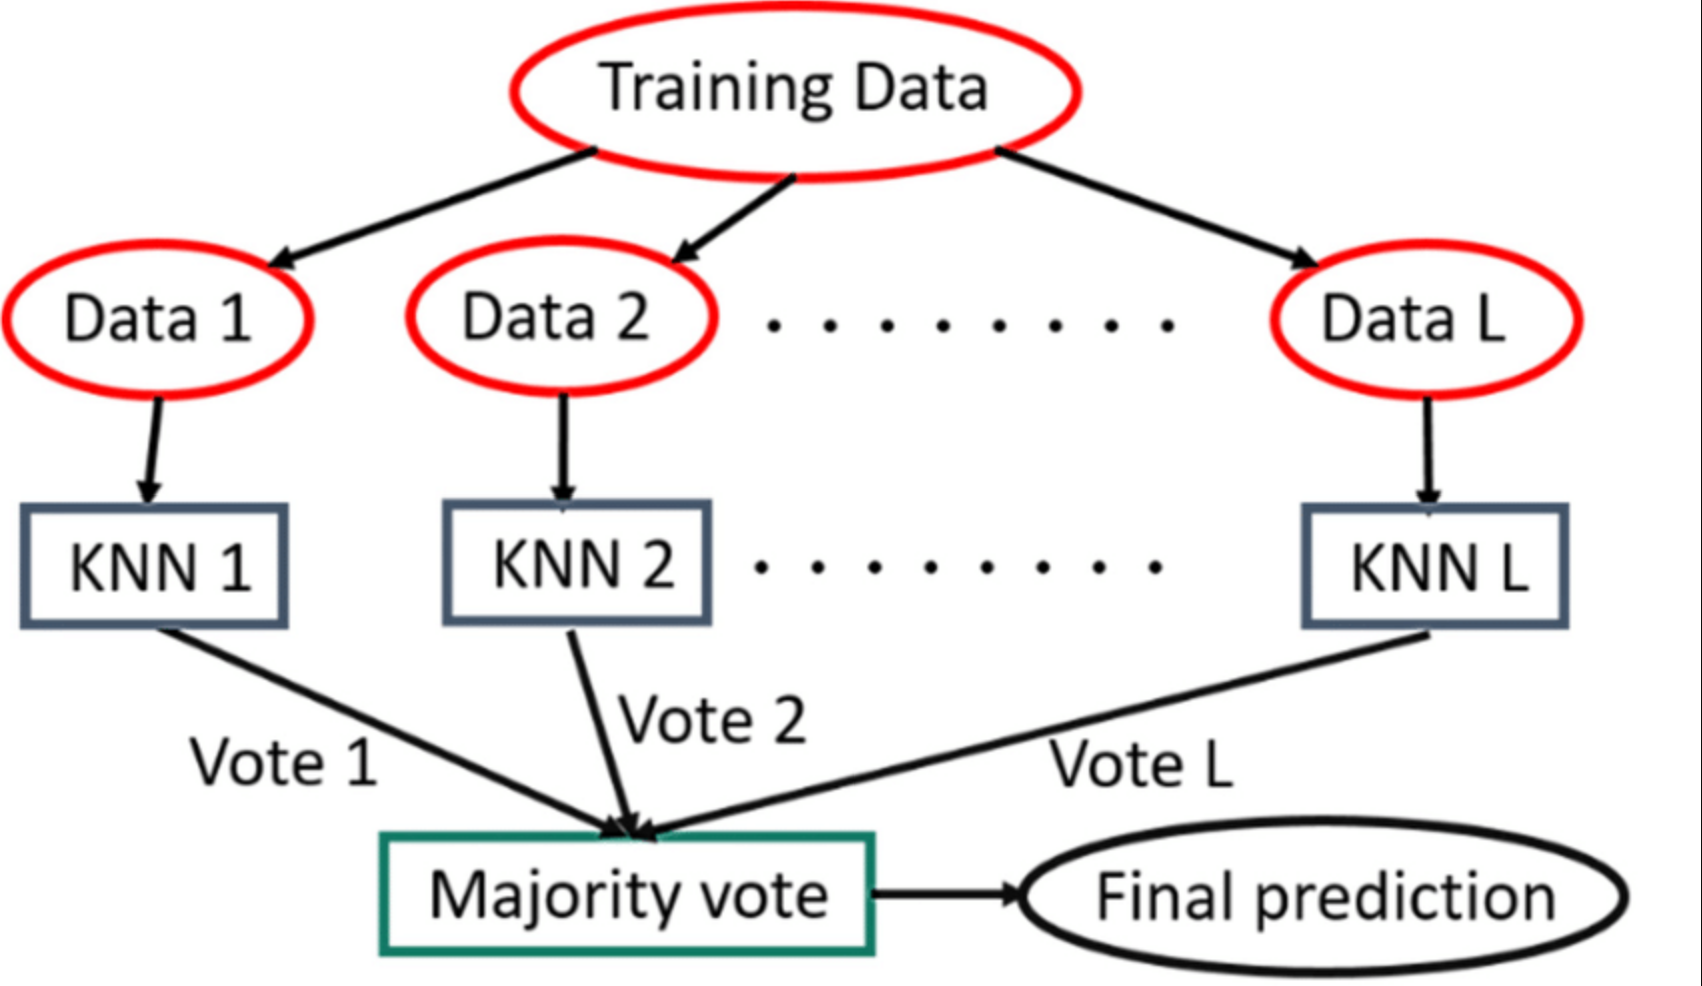

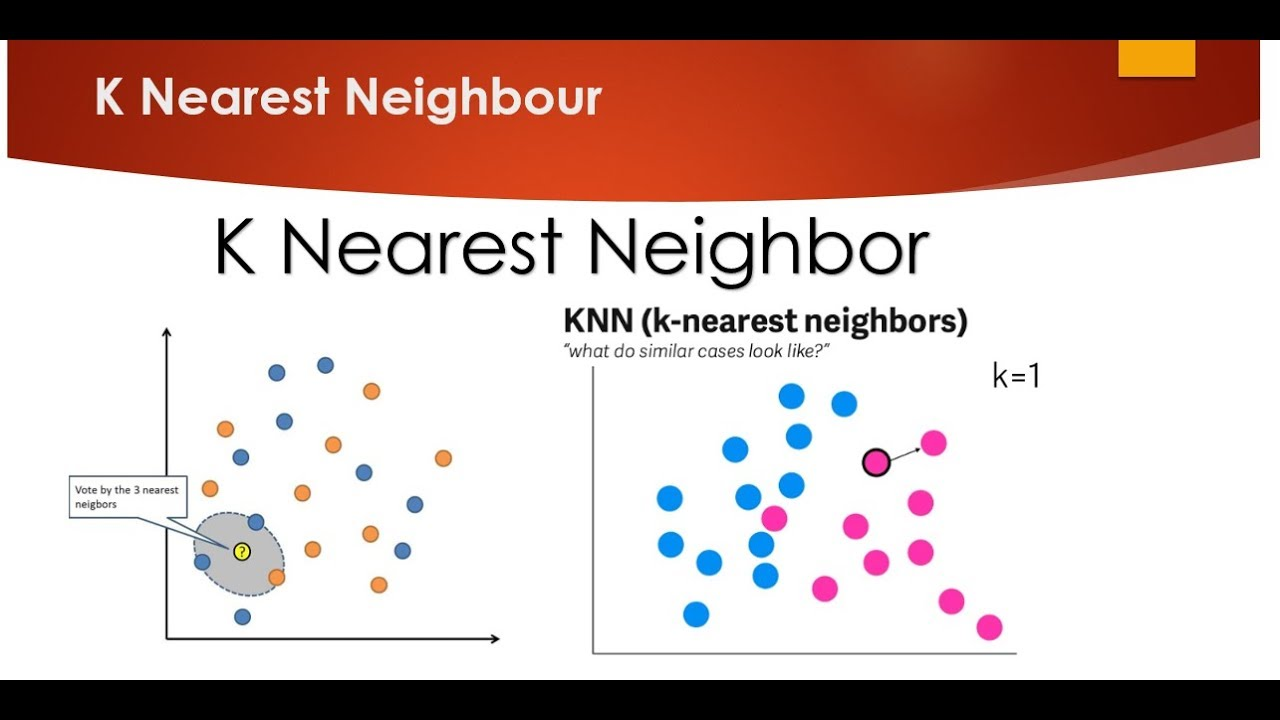

In [ ]:
# 3. Initialize and train the model
knn_base_classifier = KNeighborsClassifier(n_neighbors=3)
multi_classifier_knn = MultiOutputClassifier(knn_base_classifier)
multi_classifier_knn.fit(X_train, y_train)

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=3))

In [ ]:
# 4. Make predictions
y_pred_knn = multi_classifier_knn.predict(X_test)
y_pred_knn[:5]

array([[0, 3, 2, 1],
       [0, 3, 2, 0],
       [1, 0, 0, 0],
       [0, 2, 0, 1],
       [0, 1, 2, 1]])

#### XGBoost
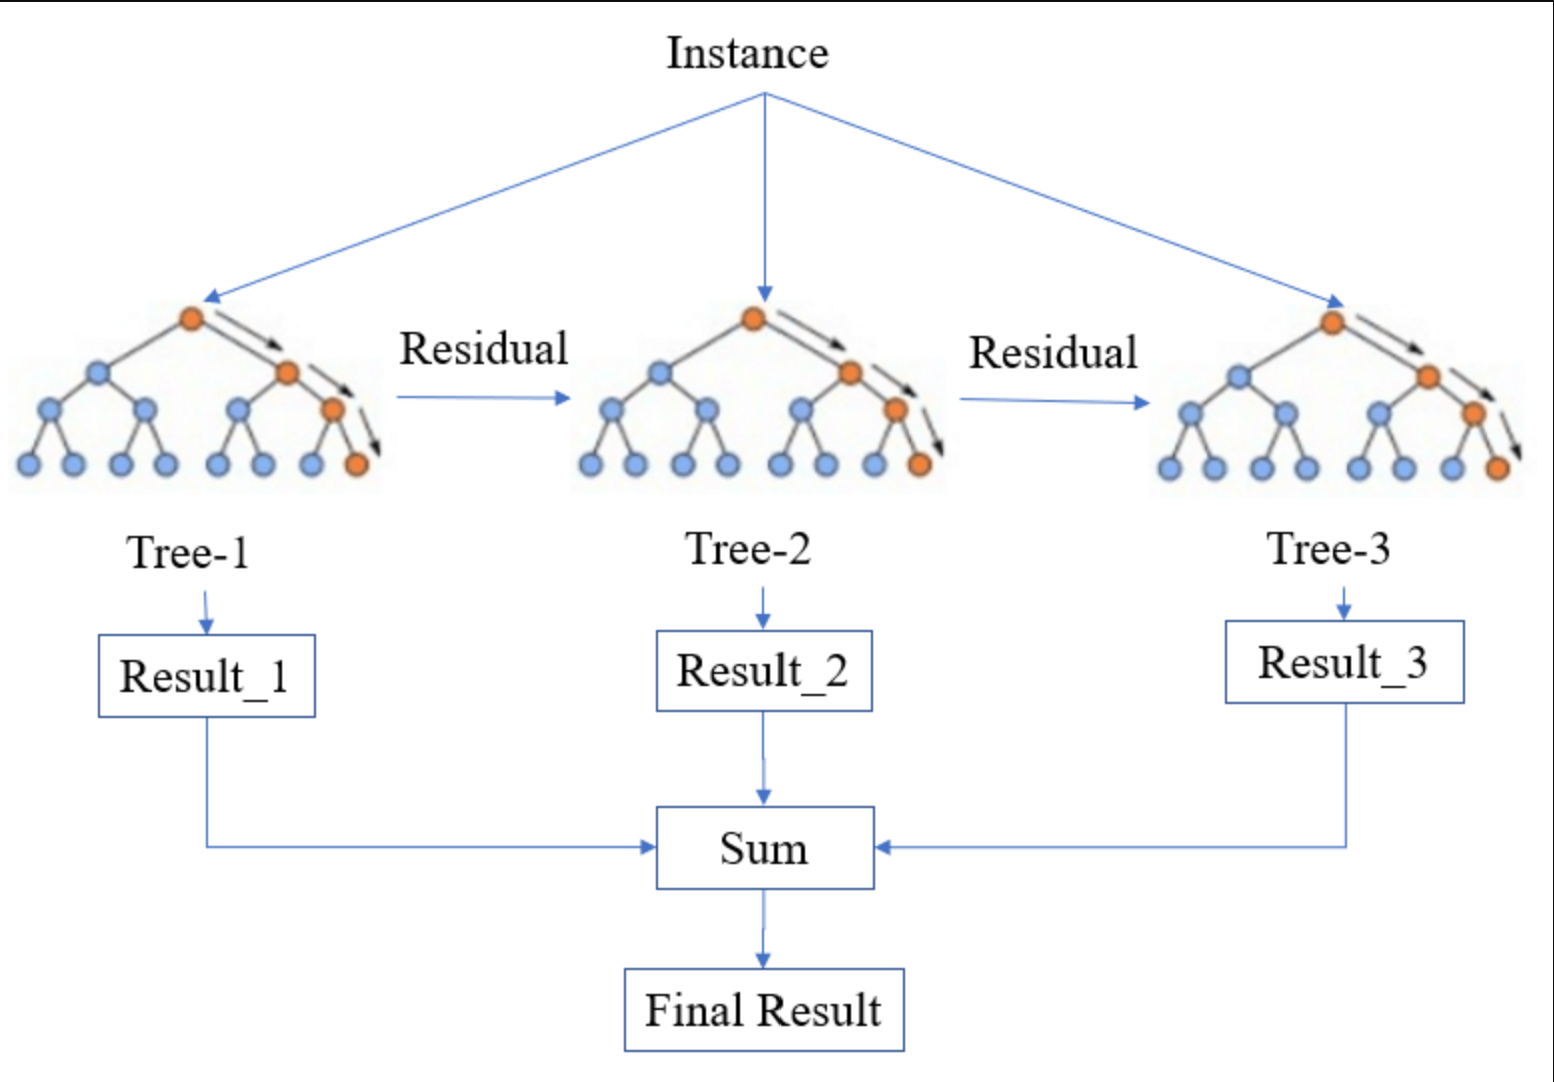

In [ ]:
# 3. Initialize and train the model

# Step 2: Train an XGBoost model
xgb_base_classifier = xgb.XGBClassifier(  # Use XGBRegressor for regression problems
    n_estimators=18,           # Number of trees
    learning_rate=0.0001,          # Step size shrinkage
    max_depth=15,                # Maximum depth of a tree
    random_state=42             # Random seed
)
multi_classifier_xgb = MultiOutputClassifier(xgb_base_classifier)
multi_classifier_xgb.fit(X_train, y_train)

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.0001,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=15,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=18, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))

In [ ]:
# 4. Make predictions
y_pred_xgb = multi_classifier_xgb.predict(X_test)
y_pred_xgb[:5]

array([[1, 3, 0, 0],
       [1, 3, 0, 0],
       [1, 1, 0, 0],
       [1, 2, 2, 1],
       [1, 3, 2, 1]])

## Evaluation:

A classification report is printed for each target. [Source](https://medium.com/@Hassane_01/feature-importance-in-machine-learning-e2d4c41ab998)

### Model Evaluation

#### Random Forest

In [ ]:
# 5. Generate and display classification reports for each target
for i, target in enumerate(y.columns):
    print(f"Classification Report for {target}:\n")
    print(classification_report(y_test.iloc[:, i], y_pred_rfc[:, i]))
    print("\n" + "="*50 + "\n")

Classification Report for Gender:

              precision    recall  f1-score   support

           0       0.59      0.56      0.58      1005
           1       0.59      0.62      0.61      1032

    accuracy                           0.59      2037
   macro avg       0.59      0.59      0.59      2037
weighted avg       0.59      0.59      0.59      2037



Classification Report for Age-group:

              precision    recall  f1-score   support

           0       0.53      0.11      0.18       150
           1       0.31      0.10      0.15       417
           2       0.38      0.16      0.22       327
           3       0.58      0.89      0.70      1143

    accuracy                           0.55      2037
   macro avg       0.45      0.31      0.31      2037
weighted avg       0.49      0.55      0.48      2037



Classification Report for Occupation:

              precision    recall  f1-score   support

           0       0.55      0.87      0.67      1064
           1 

Feature importance for output 1:
Feature: Period, Importance: 0.1864902067088089
Feature: Location, Importance: 0.18508876413530997
Feature: Hair care (eg. Shampoo), Importance: 0.056543172238941945
Feature: Alcohol beverages, Importance: 0.055599355416236944
Feature: Medicines/Natural remedies, Importance: 0.05549622957638479
Feature: Long lasting (dry) groceries, Importance: 0.05383711349409524
Feature: Airtime/Data bundles, Importance: 0.05109950969491016
Feature: Electronics (eg Phone, Computers), Importance: 0.04728991713708735
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.04674483871559027
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.045426051924513426
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.045421118413896254
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.0451201505143441
Feature: Cleaning products, Importance: 0.04389566422858615
Feature: Clothing, Importance: 0.041149624480380016
Feature: Skin care (eg. 

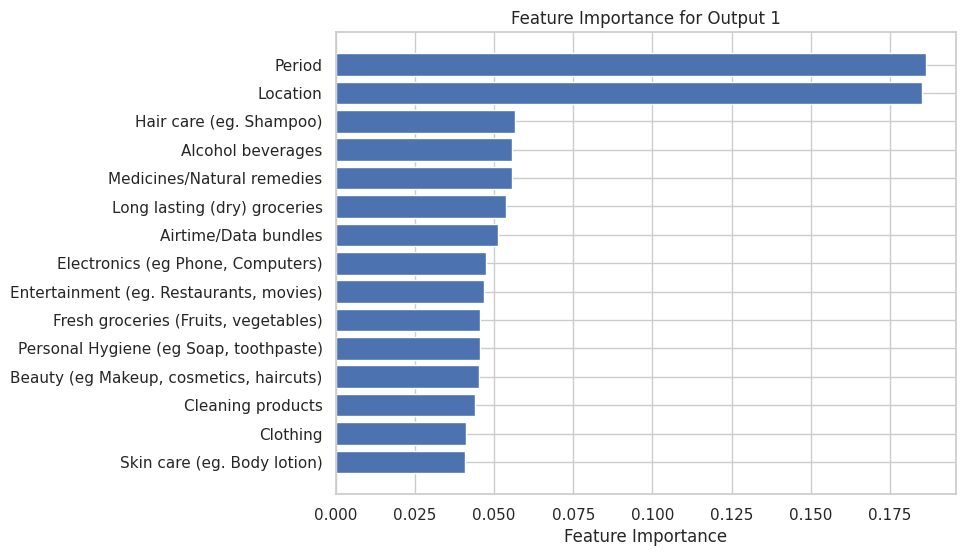

Feature importance for output 2:
Feature: Location, Importance: 0.19246237934745355
Feature: Period, Importance: 0.18035460973478049
Feature: Alcohol beverages, Importance: 0.06319883204366691
Feature: Medicines/Natural remedies, Importance: 0.056600458083941096
Feature: Long lasting (dry) groceries, Importance: 0.053630842307402914
Feature: Hair care (eg. Shampoo), Importance: 0.04984761911424883
Feature: Electronics (eg Phone, Computers), Importance: 0.04867260145590733
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.04841755475909017
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.04787003018272429
Feature: Airtime/Data bundles, Importance: 0.04644989715626655
Feature: Skin care (eg. Body lotion), Importance: 0.04637628272641939
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.04518079726280744
Feature: Clothing, Importance: 0.042534657764653185
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.03963785713138853
Feature: Clean

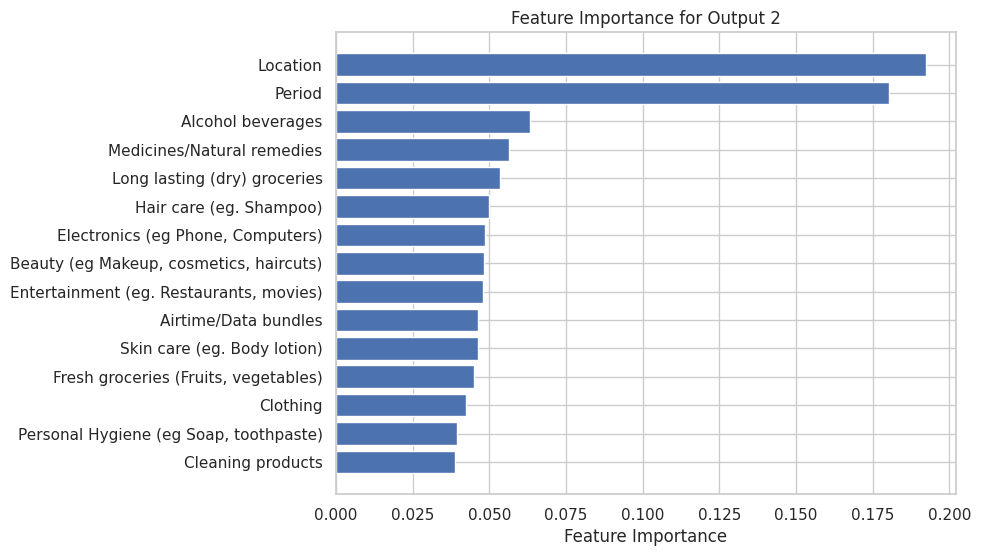

Feature importance for output 3:
Feature: Period, Importance: 0.18958142060920155
Feature: Location, Importance: 0.17452868444767208
Feature: Alcohol beverages, Importance: 0.06392442397671995
Feature: Medicines/Natural remedies, Importance: 0.057348114276598146
Feature: Long lasting (dry) groceries, Importance: 0.05168333975540931
Feature: Airtime/Data bundles, Importance: 0.05101049667015346
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.04840432157444812
Feature: Hair care (eg. Shampoo), Importance: 0.04813679658790264
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.04771523697785857
Feature: Skin care (eg. Body lotion), Importance: 0.04738857852404029
Feature: Electronics (eg Phone, Computers), Importance: 0.04619016060469914
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.0460165551650068
Feature: Clothing, Importance: 0.0455428897649281
Feature: Cleaning products, Importance: 0.042240677625567824
Feature: Personal Hygiene (eg Soap, to

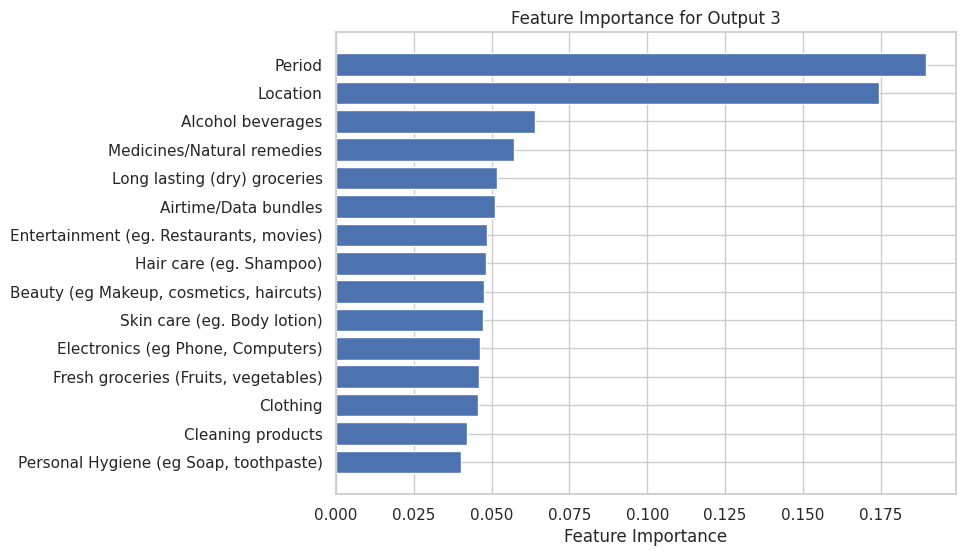

Feature importance for output 4:
Feature: Period, Importance: 0.27881217908982586
Feature: Location, Importance: 0.18878673790946673
Feature: Alcohol beverages, Importance: 0.05381905715700256
Feature: Medicines/Natural remedies, Importance: 0.04855870971559834
Feature: Electronics (eg Phone, Computers), Importance: 0.04492367411100343
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.04382965711736378
Feature: Hair care (eg. Shampoo), Importance: 0.043055808139416576
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.04285787867394876
Feature: Long lasting (dry) groceries, Importance: 0.040199875052950286
Feature: Skin care (eg. Body lotion), Importance: 0.03735612638984492
Feature: Clothing, Importance: 0.03727734532931731
Feature: Airtime/Data bundles, Importance: 0.03716011371783986
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.036668638074216005
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.034885575883594915
Feature: Clea

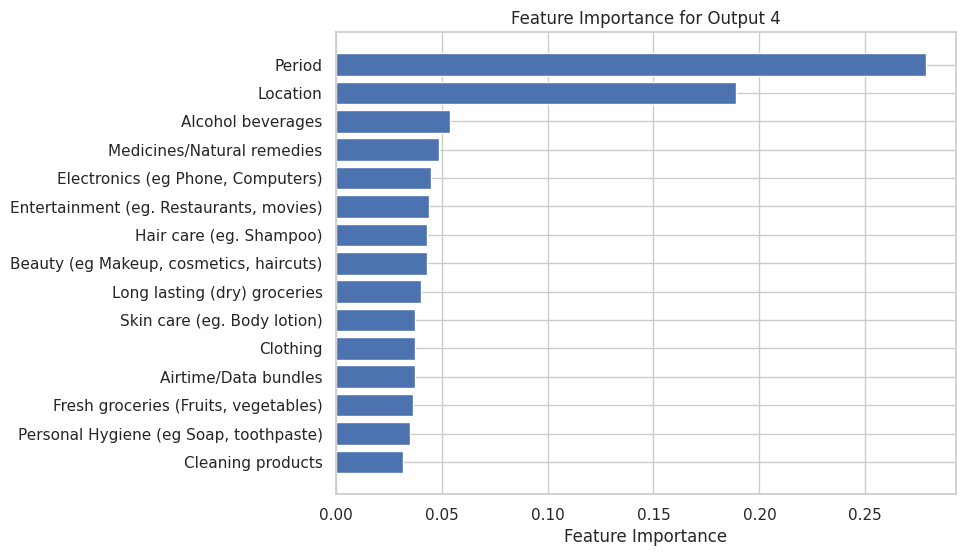

In [ ]:
# Loop through each classifier in the multi-output classifier
for i, estimator in enumerate(multi_classifier_rfc.estimators_):
    print(f"Feature importance for output {i + 1}:")

    # Get feature importances
    feature_importances = estimator.feature_importances_

    # Sort feature importance in descending order
    sorted_idx = np.argsort(feature_importances)[::-1]

    # Print sorted feature importances
    for idx in sorted_idx:
        print(f"Feature: {X_train.columns[idx]}, Importance: {feature_importances[idx]}")

    # Plot feature importances
    plt.figure(figsize=(8, 6))
    plt.barh(X_train.columns[sorted_idx], feature_importances[sorted_idx])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature Importance for Output {i + 1}")
    plt.gca().invert_yaxis()
    plt.show()

#### KNN Classifier

In [ ]:
# 5. Generate and display classification reports for each target
for i, target in enumerate(y.columns):
    print(f"Classification Report for {target}:\n")
    print(classification_report(y_test.iloc[:, i], y_pred_knn[:, i]))
    print("\n" + "="*50 + "\n")

Classification Report for Gender:

              precision    recall  f1-score   support

           0       0.51      0.49      0.50      1005
           1       0.52      0.54      0.53      1032

    accuracy                           0.51      2037
   macro avg       0.51      0.51      0.51      2037
weighted avg       0.51      0.51      0.51      2037



Classification Report for Age-group:

              precision    recall  f1-score   support

           0       0.19      0.29      0.23       150
           1       0.25      0.25      0.25       417
           2       0.29      0.18      0.22       327
           3       0.61      0.63      0.62      1143

    accuracy                           0.46      2037
   macro avg       0.33      0.34      0.33      2037
weighted avg       0.45      0.46      0.45      2037



Classification Report for Occupation:

              precision    recall  f1-score   support

           0       0.55      0.78      0.64      1064
           1 

#### XGBoost

In [ ]:
# 5. Generate and display classification reports for each target
for i, target in enumerate(y.columns):
    print(f"Classification Report for {target}:\n")
    print(classification_report(y_test.iloc[:, i], y_pred_xgb[:, i]))
    print("\n" + "="*50 + "\n")

Classification Report for Gender:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1005
           1       0.51      1.00      0.67      1032

    accuracy                           0.51      2037
   macro avg       0.25      0.50      0.34      2037
weighted avg       0.26      0.51      0.34      2037



Classification Report for Age-group:

              precision    recall  f1-score   support

           0       0.39      0.25      0.30       150
           1       0.28      0.18      0.22       417
           2       0.31      0.21      0.25       327
           3       0.61      0.77      0.68      1143

    accuracy                           0.52      2037
   macro avg       0.40      0.35      0.36      2037
weighted avg       0.48      0.52      0.49      2037



Classification Report for Occupation:

              precision    recall  f1-score   support

           0       0.58      0.73      0.65      1064
           1 


Feature importance for Gender:
Feature: Hair care (eg. Shampoo), Importance: 0.5921
Feature: Alcohol beverages, Importance: 0.0782
Feature: Skin care (eg. Body lotion), Importance: 0.0538
Feature: Electronics (eg Phone, Computers), Importance: 0.0314
Feature: Airtime/Data bundles, Importance: 0.0281
Feature: Location, Importance: 0.0249
Feature: Medicines/Natural remedies, Importance: 0.0243
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.0228
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.0226
Feature: Period, Importance: 0.0210
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.0210
Feature: Cleaning products, Importance: 0.0210
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.0207
Feature: Long lasting (dry) groceries, Importance: 0.0195
Feature: Clothing, Importance: 0.0189


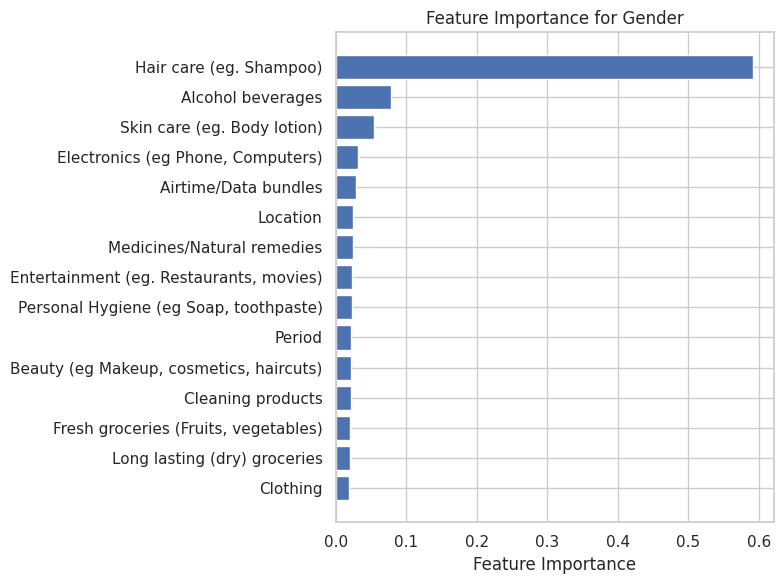


Feature importance for Age-group:
Feature: Location, Importance: 0.1201
Feature: Period, Importance: 0.0893
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.0660
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.0635
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.0632
Feature: Electronics (eg Phone, Computers), Importance: 0.0631
Feature: Skin care (eg. Body lotion), Importance: 0.0629
Feature: Hair care (eg. Shampoo), Importance: 0.0625
Feature: Airtime/Data bundles, Importance: 0.0620
Feature: Alcohol beverages, Importance: 0.0609
Feature: Medicines/Natural remedies, Importance: 0.0608
Feature: Cleaning products, Importance: 0.0574
Feature: Long lasting (dry) groceries, Importance: 0.0571
Feature: Clothing, Importance: 0.0557
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.0555


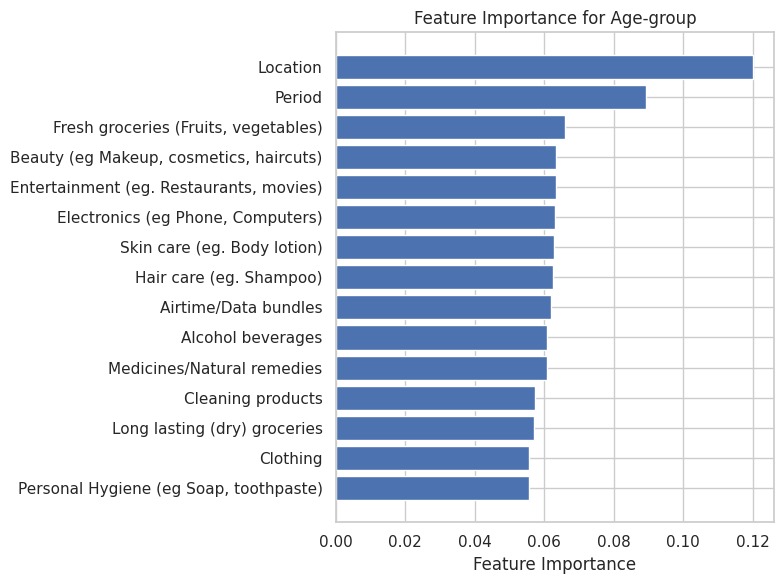


Feature importance for Occupation:
Feature: Location, Importance: 0.1211
Feature: Period, Importance: 0.0835
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.0734
Feature: Skin care (eg. Body lotion), Importance: 0.0657
Feature: Alcohol beverages, Importance: 0.0636
Feature: Hair care (eg. Shampoo), Importance: 0.0622
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.0621
Feature: Long lasting (dry) groceries, Importance: 0.0620
Feature: Electronics (eg Phone, Computers), Importance: 0.0620
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.0617
Feature: Clothing, Importance: 0.0592
Feature: Cleaning products, Importance: 0.0582
Feature: Airtime/Data bundles, Importance: 0.0572
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.0556
Feature: Medicines/Natural remedies, Importance: 0.0526


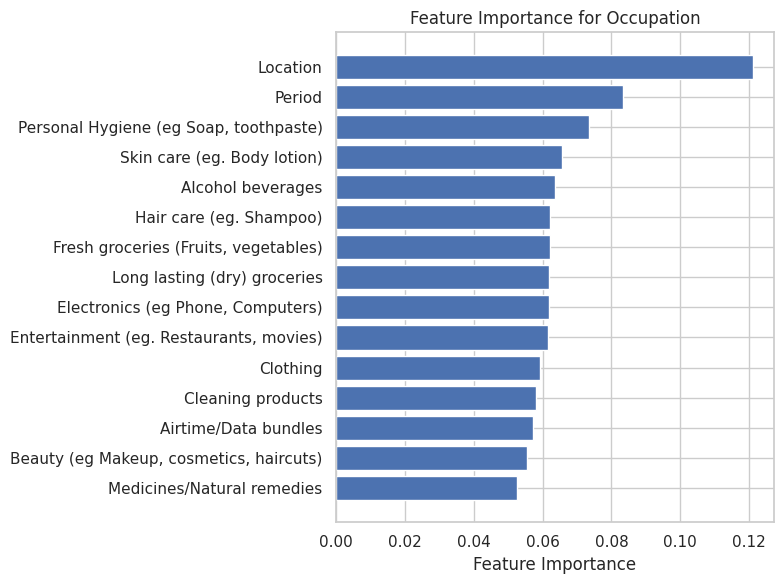


Feature importance for Income Level:
Feature: Period, Importance: 0.1979
Feature: Location, Importance: 0.1752
Feature: Personal Hygiene (eg Soap, toothpaste), Importance: 0.0692
Feature: Airtime/Data bundles, Importance: 0.0624
Feature: Clothing, Importance: 0.0561
Feature: Electronics (eg Phone, Computers), Importance: 0.0518
Feature: Fresh groceries (Fruits, vegetables), Importance: 0.0508
Feature: Beauty (eg Makeup, cosmetics, haircuts), Importance: 0.0472
Feature: Entertainment (eg. Restaurants, movies), Importance: 0.0469
Feature: Hair care (eg. Shampoo), Importance: 0.0457
Feature: Alcohol beverages, Importance: 0.0450
Feature: Long lasting (dry) groceries, Importance: 0.0424
Feature: Cleaning products, Importance: 0.0388
Feature: Skin care (eg. Body lotion), Importance: 0.0365
Feature: Medicines/Natural remedies, Importance: 0.0340


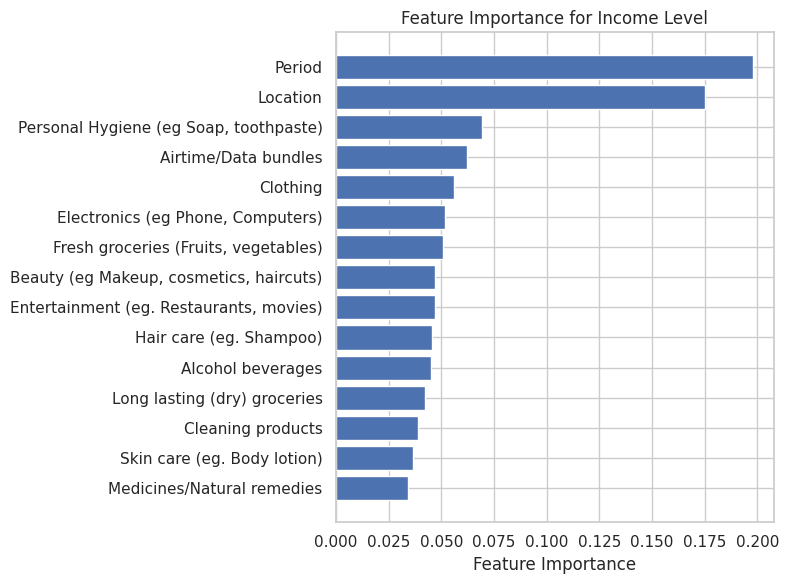

In [ ]:
# Plot feature importance
# Get label names (ensure this matches your target variable columns)
label_names = ["Gender", "Age-group", "Occupation", "Income Level"]  # or y_train.columns.tolist()

# Loop through each classifier in the multi-output classifier
for i, estimator in enumerate(multi_classifier_xgb.estimators_):
    print(f"\n\033[1mFeature importance for {label_names[i]}:\033[0m")  # Bold label

    # Get feature importances
    feature_importances = estimator.feature_importances_

    # Sort feature importance in descending order
    sorted_idx = np.argsort(feature_importances)[::-1]

    # Print sorted feature importances
    for idx in sorted_idx:
        print(f"Feature: {X_train.columns[idx]}, Importance: {feature_importances[idx]:.4f}")

    # Plot feature importances
    plt.figure(figsize=(8, 6))
    plt.barh(X_train.columns[sorted_idx], feature_importances[sorted_idx])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature Importance for {label_names[i]}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Model Improvement

### 1. Feature Selection for Multi-Output Models

#### Data Preparation and Feature Selection
> Apply Feature Selection:
* For multi‑output tasks, a tree‑based estimator (e.g., RandomForestClassifier or RandomForestRegressor) can be used with SelectFromModel to pick the most important features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Assume X_train (features) and y_train (multi-output targets) are defined
# For multi-output classification, you might wrap a base estimator.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Use the mean importance as threshold; adjust based on your needs
selector = SelectFromModel(rf, threshold='mean', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

#### Grid Search Model

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# For multi-output classification, you might use a multi-output wrapper if needed:
# Create the base estimator with GridSearchCV
base_estimator = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

# Create the MultiOutputClassifier
multi_output = MultiOutputClassifier(base_estimator)

# Fit the model
multi_output.fit(X_train_selected, y_train)

# Get the label names from y_train's columns
label_names = y_train.columns.tolist()  # e.g., ["Gender", "Age-group", "Occupation", "Income Level"]

# Access the best parameters for each output using label names
for i, estimator in enumerate(multi_output.estimators_):
    print(f"Best parameters for {label_names[i]}: {estimator.best_params_}")

# Store best models with their corresponding labels
best_models = {label: estimator.best_estimator_ for label, estimator in zip(label_names, multi_output.estimators_)}

Best parameters for Gender: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 150}
Best parameters for Age-group: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 150}
Best parameters for Occupation: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
Best parameters for Income Level: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report # Added for evaluation clarity
import joblib
import os

# --- Load Data (Replace with your actual loading) ---
try:
    data = pd.read_csv('data.csv')
    # Drop the unnamed index column if it exists
    if data.columns[0].strip() == '':
         data = data.drop(data.columns[0], axis=1)
except FileNotFoundError:
    print("Error: data.csv not found. Please ensure the CSV file is in the same directory.")
    exit()
except Exception as e:
    print(f"Error loading data: {e}")
    exit()

# --- Feature Engineering/Preprocessing (as provided) ---
print("Original Data Head:\n", data.head())
print("\nData Info:\n")
data.info()

# Make sure 'Age-group' mapping handles all values present in the data
unique_age_groups = data['Age-group'].unique()
print("\nUnique Age Groups:", unique_age_groups)
age_group_map = {'Millennials': 3, 'Gen Z': 2, 'Gen X': 1, 'Baby Boomers': 0}
# Check if all unique values are in the map
missing_age_groups = [ag for ag in unique_age_groups if ag not in age_group_map and pd.notna(ag)]
if missing_age_groups:
    print(f"Warning: Missing age groups in mapping: {missing_age_groups}. Update age_group_map.")
    # Handle missing groups if necessary, e.g., assign a default value or raise error

gender_map = {'Male': 1, 'Female': 0}
income_map = {'High Income': 2, 'Middle Income': 1, 'Low Income': 0}

# Ensure Occupation mapping is consistent and handles potential NaNs
data['Occupation'] = data['Occupation'].fillna('Unknown') # Handle potential NaNs
unique_occupations = data['Occupation'].unique()
print("\nUnique Occupations:", unique_occupations)
occupation_map = {v: i for i, v in enumerate(unique_occupations)}

# Create encoded target DataFrame
encoded_data = pd.DataFrame() # Start fresh to avoid potential issues
encoded_data['Gender'] = data['Gender'].map(gender_map)
encoded_data['Age-group'] = data['Age-group'].map(age_group_map)
encoded_data['Income Level'] = data['Income Level'].map(income_map)
encoded_data['Occupation'] = data['Occupation'].map(occupation_map)

# Define the target variables
y = encoded_data[['Gender', 'Age-group', 'Occupation', "Income Level"]].copy()
# Handle potential NaNs introduced by mapping if source data had unmapped values
y = y.fillna(-1) # Or use another strategy like imputation or dropping rows

# Define feature variables
feature_cols = [
    'Period', 'Location',
    'Personal Hygiene (eg Soap, toothpaste)', 'Cleaning products',
    'Long lasting (dry) groceries', 'Fresh groceries (Fruits, vegetables)',
    'Medicines/Natural remedies', 'Alcohol beverages',
    'Skin care (eg. Body lotion)', 'Hair care (eg. Shampoo)',
    'Entertainment (eg. Restaurants, movies)', 'Electronics (eg Phone, Computers)',
    'Beauty (eg Makeup, cosmetics, haircuts)', 'Clothing',
    'Airtime/Data bundles'
]

# Check if all feature columns exist
missing_features = [col for col in feature_cols if col not in data.columns]
if missing_features:
    print(f"Error: Missing feature columns in data.csv: {missing_features}")
    exit()

X = data[feature_cols].copy()

# --- Label Encode Features ---
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Ensure NaNs are handled before fitting/transforming
    X[col] = X[col].fillna('Unknown') # Replace NaNs with a placeholder string
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le # Store the fitted encoder

print("\nLabel Encoders created for:", list(label_encoders.keys()))

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain/Test Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# --- Feature Selection ---
# IMPORTANT: Fit the RandomForestClassifier for feature selection *only* on the training data
rf_selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector_model.fit(X_train, y_train) # Fit on the training data

selector = SelectFromModel(rf_selector_model, threshold='mean', prefit=True) # Use the already fitted model
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test) # Note: Renamed from X_test_sel for clarity

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("\nSelected Features:", selected_features.tolist())
print("Number of selected features:", X_train_selected.shape[1])

# --- Model Training (GridSearchCV) ---
param_grid = {
    'n_estimators': [100, 150], # Reduced grid for faster example
    'max_depth': [10, 20],
    'min_samples_split': [5, 10]
}

# Create the base estimator with GridSearchCV
# Using X_train_selected now
base_estimator = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3, # Use 3 folds for faster example
    scoring='accuracy',
    n_jobs=-1 # Use all available CPU cores
)

# Create the MultiOutputClassifier
multi_output = MultiOutputClassifier(base_estimator, n_jobs=-1)

# Fit the model using SELECTED features
print("\nStarting GridSearchCV and MultiOutputClassifier fitting...")
multi_output.fit(X_train_selected, y_train)
print("Fitting complete.")

# --- Evaluation (Optional but good practice) ---
print("\nEvaluating on test set...")
y_pred_grid = multi_output.predict(X_test_selected) # Use X_test_selected

# Prepare for report
label_names = y_train.columns.tolist()
y_pred_df = pd.DataFrame(y_pred_grid, columns=label_names)

print("\nClassification Report (per target):")
for i, label in enumerate(label_names):
    print(f"--- {label} ---")
    # Ensure y_test is accessed correctly
    if isinstance(y_test, pd.DataFrame):
        true_labels = y_test[label]
    else: # Assuming numpy array
        true_labels = y_test[:, i]

    pred_labels = y_pred_df[label]
    print(classification_report(true_labels, pred_labels, zero_division=0))
    print("-" * 20)


# --- Save the necessary objects ---
output_dir = "model"
os.makedirs(output_dir, exist_ok=True)

joblib.dump(multi_output, os.path.join(output_dir, 'multi_output_model.joblib'))
joblib.dump(label_encoders, os.path.join(output_dir, 'label_encoders.joblib'))
joblib.dump(selector, os.path.join(output_dir, 'feature_selector.joblib'))
joblib.dump(selected_features.tolist(), os.path.join(output_dir, 'selected_features.joblib')) # Save list of selected feature names
joblib.dump(occupation_map, os.path.join(output_dir, 'occupation_map.joblib')) # Save occupation map

# Define inverse maps for prediction output
inv_gender_map = {v: k for k, v in gender_map.items()}
inv_age_group_map = {v: k for k, v in age_group_map.items()}
inv_income_map = {v: k for k, v in income_map.items()}
inv_occupation_map = {v: k for k, v in occupation_map.items()}

# Also save the inverse maps
inverse_maps = {
    'Gender': inv_gender_map,
    'Age-group': inv_age_group_map,
    'Income Level': inv_income_map,
    'Occupation': inv_occupation_map
}
joblib.dump(inverse_maps, os.path.join(output_dir, 'inverse_maps.joblib'))
joblib.dump(feature_cols, os.path.join(output_dir, 'feature_cols.joblib')) # Save original feature cols list

print(f"\nModel, encoders, selector, feature lists, and maps saved to '{output_dir}' directory.")

Original Data Head:
    Unnamed: 0      Period  Year  Month Location  Gender    Age-group  \
0           0  2024-12-20  2024     12      MS1    Male        Gen Z   
1           1  2024-12-20  2024     12      MS1  Female        Gen X   
2           2  2024-12-20  2024     12      MS1    Male  Millennials   
3           3  2024-12-20  2024     12      MS1  Female        Gen Z   
4           4  2024-12-20  2024     12      MS1  Female  Millennials   

          Occupation   Income Level Personal Hygiene (eg Soap, toothpaste)  \
0  Salaried employee    High Income                                   Less   
1  Salaried employee  Middle Income                                   Less   
2  Salaried employee  Middle Income                                   Less   
3  Salaried employee  Middle Income                                   Less   
4  Salaried employee  Middle Income                                   Less   

   ... Fresh groceries (Fruits, vegetables) Medicines/Natural remedies  \
0  

In [ ]:
y_pred_grid[:5]

array([[0, 3, 0, 1],
       [0, 3, 0, 1],
       [1, 3, 0, 0],
       [1, 3, 0, 1],
       [0, 3, 2, 1]])

Prediction shape: (2037, 4)
Test data shape: (2037, 4)

Metrics for Gender:
Accuracy: 0.4320078546882671

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.32      0.35      1005
           1       0.45      0.54      0.49      1032

    accuracy                           0.43      2037
   macro avg       0.43      0.43      0.42      2037
weighted avg       0.43      0.43      0.42      2037



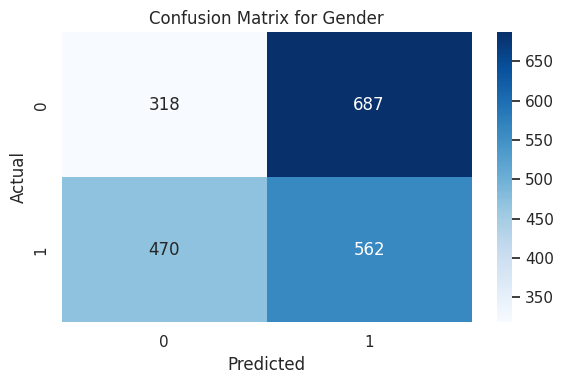


Metrics for Age-group:
Accuracy: 0.5675012272950417

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.21      0.34       150
           1       0.26      0.05      0.08       417
           2       0.37      0.06      0.11       327
           3       0.58      0.95      0.72      1143

    accuracy                           0.57      2037
   macro avg       0.53      0.32      0.31      2037
weighted avg       0.51      0.57      0.46      2037



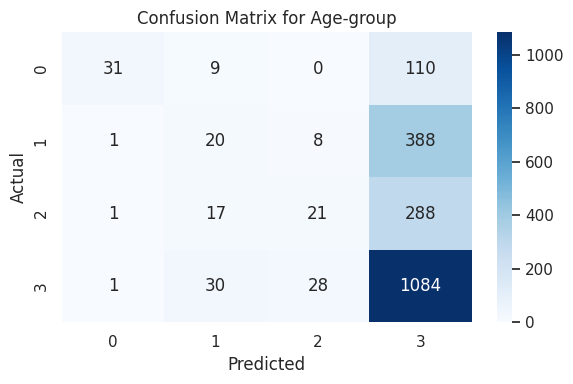


Metrics for Occupation:
Accuracy: 0.5297005400098184

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.95      0.69      1064
           1       0.72      0.11      0.19       164
           2       0.33      0.05      0.09       338
           3       0.30      0.07      0.11       267
           4       0.28      0.06      0.10       192
           5       0.00      0.00      0.00        12

    accuracy                           0.53      2037
   macro avg       0.36      0.21      0.20      2037
weighted avg       0.46      0.53      0.42      2037



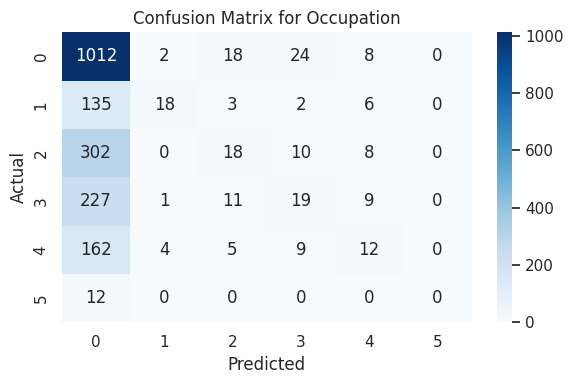


Metrics for Income Level:
Accuracy: 0.7309769268532155

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       606
           1       0.78      0.84      0.81      1297
           2       0.40      0.14      0.21       134

    accuracy                           0.73      2037
   macro avg       0.60      0.54      0.55      2037
weighted avg       0.71      0.73      0.72      2037



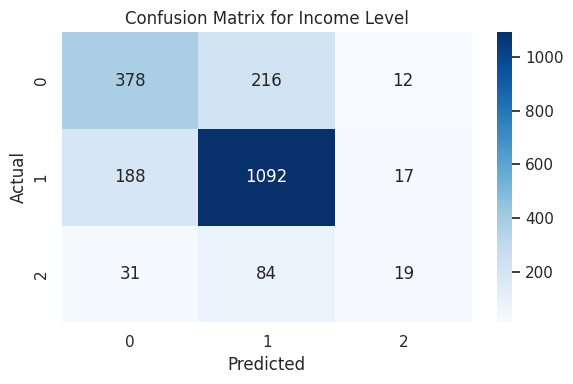

In [ ]:
# Ensure your data is in the correct format
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the Test Set
y_pred_grid = multi_output.predict(X_test_sel)

# Convert predictions and test data to numpy arrays if they aren't already
y_pred_grid = np.array(y_pred_grid)

# Get label names BEFORE converting y_test to numpy array (assuming y_test is a DataFrame)
if hasattr(y_test, 'columns'):
    label_names = y_test.columns.tolist()  # Use ["Gender", "Age-group", "Occupation", "Income Level"] if not a DataFrame
else:
    label_names = ["Gender", "Age-group", "Occupation", "Income Level"]

y_test = np.array(y_test)  # Convert after capturing label names

# Check the shapes
print("Prediction shape:", y_pred_grid.shape)
print("Test data shape:", y_test.shape)

# Modified evaluation function with label names
def evaluate_multi_output(y_true, y_pred, label_names):
    # Ensure y_true and y_pred are 2D numpy arrays
    y_true = np.atleast_2d(y_true)
    y_pred = np.atleast_2d(y_pred)

    # Check if shapes match
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Shapes don't match: y_true {y_true.shape}, y_pred {y_pred.shape}")

    # Evaluate each output with label names
    for i in range(y_true.shape[1]):
        print(f"\n\033[1mMetrics for {label_names[i]}:\033[0m")  # Bold label name
        print("Accuracy:", accuracy_score(y_true[:, i], y_pred[:, i]))
        print("\nClassification Report:")
        print(classification_report(y_true[:, i], y_pred[:, i]))

        # Confusion Matrix with label in title
        plt.figure(figsize=(6, 4))
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix for {label_names[i]}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

# Call the evaluation function with label names
evaluate_multi_output(y_test, y_pred_grid, label_names)

#### Model Improvement

#### Overall Interpretation

1. Varying performance across outputs: The model performs very differently on each output, ranging from poor (output 2) to good (output 1).
2. Class imbalance: The large differences between micro and macro F1 scores (especially for outputs 1 and 2) indicate class imbalance issues. The micro-average gives each sample equal weight, while macro-average gives each class equal weight.
3. Precision vs. recall trade-offs: Output 1 shows high precision but lower recall, suggesting your model is conservative in its predictions for this output - it's more likely to miss positive cases than make false positive predictions.
4. Average metrics (last line): The overall model achieves 61.78% accuracy across all outputs, which is moderate performance. The lower macro-F1 (0.412) compared to accuracy suggests that the model performs better on majority classes.

Recommendations

1. For Output 2, consider:
* Class rebalancing techniques
* Feature engineering specific to this output
* A dedicated model just for this difficult output


2. For Output 1, if recall is important:
* Adjust classification thresholds
* Consider recall-focused training objectives


In general:
* Separate model training for each output might be better than a single multi-output model
* Apply class weighting to improve performance on minority classes
* Use stratified sampling during validation to get a clearer picture of performance



These metrics suggest we'd benefit from focusing optimization efforts on outputs 0 and 2, which have the weakest performance.

### 3. Train an Artificial Neural Network (ANN) - Keras ANN with Keras Tuner

#### Hyperparameter Tuning Using Keras Tuner
1. Define a Model Builder Function:
Create a function that accepts a hp (hyperparameter) object and returns a compiled model.

2. Set up Keras Tuner:
Use a tuner (e.g., RandomSearch or Hyperband) to search for the best hyperparameters.

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()
    # Tune the number of units in the first Dense layer
    hp_units = hp.Int('units', min_value=32, max_value=256, step=32)
    model.add(layers.Dense(units=hp_units, activation='relu',
                           input_shape=(X_train_selected.shape[1],)))
    # Optionally add dropout
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))
    # Add a second Dense layer
    hp_units2 = hp.Int('units2', min_value=16, max_value=128, step=16)
    model.add(layers.Dense(units=hp_units2, activation='relu'))
    # Output layer: for multi-output classification (use activation appropriate to your task)
    model.add(layers.Dense(y_train.shape[1], activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',  # adjust if doing regression
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Increase trials for a more extensive search
    executions_per_trial=1,
    directory='my_dir',
    project_name='ann_tuning'
)

# Perform hyperparameter search
tuner.search(X_train_selected, y_train, epochs=20, validation_split=0.2)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hps.values)

# Build the best model and train it
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train_selected, y_train, epochs=50, validation_split=0.2, batch_size=32)


Trial 10 Complete [00h 00m 20s]
val_accuracy: 0.6932515501976013

Best val_accuracy So Far: 0.6932515501976013
Total elapsed time: 00h 03m 46s
Best hyperparameters: {'units': 192, 'dropout': 0.0, 'units2': 16, 'learning_rate': 0.0001}
Epoch 1/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6999 - loss: -0.6699 - val_accuracy: 0.6933 - val_loss: -3.6403
Epoch 2/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6944 - loss: -5.0951 - val_accuracy: 0.6933 - val_loss: -10.5528
Epoch 3/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6980 - loss: -13.4875 - val_accuracy: 0.6933 - val_loss: -27.1503
Epoch 4/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7036 - loss: -34.4964 - val_accuracy: 0.6933 - val_loss: -64.2734
Epoch 5/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6989 - loss: -77.8520 - val_accuracy: 0.6933 - val_loss: -124.1971
Epoch 6/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7024 - loss: -145.1965 - val_accuracy: 0.

In [ ]:
import numpy as np
import pandas as pd # Import pandas to check instance type if needed
from sklearn.metrics import roc_auc_score # Keep import for AUC

# --- ASSUMPTIONS ---
# 1. 'model' is your trained multi-label classification model (e.g., Keras, scikit-learn compatible)
# 2. 'X_test_sel' is your preprocessed test feature data (NumPy array or DataFrame)
# 3. 'y_test' contains the true labels for the test set (NumPy array or pandas DataFrame/Series)
#    - It should have shape (n_samples, n_classes)
#    - Values should be binary (0 or 1)

# Predict probabilities using your actual model and data
print("Predicting probabilities on X_test_sel...")
y_pred_prob = model.predict(X_test_sel)
# Example Keras output log: 64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
print(f"Prediction finished. y_pred_prob shape: {y_pred_prob.shape}")


# Apply threshold (default 0.5)
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int) # y_pred is now a NumPy array

# --- Print shapes and sample values to understand data format ---
print(f"\ny_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}") # Should match y_test shape
print(f"y_pred type: {type(y_pred)}") # Should be numpy.ndarray
print(f"y_pred sample (first 5 rows):\n{y_pred[:5]}")

# --- Handle y_test type, print info, get class names, and convert to NumPy ---
class_names = None
y_test_np = None

if isinstance(y_test, (pd.DataFrame, pd.Series)):
    print(f"y_test type: {type(y_test)}")
    # If DataFrame, print dtypes per column
    if isinstance(y_test, pd.DataFrame):
        print(f"y_test column dtypes:\n{y_test.dtypes}")
        class_names = y_test.columns.tolist() # Get column names
    else: # If Series (less common for multi-label, but possible)
         print(f"y_test Series dtype: {y_test.dtype}")
         class_names = [y_test.name] if y_test.name else ["Class 0"] # Get Series name
    print(f"y_test sample (first 5 rows):\n{y_test.head()}")
    y_test_np = y_test.values.astype(int) # Convert pandas to numpy array
    # Ensure y_test_np is 2D if it came from a Series
    if y_test_np.ndim == 1:
         y_test_np = y_test_np.reshape(-1, 1)


elif isinstance(y_test, np.ndarray):
    print(f"y_test type: {type(y_test)}")
    print(f"y_test array dtype: {y_test.dtype}")
    print(f"y_test sample (first 5 rows):\n{y_test[:5]}")
    y_test_np = y_test.astype(int) # Ensure correct dtype
    # Ensure y_test_np is 2D
    if y_test_np.ndim == 1:
         y_test_np = y_test_np.reshape(-1, 1)
    # Generate generic class names if they weren't extracted from pandas
    num_classes_check = y_test_np.shape[1]
    class_names = [f"Class {i}" for i in range(num_classes_check)]

else:
    # Handle other potential types or raise error
    print(f"y_test type: {type(y_test)} - Unexpected type!")
    try:
         y_test_np = np.array(y_test).astype(int)
         if y_test_np.ndim == 1:
              y_test_np = y_test_np.reshape(-1, 1)
         num_classes_check = y_test_np.shape[1]
         class_names = [f"Class {i}" for i in range(num_classes_check)]
         print(f"Attempted conversion to NumPy array. Shape: {y_test_np.shape}")
    except Exception as e:
         print(f"Could not convert y_test to NumPy array: {e}")
         raise TypeError("y_test must be a pandas DataFrame/Series or NumPy array.") from e

# Ensure y_pred_np is also a NumPy array of integers
y_pred_np = y_pred.astype(int)
if y_pred_np.ndim == 1:
    y_pred_np = y_pred_np.reshape(-1, 1) # Ensure 2D

# --- Sanity Check Shapes ---
if y_test_np.shape != y_pred_np.shape:
    raise ValueError(f"Shape mismatch! y_test_np shape {y_test_np.shape} != y_pred_np shape {y_pred_np.shape}")
if y_test_np.shape[1] != len(class_names):
     raise ValueError(f"Mismatch between number of columns in y_test_np ({y_test_np.shape[1]}) and number of class names ({len(class_names)})")

num_classes = y_test_np.shape[1]
print(f"\nData prepared for metric calculation. Number of classes: {num_classes}")

# --- Manual calculation of metrics ---

# 1. Subset accuracy (exact match)
subset_accuracy = np.all(y_test_np == y_pred_np, axis=1).mean()
print(f"\nSubset Accuracy (Exact Match): {subset_accuracy:.4f}")

# 2. Hamming score (1 - Hamming loss) - manually calculated
# This is equivalent to accuracy calculated element-wise across all samples and labels
hamming_score = np.mean(y_test_np == y_pred_np)
print(f"Hamming Score (Element-wise Accuracy): {hamming_score:.4f}")
print(f"Hamming Loss: {1 - hamming_score:.4f}")


# 3. Manual calculation of per-class metrics (using default 0.5 threshold)
print("\nPer-class metrics (using threshold=0.5):")
all_precisions = []
all_recalls = []
all_f1s = []
all_accuracies = []

for i in range(num_classes):
    class_name = class_names[i]

    tp = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 1))
    fp = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 1))
    fn = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 0))
    tn = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 0))

    # Calculate precision, recall, f1, accuracy
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    all_precisions.append(precision)
    all_recalls.append(recall)
    all_f1s.append(f1)
    all_accuracies.append(accuracy)

    print(f"{class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Support: (Pos={tp+fn}, Neg={tn+fp}) Total={tp+tn+fp+fn}")


# 4. Confusion matrix for each class (using default 0.5 threshold)
print("\nConfusion matrices per class (using threshold=0.5):")
for i in range(num_classes):
    class_name = class_names[i]

    tp = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 1))
    fp = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 1))
    fn = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 0))
    tn = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 0))

    print(f"{class_name} confusion matrix:")
    print(f"       Pred: 0  Pred: 1")
    print(f"True: 0 [{tn:^6d}] [{fp:^6d}]")
    print(f"True: 1 [{fn:^6d}] [{tp:^6d}]")


# 5. Calculate AUC-ROC for each class (using predicted probabilities)
print("\nAUC-ROC per class:")
auc_scores = []
try:
    for i in range(num_classes):
        class_name = class_names[i]
        # Check if class has both positive and negative samples in y_test
        if len(np.unique(y_test_np[:, i])) < 2:
             print(f"{class_name} AUC-ROC: Not defined (only one class present in y_test)")
             auc_scores.append(np.nan)
             continue
        try:
            # Ensure y_pred_prob is 2D for indexing
            if y_pred_prob.ndim == 1:
                y_pred_prob = y_pred_prob.reshape(-1, 1)

            # roc_auc_score needs true labels (1D) and prediction scores (1D)
            auc = roc_auc_score(y_test_np[:, i], y_pred_prob[:, i])
            print(f"{class_name} AUC-ROC: {auc:.4f}")
            auc_scores.append(auc)
        except ValueError as ve:
             print(f"{class_name} AUC-ROC: Error - {str(ve)}")
             auc_scores.append(np.nan)
        except Exception as e:
             print(f"{class_name} AUC-ROC: Error - {str(e)}")
             auc_scores.append(np.nan)

    # Calculate Macro Average AUC if needed (ignoring NaNs)
    valid_auc_scores = [s for s in auc_scores if not np.isnan(s)]
    if len(valid_auc_scores) > 0:
         macro_auc = np.mean(valid_auc_scores)
         print(f"\nMacro Average AUC-ROC: {macro_auc:.4f}")
    else:
         print("\nMacro Average AUC-ROC: Not defined (no valid class AUCs)")

except ImportError:
    print("\nAUC-ROC calculation skipped: scikit-learn not found.")
except Exception as e:
    print(f"\nAn error occurred during AUC calculation: {str(e)}")


# 6. Optimal thresholds per class (based on F1-score, using predicted probabilities)
print("\nOptimal thresholds per class (maximizing F1):")
optimal_thresholds = {} # Store as dict {class_name: threshold}
for i in range(num_classes):
    class_name = class_names[i]

    # Check if class has positive samples in y_test for F1 calculation
    if np.sum(y_test_np[:, i]) == 0:
        print(f"{class_name}: Optimal threshold not determined (no positive samples in y_test)")
        optimal_thresholds[class_name] = np.nan # Or a default like 0.5
        continue

    thresholds_to_check = np.arange(0.05, 1.0, 0.05)
    best_f1 = -1
    best_threshold = 0.5 # Default

    # Ensure y_pred_prob is 2D for indexing
    if y_pred_prob.ndim == 1:
        y_pred_prob = y_pred_prob.reshape(-1, 1)

    for t in thresholds_to_check:
        y_pred_class = (y_pred_prob[:, i] >= t).astype(int)
        tp = np.sum((y_test_np[:, i] == 1) & (y_pred_class == 1))
        fp = np.sum((y_test_np[:, i] == 0) & (y_pred_class == 1))
        fn = np.sum((y_test_np[:, i] == 1) & (y_pred_class == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    optimal_thresholds[class_name] = best_threshold
    print(f"{class_name}: Optimal threshold = {best_threshold:.2f} (Max F1: {best_f1:.4f})")


# 7. Overall metrics (macro & micro avg using the default 0.5 threshold predictions)
print("\nOverall metrics (using default threshold=0.5):")

# Macro averages (mean of per-class metrics)
# Using the metrics calculated in step 3
print(f"Macro-Precision: {np.mean(all_precisions):.4f}")
print(f"Macro-Recall: {np.mean(all_recalls):.4f}")
print(f"Macro-F1: {np.mean(all_f1s):.4f}")
print(f"Average Accuracy (per-class mean): {np.mean(all_accuracies):.4f}")

# Micro averages (aggregate TP, FP, FN across all classes)
tp_micro = np.sum((y_test_np == 1) & (y_pred_np == 1))
fp_micro = np.sum((y_test_np == 0) & (y_pred_np == 1))
fn_micro = np.sum((y_test_np == 1) & (y_pred_np == 0))
# tn_micro = np.sum((y_test_np == 0) & (y_pred_np == 0)) # TN is not typically used directly in micro P/R/F1

micro_prec = tp_micro / (tp_micro + fp_micro) if (tp_micro + fp_micro) > 0 else 0
micro_rec = tp_micro / (tp_micro + fn_micro) if (tp_micro + fn_micro) > 0 else 0
micro_f1 = 2 * micro_prec * micro_rec / (micro_prec + micro_rec) if (micro_prec + micro_rec) > 0 else 0

print(f"\nMicro-Precision: {micro_prec:.4f}")
print(f"Micro-Recall: {micro_rec:.4f}")
print(f"Micro-F1: {micro_f1:.4f}")

print("\n--- Evaluation Complete ---")

Predicting probabilities on X_test_sel...
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Prediction finished. y_pred_prob shape: (2037, 4)

y_test shape: (2037, 4)
y_pred shape: (2037, 4)
y_pred type: <class 'numpy.ndarray'>
y_pred sample (first 5 rows):
[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]]
y_test type: <class 'numpy.ndarray'>
y_test array dtype: int64
y_test sample (first 5 rows):
[[0 3 0 0]
 [1 3 0 1]
 [1 1 0 1]
 [0 1 0 1]
 [0 1 3 1]]

Data prepared for metric calculation. Number of classes: 4

Subset Accuracy (Exact Match): 0.0000
Hamming Score (Element-wise Accuracy): 0.3571
Hamming Loss: 0.6429

Per-class metrics (using threshold=0.5):
Class 0:
  Precision: 0.5066
  Recall: 1.0000
  F1-score: 0.6725
  Accuracy: 0.5066
  Support: (Pos=1032, Neg=1005) Total=2037
Class 1:
  Precision: 0.7354
  Recall: 1.0000
  F1-score: 0.8476
  Accuracy: 0.7354
  Support: (Pos=417, Neg=150) Total=567
Class 2:
  Precision: 0.1336
  Recall: 1.0000
  F1-score: 0.2356
  Accuracy: 0.1336
  Sup

In [ ]:
# 1. Preprocess the data
# Define the target variables (multi-label targets)
y = encoded_data[['Age-group', 'Occupation']]

# Define feature variables (exclude target columns and irrelevant ones)
X = data.drop(columns=['Age-group', 'Occupation', 'Year', 'Month'])

# Encode categorical variables in features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
# 2. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.shape, y.shape)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Use the mean importance as threshold; adjust based on your needs
selector = SelectFromModel(rf, threshold='mean', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

(10184, 18) (10184, 2)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np

def build_model(hp):
    model = keras.Sequential()

    # Dynamically add layers based on hyperparameter tuning
    n_layers = hp.Int('n_layers', 1, 4, default=2)

    for i in range(n_layers):
        # Tune the number of units for each layer
        hp_units = hp.Int(f'units_{i}',
                          min_value=32,
                          max_value=256,
                          step=32,
                          default=64)

        # First layer needs input shape specified
        if i == 0:
            model.add(layers.Dense(units=hp_units,
                                   activation='relu',
                                   input_shape=(X_train_selected.shape[1],)))
        else:
            model.add(layers.Dense(units=hp_units, activation='relu'))

        # Add dropout after each layer
        hp_dropout = hp.Float(f'dropout_{i}',
                              min_value=0.0,
                              max_value=0.5,
                              step=0.1,
                              default=0.2)
        model.add(layers.Dropout(rate=hp_dropout))

    # Flexible output layer
    if y_train.shape[1] > 1:
        # Multi-class classification
        output_activation = 'softmax'
        loss_function = 'categorical_crossentropy'
    else:
        # Binary classification
        output_activation = 'sigmoid'
        loss_function = 'binary_crossentropy'

    model.add(layers.Dense(y_train.shape[1], activation=output_activation))

    # Advanced learning rate scheduling
    hp_learning_rate = hp.Choice('learning_rate',
                                 values=[1e-2, 1e-3, 1e-4],
                                 default=1e-3)

    # Choose optimizer
    hp_optimizer = hp.Choice('optimizer',
                             values=['adam', 'rmsprop', 'sgd'],
                             default='adam')

    if hp_optimizer == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=hp_learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss=loss_function,
                  metrics=['accuracy'])

    return model

def tune_and_train(X_train_selected, y_train, X_val, y_val):
    # More comprehensive tuner with increased search space
    tuner = kt.RandomSearch(
        build_model,
        objective='val_accuracy',
        max_trials=30,  # Increased trials for more thorough search
        executions_per_trial=3,  # Multiple executions for statistical significance
        directory='hyperparameter_tuning',
        project_name='neural_network_optimization'
    )

    # Early stopping to prevent overfitting
    stop_early = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Perform hyperparameter search with early stopping
    tuner.search(
        X_train_selected, y_train,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=[stop_early]
    )

    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("Best Hyperparameters:", best_hps.values)

    # Build and train the best model
    model = tuner.hypermodel.build(best_hps)

    # Learning rate scheduling
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=best_hps.get('learning_rate'),
        decay_steps=10,
        decay_rate=0.9
    )

    model.optimizer.learning_rate = lr_schedule

    # Train with more sophisticated callback setup
    history = model.fit(
        X_train_selected, y_train,
        epochs=100,
        validation_data=(X_val, y_val),
        batch_size=32,
        callbacks=[
            stop_early,
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=3,
                min_lr=1e-5
            )
        ]
    )

    return model, history

# Example usage (you'll need to replace with your actual data splitting)
model, history = tune_and_train(X_train_selected, y_train, X_test_sel, y_test)

Trial 30 Complete [00h 00m 32s]
val_accuracy: 0.7766323089599609

Best val_accuracy So Far: 0.7766323089599609
Total elapsed time: 00h 18m 32s
Best Hyperparameters: {'n_layers': 2, 'units_0': 128, 'dropout_0': 0.1, 'units_1': 224, 'dropout_1': 0.1, 'learning_rate': 0.001, 'optimizer': 'adam', 'units_2': 64, 'dropout_2': 0.4}
Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7647 - loss: 7643.0352 - val_accuracy: 0.7766 - val_loss: 25795.2266 - learning_rate: 6.8106e-05
Epoch 2/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7818 - loss: 27070.2246 - val_accuracy: 0.7766 - val_loss: 28675.0898 - learning_rate: 4.6384e-06
Epoch 3/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7838 - loss: 28952.9414 - val_accuracy: 0.7766 - val_loss: 28849.0039 - learning_rate: 3.1590e-07
Epoch 4/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7976 - loss: 28574.7363 - val_accuracy: 0.7766 - val_loss: 28860.5527 - learning_rate: 2.1515e-08
Epoch 5/100
2

# Evaluation Metrics for the ANN
After training, evaluate the ANN using similar metrics as before. For multi‑output tasks, we may need to threshold the outputs

In [ ]:
# Predict probabilities
y_pred_prob = model.predict(X_test_sel)

# Apply threshold (default 0.5)
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

# Print shapes and sample values to understand data format
print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_test type: {type(y_test)}")
print(f"y_pred type: {type(y_pred)}")
print(f"y_test column dtypes: {y_test.dtypes}")
print(f"y_test sample:\n{y_test.head()}")
print(f"y_pred sample:\n{y_pred[:5]}")

# Convert both to numpy arrays with same data type
y_test_np = y_test.values.astype(int)
y_pred_np = y_pred.astype(int)

# Manual calculation of metrics
# 1. Subset accuracy (exact match)
subset_accuracy = np.all(y_test_np == y_pred_np, axis=1).mean()
print(f"\nSubset Accuracy (Exact Match): {subset_accuracy:.4f}")

# 2. Hamming score (1 - Hamming loss) - manually calculated
hamming_score = np.mean(np.equal(y_test_np, y_pred_np))
print(f"Hamming Score: {hamming_score:.4f}")
print(f"Hamming Loss: {1 - hamming_score:.4f}")

# 3. Manual calculation of per-class metrics
print("\nPer-class metrics:")
for i in range(y_test.shape[1]):
    # True positives, false positives, false negatives
    tp = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 1))
    fp = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 1))
    fn = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 0))
    tn = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 0))

    # Calculate precision, recall, f1, accuracy
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Get class name if available
    class_name = y_test.columns[i] if hasattr(y_test, 'columns') else f"Class {i}"

    print(f"{class_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Support: (Pos={tp+fn}, Neg={tn+fp})")

# 4. Confusion matrix for each class
print("\nConfusion matrices per class:")
for i in range(y_test.shape[1]):
    # Get class name if available
    class_name = y_test.columns[i] if hasattr(y_test, 'columns') else f"Class {i}"

    tp = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 1))
    fp = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 1))
    fn = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 0))
    tn = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 0))

    print(f"{class_name} confusion matrix:")
    print(f"  TN: {tn}, FP: {fp}")
    print(f"  FN: {fn}, TP: {tp}")

# 5. Calculate AUC-ROC for each class
print("\nAUC-ROC per class:")
for i in range(y_test.shape[1]):
    try:
        from sklearn.metrics import roc_auc_score
        # Make sure we're sending 1D arrays
        auc = roc_auc_score(y_test_np[:, i], y_pred_prob[:, i])

        # Get class name if available
        class_name = y_test.columns[i] if hasattr(y_test, 'columns') else f"Class {i}"
        print(f"{class_name} AUC-ROC: {auc:.4f}")
    except Exception as e:
        print(f"Class {i} AUC-ROC: Error - {str(e)}")

# 6. Optimal thresholds
print("\nOptimal thresholds per class:")
for i in range(y_test.shape[1]):
    # Get class name if available
    class_name = y_test.columns[i] if hasattr(y_test, 'columns') else f"Class {i}"

    thresholds = np.arange(0.1, 1.0, 0.05)
    best_f1 = 0
    best_threshold = 0.5

    for t in thresholds:
        y_pred_class = (y_pred_prob[:, i] >= t).astype(int)
        tp = np.sum((y_test_np[:, i] == 1) & (y_pred_class == 1))
        fp = np.sum((y_test_np[:, i] == 0) & (y_pred_class == 1))
        fn = np.sum((y_test_np[:, i] == 1) & (y_pred_class == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    print(f"{class_name}: Optimal threshold = {best_threshold:.2f} (F1: {best_f1:.4f})")

# 7. Overall metrics (macro avg)
precisions = []
recalls = []
f1s = []

for i in range(y_test.shape[1]):
    tp = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 1))
    fp = np.sum((y_test_np[:, i] == 0) & (y_pred_np[:, i] == 1))
    fn = np.sum((y_test_np[:, i] == 1) & (y_pred_np[:, i] == 0))

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

print(f"\nMacro-Precision: {np.mean(precisions):.4f}")
print(f"Macro-Recall: {np.mean(recalls):.4f}")
print(f"Macro-F1: {np.mean(f1s):.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
y_test shape: (2037, 2)
y_pred shape: (2037, 2)
y_test type: <class 'pandas.core.frame.DataFrame'>
y_pred type: <class 'numpy.ndarray'>
y_test column dtypes: Age-group     int64
Occupation    int64
dtype: object
y_test sample:
      Age-group  Occupation
3898          3           0
6111          3           0
4123          1           0
718           1           0
3132          1           3
y_pred sample:
[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]

Subset Accuracy (Exact Match): 0.1001
Hamming Score: 0.3635
Hamming Loss: 0.6365

Per-class metrics:
Age-group:
  Precision: 0.7354
  Recall: 1.0000
  F1-score: 0.8476
  Accuracy: 0.7354
  Support: (Pos=417, Neg=150)
Occupation:
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
  Accuracy: 0.8664
  Support: (Pos=164, Neg=1064)

Confusion matrices per class:
Age-group confusion matrix:
  TN: 0, FP: 150
  FN: 0, TP: 417
Occupation confusion matrix:
  TN: 1064, FP: 0
  FN: 164, TP: 0

AUC-ROC per class:
Cl

### Model Interpretability

In [ ]:
!pip install shap

#### SHAP

####  Random Forest

Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Calculating SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━

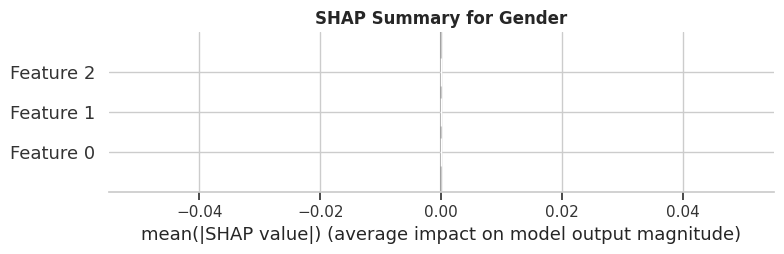


SHAP Analysis for Age-group


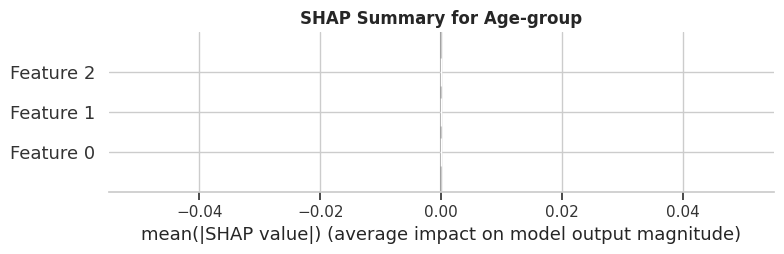


SHAP Analysis for Occupation


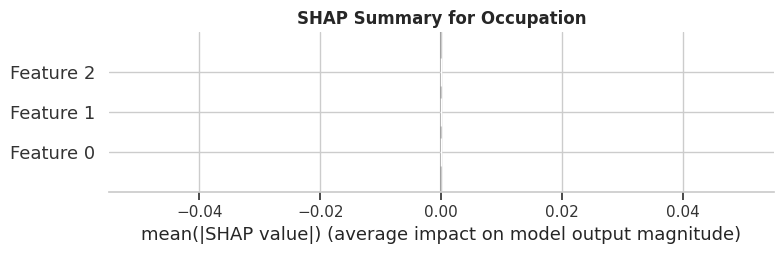


SHAP analysis completed.


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define your label names explicitly
label_names = ["Gender", "Age-group", "Occupation", "Income Level"]

# First, make sure X_test_sel is a numpy array
if hasattr(X_test_sel, 'values'):
    X_test_np = X_test_sel.values
else:
    X_test_np = X_test_sel

# Get feature names (if available)
if hasattr(X_test_sel, 'columns'):
    feature_names = list(X_test_sel.columns)
else:
    feature_names = [f"Feature {i}" for i in range(X_test_np.shape[1])]

# Select a smaller subset for analysis
sample_size = min(200, len(X_test_np))
sample_indices = np.random.choice(len(X_test_np), sample_size, replace=False)
X_sample = X_test_np[sample_indices]

# Create background dataset
background_size = min(100, len(X_test_np))
background_indices = np.random.choice(len(X_test_np), background_size, replace=False)
background = X_test_np[background_indices]

# Create explainer
print("Creating SHAP explainer...")
explainer = shap.KernelExplainer(model.predict, background)

# Calculate SHAP values
print("Calculating SHAP values (this may take a while)...")
shap_values = explainer.shap_values(X_sample)

# Modified visualization with label names
if not isinstance(shap_values, list) and len(shap_values.shape) == 3:
    print("Detected 3D SHAP values, reshaping...")
    n_samples, n_features = X_sample.shape
    _, n_outputs, output_dim = shap_values.shape

    # Reshape and visualize with proper labels
    reshaped_shap_values = []
    for output_idx in range(n_outputs):
        output_shap = shap_values[:, output_idx, :]
        if output_dim == n_features:
            reshaped_shap_values.append(output_shap)
        else:
            aggregated_output = np.mean(output_shap, axis=1).reshape(n_samples, 1)
            compatible_shap = np.repeat(aggregated_output, n_features, axis=1)
            reshaped_shap_values.append(compatible_shap)

    # Visualize with label names
    for i, output_shap_values in enumerate(reshaped_shap_values):
        if i < len(label_names):
            current_label = label_names[i]
        else:
            current_label = f"Output {i}"

        print(f"\n\033[1mSHAP Analysis for {current_label}\033[0m")

        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                output_shap_values,
                X_sample,
                feature_names=feature_names,
                show=False,
                plot_type="bar"
            )
            plt.title(f"SHAP Summary for {current_label}", weight='bold')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Visualization failed: {e}")
            # Fallback to importance plot
            mean_abs_shap = np.abs(output_shap_values).mean(axis=0)
            pd.DataFrame({
                'Feature': feature_names,
                'Importance': mean_abs_shap
            }).sort_values('Importance', ascending=False).head(10).plot.barh(
                x='Feature',
                y='Importance',
                title=f'Top Features for {current_label}',
                figsize=(10, 6)
            )
            plt.gca().invert_yaxis()
            plt.show()

elif isinstance(shap_values, list):
    # Handle list format with label names
    for i, output_shap_values in enumerate(shap_values):
        if i < len(label_names):
            current_label = label_names[i]
        else:
            current_label = f"Output {i}"

        print(f"\n\033[1mSHAP Analysis for {current_label}\033[0m")

        try:
            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                output_shap_values,
                X_sample,
                feature_names=feature_names,
                show=False
            )
            plt.title(f"SHAP Summary for {current_label}", weight='bold')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Visualization failed: {e}")

else:
    # Single output case
    print("\n\033[1mSHAP Analysis\033[0m")
    try:
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values,
            X_sample,
            feature_names=feature_names,
            show=False
        )
        plt.title("SHAP Summary", weight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Visualization failed: {e}")

print("\nSHAP analysis completed.")

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define your label names explicitly
label_names = ["Gender", "Age-group", "Occupation", "Income Level"]

# First, make sure X_test_sel is a numpy array
if hasattr(X_test_sel, 'values'):
    X_test_np = X_test_sel.values
else:
    X_test_np = X_test_sel

# Get feature names - MODIFIED TO ENSURE ACTUAL NAMES

feature_names = X_train.columns.tolist()


# Select a smaller subset for analysis
sample_size = min(200, len(X_test_np))
sample_indices = np.random.choice(len(X_test_np), sample_size, replace=False)
X_sample = X_test_np[sample_indices]

# Create background dataset
background_size = min(100, len(X_test_np))
background_indices = np.random.choice(len(X_test_np), background_size, replace=False)
background = X_test_np[background_indices]

# Create explainer
print("Creating SHAP explainer...")
explainer = shap.KernelExplainer(model.predict, background)

# Calculate SHAP values
print("Calculating SHAP values (this may take a while)...")
shap_values = explainer.shap_values(X_sample)

# Visualization code remains the same but now uses real feature names
# [Rest of the code remains unchanged - it will automatically use the feature_names we defined]

Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Calculating SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━

Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Calculating SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━

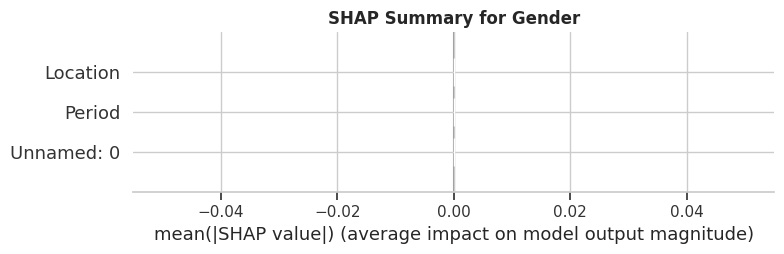


SHAP Analysis for Age-group


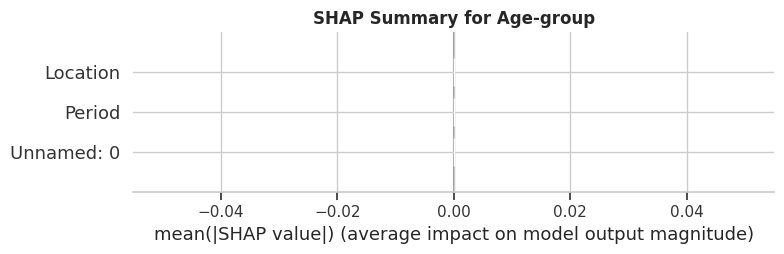


SHAP analysis script finished.


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define your label names explicitly
label_names = ["Gender", "Age-group", "Occupation", "Income Level"]

# First, make sure X_test_sel is a numpy array
if hasattr(X_test_sel, 'values'):
    X_test_np = X_test_sel.values
else:
    X_test_np = np.asarray(X_test_sel) # Ensure it's numpy array

# Get feature names - Ensure X_train exists and has columns
try:
    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns.tolist()
    elif isinstance(X_test_sel, pd.DataFrame) and hasattr(X_test_sel, 'columns'):
         print("Warning: Using feature names from X_test_sel as X_train columns not found.")
         feature_names = X_test_sel.columns.tolist()
    else:
        print("Warning: Could not get feature names from X_train or X_test_sel. Generating generic names.")
        feature_names = [f"Feature {i}" for i in range(X_test_np.shape[1])]
except NameError:
     print("Error: X_train not defined. Cannot get feature names.")
     feature_names = [f"Feature {i}" for i in range(X_test_np.shape[1])]


# Select a smaller subset for analysis
sample_size = min(200, len(X_test_np))
if len(X_test_np) > 0 :
    sample_indices = np.random.choice(len(X_test_np), sample_size, replace=False)
    X_sample = X_test_np[sample_indices]
else:
    print("Error: X_test_np is empty.")
    # Handle empty data case appropriately, maybe exit or skip SHAP
    X_sample = np.array([[]]) # Placeholder to avoid later errors, but analysis will be meaningless


# Create background dataset
background_size = min(100, len(X_test_np))
if len(X_test_np) > 0:
    background_indices = np.random.choice(len(X_test_np), background_size, replace=False)
    background = X_test_np[background_indices]
else:
    print("Error: X_test_np is empty. Cannot create background.")
    background = np.array([[]]) # Placeholder

# Check if background or sample is empty before proceeding
if background.shape[0] == 0 or X_sample.shape[0] == 0 or X_sample.shape[1] == 0:
    print("Error: Cannot proceed with SHAP analysis due to empty background or sample data.")
else:
    # Create explainer
    print("Creating SHAP explainer...")
    # Ensure the model predict function returns appropriate shape for KernelExplainer
    # It expects (n_samples,) for single output or (n_samples, n_outputs) for multi-output
    # KernelExplainer usually returns a list for multi-output.
    try:
        explainer = shap.KernelExplainer(model.predict, background)

        # Calculate SHAP values
        print("Calculating SHAP values (this may take a while)...")
        shap_values = explainer.shap_values(X_sample, nsamples='auto') # Use auto nsamples

        # --- Visualization code ---
        if isinstance(shap_values, list):
            print("Detected list of SHAP values (standard multi-output).")
            if len(shap_values) != len(label_names):
                 print(f"Warning: Number of SHAP value sets ({len(shap_values)}) does not match number of label names ({len(label_names)}). Using generic output names where needed.")

            for i, output_shap_values in enumerate(shap_values):
                # output_shap_values should have shape (n_samples, n_features)
                current_label = label_names[i] if i < len(label_names) else f"Output {i}"
                print(f"\n\033[1mSHAP Analysis for {current_label}\033[0m")

                if output_shap_values.shape[0] != X_sample.shape[0] or output_shap_values.shape[1] != X_sample.shape[1]:
                    print(f"Error: Shape mismatch for output {i}. SHAP values shape: {output_shap_values.shape}, X_sample shape: {X_sample.shape}")
                    continue # Skip this output

                try:
                    plt.figure(figsize=(12, 8)) # New figure for each plot
                    shap.summary_plot(
                        output_shap_values,
                        X_sample,
                        feature_names=feature_names,
                        show=False # Prevent double display
                    )
                    plt.title(f"SHAP Summary for {current_label}", weight='bold')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Visualization failed: {e}")
                    # Fallback plot
                    try:
                        mean_abs_shap = np.abs(output_shap_values).mean(axis=0)
                        if len(feature_names) == len(mean_abs_shap):
                            feature_importance = pd.DataFrame({
                                'Feature': feature_names,
                                'Importance': mean_abs_shap
                            }).sort_values('Importance', ascending=False).head(10)

                            plt.figure(figsize=(10, 6)) # New figure for fallback
                            feature_importance.plot.barh(
                                x='Feature',
                                y='Importance',
                                title=f'Top Features for {current_label} (Fallback)',
                                legend=False
                            )
                            plt.gca().invert_yaxis()
                            plt.tight_layout()
                            plt.show()
                        else:
                             print(f"Fallback plot failed: Mismatch between feature names ({len(feature_names)}) and SHAP values ({len(mean_abs_shap)})")
                    except Exception as fallback_e:
                        print(f"Fallback plot also failed: {fallback_e}")


        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            # This case is less common for KernelExplainer but your code detected it
            print("Detected 3D SHAP values array.")
            n_samples, dim1, dim2 = shap_values.shape
            n_features = X_sample.shape[1]

            # Try to determine which dimension corresponds to outputs
            # Assuming dim1 is n_outputs based on your original slicing [:, i, :] working for the 2D check
            n_outputs_detected = dim1
            feature_dim = dim2
            if feature_dim != n_features:
                 print(f"Warning: Feature dimension in 3D SHAP values ({feature_dim}) doesn't match X_sample features ({n_features}). Assuming shape is (samples, features, outputs).")
                 n_outputs_detected = dim2
                 feature_dim = dim1
                 slicing_mode = '[:, :, i]' # Use this slicing if shape is (samples, features, outputs)
            else:
                 slicing_mode = '[:, i, :]' # Use this slicing if shape is (samples, outputs, features)

            print(f"Interpreted shape: (samples={n_samples}, dim1={dim1}, dim2={dim2}). Using slicing: {slicing_mode}")

            if n_outputs_detected != len(label_names):
                 print(f"Warning: Number of outputs in 3D array ({n_outputs_detected}) does not match label names ({len(label_names)}).")

            for i in range(n_outputs_detected):
                current_label = label_names[i] if i < len(label_names) else f"Output {i}"
                print(f"\n\033[1mSHAP Analysis for {current_label}\033[0m")

                # Extract the SHAP values for this output
                if slicing_mode == '[:, :, i]':
                    single_output_shap = shap_values[:, :, i]
                else: # slicing_mode == '[:, i, :]'
                    single_output_shap = shap_values[:, i, :]

                # Check shapes before plotting
                if single_output_shap.shape[0] != X_sample.shape[0] or single_output_shap.shape[1] != X_sample.shape[1]:
                    print(f"Error: Shape mismatch for output {i}. SHAP slice shape: {single_output_shap.shape}, X_sample shape: {X_sample.shape}")
                    continue # Skip this output


                try:
                    plt.figure(figsize=(12, 8)) # New figure
                    shap.summary_plot(
                        single_output_shap, # Should be (n_samples, n_features)
                        X_sample,
                        feature_names=feature_names,
                        show=False,
                        plot_type="bar" # Keeping your original plot type here
                    )
                    plt.title(f"SHAP Summary for {current_label}", weight='bold')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Visualization failed: {e}")
                     # Fallback plot
                    try:
                        # --- CORRECTED FALLBACK ---
                        mean_abs_shap = np.abs(single_output_shap).mean(axis=0) # Average over samples (axis 0)
                        # --- END CORRECTION ---
                        if len(feature_names) == len(mean_abs_shap):
                            feature_importance = pd.DataFrame({
                                'Feature': feature_names,
                                'Importance': mean_abs_shap
                            }).sort_values('Importance', ascending=False).head(10)

                            plt.figure(figsize=(10, 6)) # New figure
                            feature_importance.plot.barh(
                                x='Feature',
                                y='Importance',
                                title=f'Top Features for {current_label} (Fallback)',
                                legend=False
                            )
                            plt.gca().invert_yaxis()
                            plt.tight_layout()
                            plt.show()
                        else:
                             print(f"Fallback plot failed: Mismatch between feature names ({len(feature_names)}) and SHAP values ({len(mean_abs_shap)})")
                    except Exception as fallback_e:
                         print(f"Fallback plot also failed: {fallback_e}")

        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
            # Single output case
            print("\n\033[1mSHAP Analysis (Single Output Detected)\033[0m")
            if shap_values.shape[0] != X_sample.shape[0] or shap_values.shape[1] != X_sample.shape[1]:
                 print(f"Error: Shape mismatch. SHAP values shape: {shap_values.shape}, X_sample shape: {X_sample.shape}")
            else:
                try:
                    plt.figure(figsize=(12, 8)) # New figure
                    shap.summary_plot(
                        shap_values,
                        X_sample,
                        feature_names=feature_names,
                        show=False
                    )
                    plt.title("SHAP Summary", weight='bold')
                    plt.tight_layout()
                    plt.show()
                except Exception as e:
                    print(f"Visualization failed: {e}")
                    # Fallback plot
                    try:
                        mean_abs_shap = np.abs(shap_values).mean(axis=0)
                        if len(feature_names) == len(mean_abs_shap):
                            feature_importance = pd.DataFrame({
                                'Feature': feature_names,
                                'Importance': mean_abs_shap
                            }).sort_values('Importance', ascending=False).head(10)

                            plt.figure(figsize=(10, 6)) # New figure
                            feature_importance.plot.barh(
                                x='Feature',
                                y='Importance',
                                title='Top Features (Fallback)',
                                legend=False
                            )
                            plt.gca().invert_yaxis()
                            plt.tight_layout()
                            plt.show()
                        else:
                             print(f"Fallback plot failed: Mismatch between feature names ({len(feature_names)}) and SHAP values ({len(mean_abs_shap)})")
                    except Exception as fallback_e:
                        print(f"Fallback plot also failed: {fallback_e}")

        else:
            print(f"Error: Unrecognized SHAP values format.")
            print(f"Type: {type(shap_values)}")
            if hasattr(shap_values, 'shape'):
                print(f"Shape: {shap_values.shape}")

    except Exception as explainer_e:
        print(f"Error during SHAP explanation: {explainer_e}")


print("\nSHAP analysis script finished.")

X_sample shape: (200, 3)
Background shape: (100, 3)
Number of features: 18

--- Checking Model Prediction Shape ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
Shape of model.predict(background[:5]): (5, 2)
Type of model.predict output: <class 'numpy.ndarray'>
Detected 2 outputs from model prediction shape.
-------------------------------------


--- Processing Output: Gender (Index 0) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
Wrapper function output shape for index 0: (2,)
Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Calculating SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━

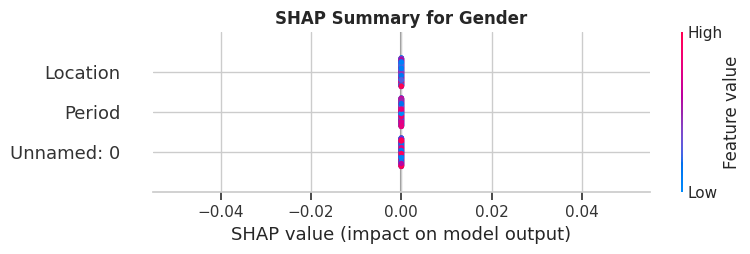


--- Processing Output: Age-group (Index 1) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Wrapper function output shape for index 1: (2,)
Creating SHAP explainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Calculating SHAP values (this may take a while)...


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
19/19 ━━━━━━━━━━━━━━━━━━━

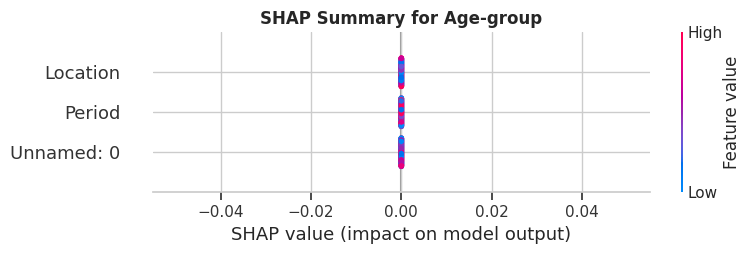


--- Processing Output: Occupation (Index 2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Error testing wrapper function for output 2: Output index 2 out of bounds for prediction shape (2, 2)

--- Processing Output: Income Level (Index 3) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Error testing wrapper function for output 3: Output index 3 out of bounds for prediction shape (2, 2)

SHAP analysis script finished.


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define your label names explicitly
label_names = ["Gender", "Age-group", "Occupation", "Income Level"]

# Assume X_test_sel, X_train, model are defined

# --- Data Preparation ---
if hasattr(X_test_sel, 'values'):
    X_test_np = X_test_sel.values
else:
    X_test_np = np.asarray(X_test_sel)

try:
    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns.tolist()
    elif isinstance(X_test_sel, pd.DataFrame) and hasattr(X_test_sel, 'columns'):
         print("Warning: Using feature names from X_test_sel as X_train columns not found.")
         feature_names = X_test_sel.columns.tolist()
    else:
        print("Warning: Could not get feature names. Generating generic names.")
        feature_names = [f"Feature {i}" for i in range(X_test_np.shape[1])]
except NameError:
     print("Error: X_train not defined. Cannot get feature names.")
     feature_names = [f"Feature {i}" for i in range(X_test_np.shape[1])]

# Select a smaller subset for analysis
sample_size = min(200, len(X_test_np))
if len(X_test_np) > 0 :
    sample_indices = np.random.choice(len(X_test_np), sample_size, replace=False)
    X_sample = X_test_np[sample_indices]
else:
    print("Error: X_test_np is empty.")
    X_sample = np.array([[]])

# Create background dataset
background_size = min(100, len(X_test_np))
if len(X_test_np) > 0:
    background_indices = np.random.choice(len(X_test_np), background_size, replace=False)
    background = X_test_np[background_indices]
else:
    print("Error: X_test_np is empty. Cannot create background.")
    background = np.array([[]])

print(f"X_sample shape: {X_sample.shape}")
print(f"Background shape: {background.shape}")
print(f"Number of features: {len(feature_names)}")

# --- Check Model Output Shape ---
if background.shape[0] > 0 and background.shape[1] > 0:
    try:
        print("\n--- Checking Model Prediction Shape ---")
        # Use background data for checking prediction shape
        test_prediction = model.predict(background[:5])
        print(f"Shape of model.predict(background[:5]): {test_prediction.shape}")
        print(f"Type of model.predict output: {type(test_prediction)}")
        # Determine expected number of outputs from model prediction if possible
        if isinstance(test_prediction, np.ndarray) and test_prediction.ndim >= 2:
            n_model_outputs = test_prediction.shape[1]
            print(f"Detected {n_model_outputs} outputs from model prediction shape.")
            if n_model_outputs != len(label_names):
                 print(f"Warning: Model output dimension ({n_model_outputs}) doesn't match label_names length ({len(label_names)}).")
        print("-------------------------------------\n")

    except Exception as e:
        print(f"Error checking model.predict shape: {e}")
        print("Proceeding, but SHAP results might be unpredictable.")
        print("-------------------------------------\n")
else:
    print("Skipping model prediction check due to empty background data.")


# --- Define Wrapper Function ---
def create_predict_wrapper(model, output_index):
    """Creates a function that predicts only a single output index."""
    def predict_single_output(data):
        full_predictions = model.predict(data)
        # Handle different prediction shapes
        if isinstance(full_predictions, np.ndarray):
            if full_predictions.ndim == 1:
                # Model might only return one output anyway
                if output_index == 0:
                    return full_predictions
                else:
                    raise ValueError(f"Requested output index {output_index} but model prediction is 1D.")
            elif full_predictions.ndim == 2:
                # Standard case: (n_samples, n_outputs)
                if output_index < full_predictions.shape[1]:
                    return full_predictions[:, output_index] # Shape (n_samples,)
                else:
                     raise ValueError(f"Output index {output_index} out of bounds for prediction shape {full_predictions.shape}")
            elif full_predictions.ndim == 3:
                 # e.g., (n_samples, n_outputs, n_classes)
                 print(f"Warning: Model prediction is 3D ({full_predictions.shape}). Assuming dim 1 is outputs and selecting index {output_index}.")
                 print("         Returning prediction for the last class (index -1) in the third dimension.")
                 if output_index < full_predictions.shape[1]:
                     # Return probability/value for the last class of the specified output
                     return full_predictions[:, output_index, -1] # Shape (n_samples,)
                 else:
                     raise ValueError(f"Output index {output_index} out of bounds for prediction shape {full_predictions.shape}")
            else:
                 raise ValueError(f"Unsupported model prediction dimension: {full_predictions.ndim}")
        elif isinstance(full_predictions, list):
             # Handle list output from model? Less common but possible.
             print("Warning: Model prediction is a list. Assuming list index corresponds to output.")
             if output_index < len(full_predictions):
                 # Assuming each element relates to a sample or needs further processing
                 # This might need adjustment based on the actual list structure
                 # For now, assume it's a list of outputs, each being (n_samples,) or similar
                 output_pred = full_predictions[output_index]
                 if isinstance(output_pred, np.ndarray) and output_pred.ndim == 1 and output_pred.shape[0] == data.shape[0]:
                     return output_pred
                 else:
                      raise ValueError(f"List element at index {output_index} has unexpected format: type={type(output_pred)}, shape={getattr(output_pred, 'shape', 'N/A')}")
             else:
                 raise ValueError(f"Output index {output_index} out of bounds for prediction list length {len(full_predictions)}")
        else:
             raise TypeError(f"Unsupported model prediction type: {type(full_predictions)}")

    return predict_single_output

# --- SHAP Calculation and Visualization per Output ---
if background.shape[0] > 0 and background.shape[1] > 0 and X_sample.shape[0] > 0 and X_sample.shape[1] > 0:
    n_outputs_to_explain = len(label_names)
    shap_values_list = [] # To store results if needed later

    for i in range(n_outputs_to_explain):
        current_label = label_names[i]
        print(f"\n--- Processing Output: {current_label} (Index {i}) ---")

        try:
            # 1. Create the specific prediction function
            predict_fn_i = create_predict_wrapper(model, i)

            # Optional: Test the wrapper output shape
            try:
                wrapper_test_pred = predict_fn_i(background[:2])
                print(f"Wrapper function output shape for index {i}: {wrapper_test_pred.shape}")
                if not (isinstance(wrapper_test_pred, np.ndarray) and wrapper_test_pred.ndim == 1):
                     print(f"Warning: Wrapper function for output {i} did not return a 1D numpy array.")
            except Exception as wrapper_e:
                 print(f"Error testing wrapper function for output {i}: {wrapper_e}")
                 continue # Skip SHAP for this output if wrapper fails

            # 2. Create the KernelExplainer for this single output
            print("Creating SHAP explainer...")
            explainer_i = shap.KernelExplainer(predict_fn_i, background)

            # 3. Calculate SHAP values (should be 2D: n_samples, n_features)
            print("Calculating SHAP values (this may take a while)...")
            shap_values_i = explainer_i.shap_values(X_sample, nsamples='auto')
            print(f"Calculated SHAP values shape: {shap_values_i.shape}")

            # 4. Validate shape
            expected_shape = (X_sample.shape[0], X_sample.shape[1])
            if not isinstance(shap_values_i, np.ndarray) or shap_values_i.shape != expected_shape:
                print(f"Error: SHAP values shape for {current_label} is {shap_values_i.shape}. Expected {expected_shape}.")
                print("Skipping visualization for this output.")
                continue # Skip to next output

            shap_values_list.append(shap_values_i) # Store the valid result

            # 5. Visualize
            print(f"\n\033[1mSHAP Summary Plot for {current_label}\033[0m")
            try:
                plt.figure(figsize=(12, 8)) # Create a new figure
                shap.summary_plot(
                    shap_values_i,
                    X_sample,
                    feature_names=feature_names,
                    show=False # Prevent double display
                )
                plt.title(f"SHAP Summary for {current_label}", weight='bold')
                plt.tight_layout()
                plt.show()
            except Exception as plot_e:
                print(f"SHAP summary_plot failed for {current_label}: {plot_e}")
                # Attempt fallback plot
                print(f"\n\033[1mFallback Importance Plot for {current_label}\033[0m")
                try:
                    mean_abs_shap = np.abs(shap_values_i).mean(axis=0)
                    # Double check lengths before creating DataFrame
                    if len(feature_names) == len(mean_abs_shap):
                        feature_importance = pd.DataFrame({
                            'Feature': feature_names,
                            'Importance': mean_abs_shap
                        }).sort_values('Importance', ascending=False).head(20) # Show top 20

                        plt.figure(figsize=(10, 8)) # New figure for fallback plot
                        feature_importance.plot.barh(
                            x='Feature',
                            y='Importance',
                            title=f'Top Features for {current_label} (Fallback)',
                            legend=False
                        )
                        plt.gca().invert_yaxis()
                        plt.tight_layout()
                        plt.show()
                    else:
                        # This shouldn't happen if the main shape check passed, but check anyway
                        print(f"Fallback plot failed: Mismatch between feature names ({len(feature_names)}) and mean SHAP values ({len(mean_abs_shap)})")
                except Exception as fallback_e:
                    print(f"Fallback plot generation failed: {fallback_e}")

        except Exception as outer_e:
            print(f"Error during SHAP processing for output {current_label}: {outer_e}")
            import traceback
            traceback.print_exc() # Print full traceback for debugging

else:
    print("\nSkipping SHAP analysis because background or sample data is empty or invalid.")

print("\nSHAP analysis script finished.")

NB: SHAP considers